1.a

LOADING PAVIA UNIVERSITY DATASET
Hyperspectral Image Shape: (610, 340, 103)
Ground Truth Shape: (610, 340)
Data type: uint16
Ground Truth data type: uint8

BASIC DATASET STATISTICS
Image Dimensions: 610 x 340 pixels
Number of Spectral Bands: 103
Total Pixels: 207,400
Spectral Range: 430-960 nm (5 nm spacing)

Data Range:
  Min value: 0.0000
  Max value: 8000.0000
  Mean value: 1389.1253
  Std deviation: 897.6575

CLASS DISTRIBUTION ANALYSIS

Class Distribution:
----------------------------------------------------------------------
Class 0 (Unlabeled): 164,624 (79.38%)
Class 1 (Asphalt): 6,631 (3.20%)
Class 2 (Meadows): 18,649 (8.99%)
Class 3 (Gravel): 2,099 (1.01%)
Class 4 (Trees): 3,064 (1.48%)
Class 5 (Painted metal sheets): 1,345 (0.65%)
Class 6 (Bare Soil): 5,029 (2.42%)
Class 7 (Bitumen): 1,330 (0.64%)
Class 8 (Self-Blocking Bricks): 3,682 (1.78%)
Class 9 (Shadows): 947 (0.46%)

Total Labeled Samples: 42,776
Total Unlabeled Samples: 164,624
Percentage Labeled: 20.62%

Class Imbala

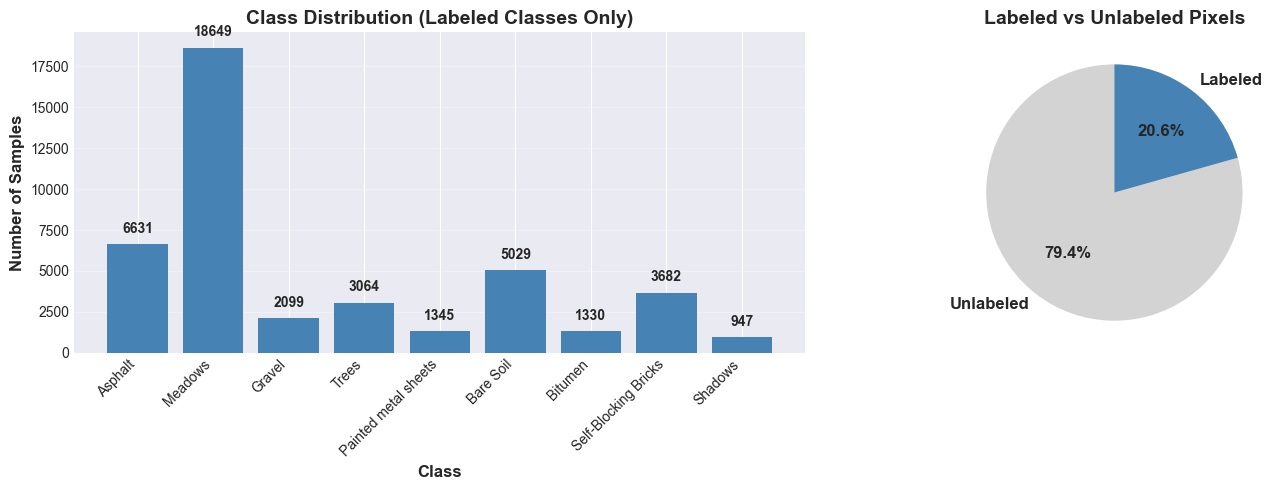


VISUALIZING GROUND TRUTH MAP


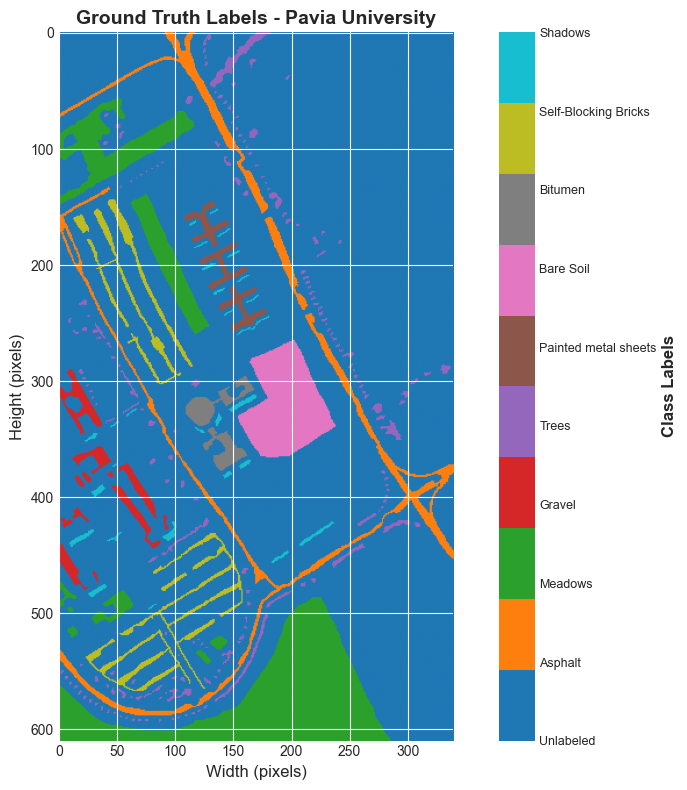


SPECTRAL BAND ANALYSIS
Band Statistics Summary:
  Average band mean: 1389.1253
  Average band std: 716.4461
  Band with highest mean: 90 (wavelength: 897.6 nm)
  Band with lowest mean: 2 (wavelength: 440.4 nm)


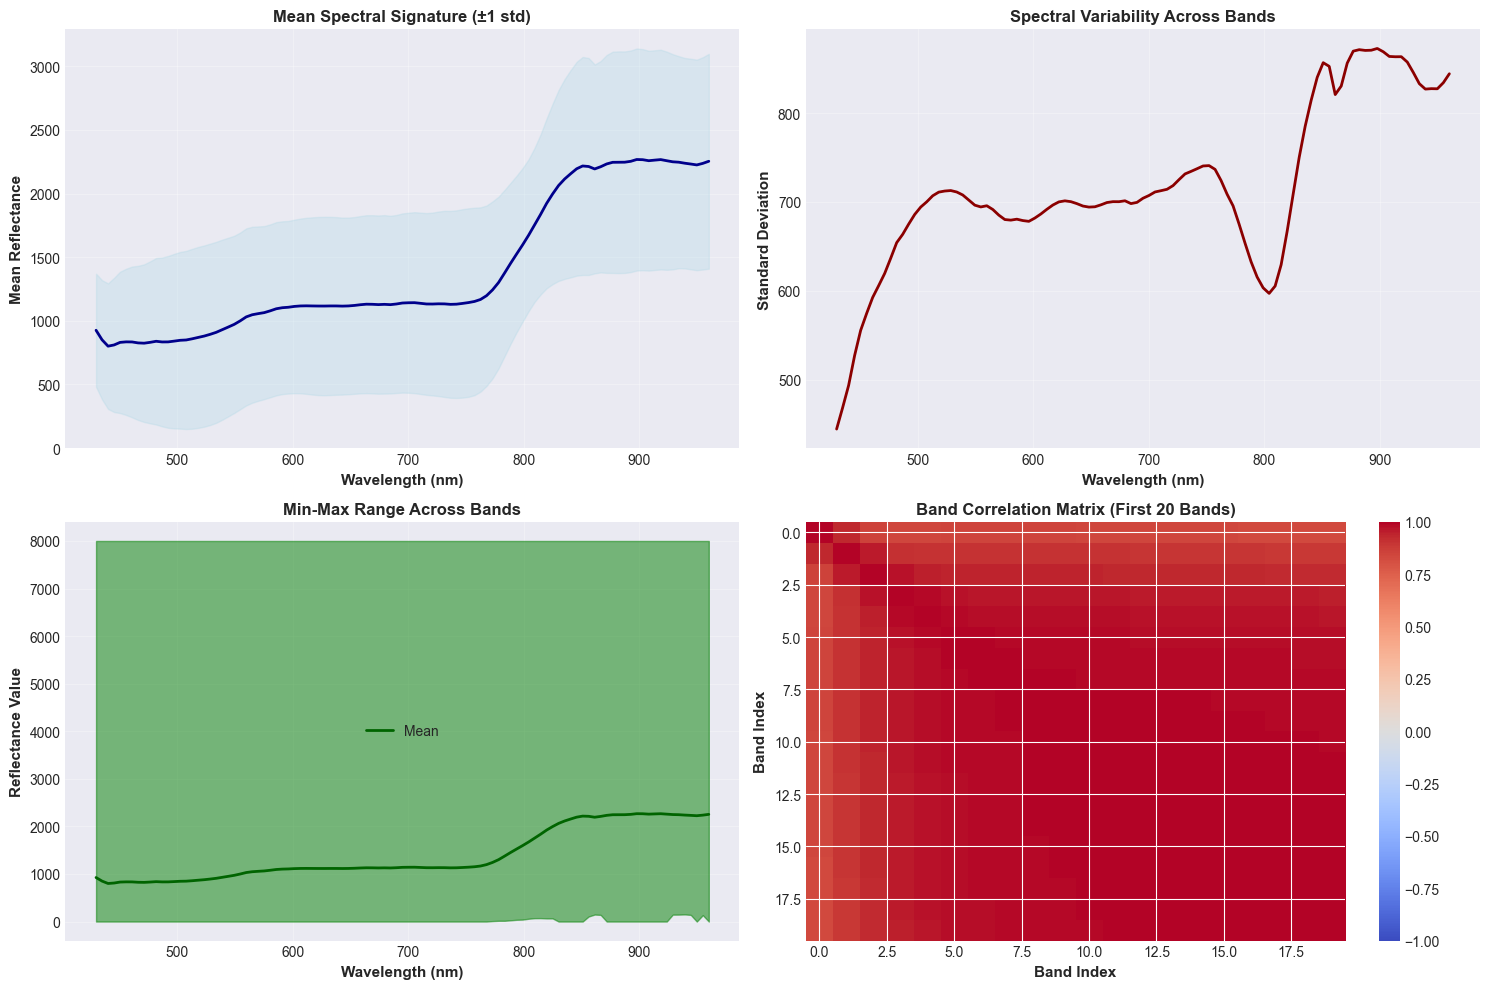


CLASS-SPECIFIC SPECTRAL SIGNATURES


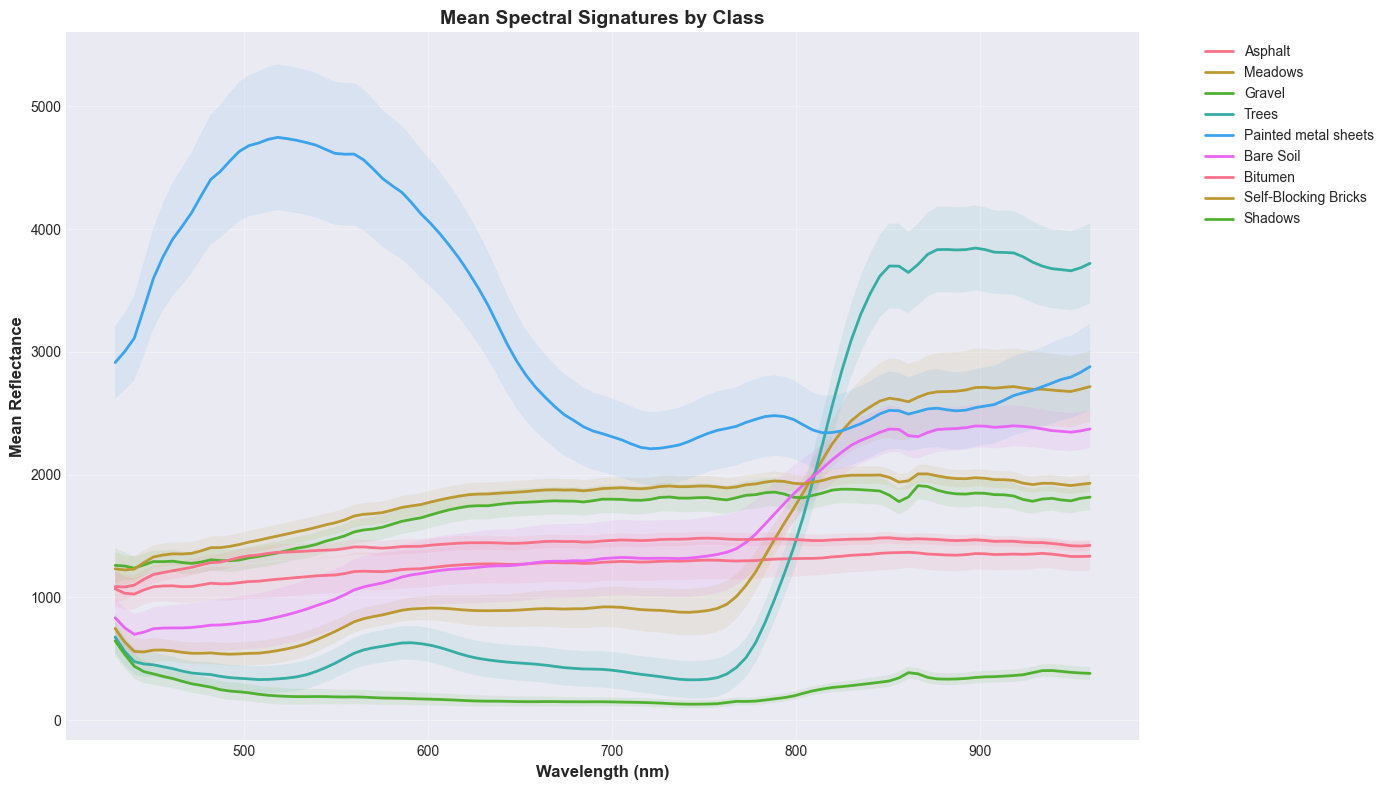


RGB COMPOSITE VISUALIZATION


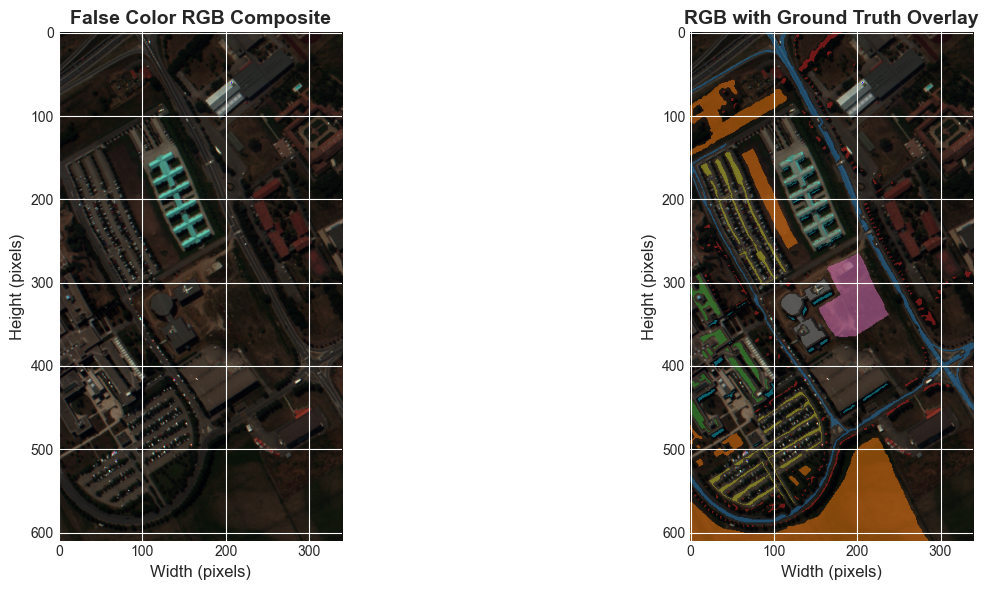


DIMENSIONALITY REDUCTION ANALYSIS (PCA)
Number of components for 95% variance: 3
Number of components for 99% variance: 4
Variance explained by first 3 components: 98.80%
Variance explained by first 10 components: 99.84%


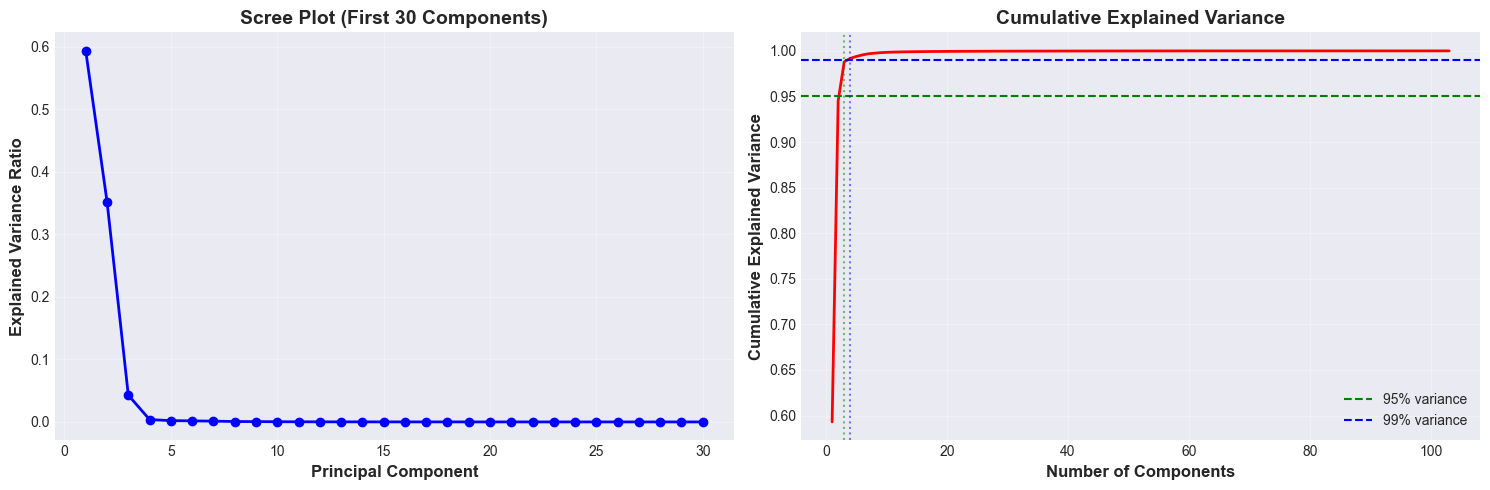


DATA QUALITY CHECKS
NaN values: 0
Inf values: 0
Negative values: 0 (0.0000%)

Data range check:
  Expected range: [0, ~1] or [0, ~10000] depending on scaling
  Actual range: [0.0000, 8000.0000]

Spatial coherence:
  Isolated labeled pixels: 0

EDA COMPLETE

Key Findings Summary:
1. Dataset has 103 spectral bands covering 430-960 nm
2. 9 classes with imbalance ratio of 19.69:1
3. Only 20.62% of pixels are labeled
4. 3 components capture 95% of spectral variance
5. Data quality: GOOD


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import loadmat
from sklearn.decomposition import PCA
import pandas as pd


plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


# 1. LOAD THE DATASET

print("="*70)
print("LOADING PAVIA UNIVERSITY DATASET")
print("="*70)

# Load the hyperspectral image and ground truth
data = loadmat('PaviaU.mat')
gt = loadmat('PaviaU_gt.mat')

# Extract the actual arrays
X = data['paviaU']  # Hyperspectral image
y = gt['paviaU_gt']  # Ground truth labels

print(f"Hyperspectral Image Shape: {X.shape}")
print(f"Ground Truth Shape: {y.shape}")
print(f"Data type: {X.dtype}")
print(f"Ground Truth data type: {y.dtype}")


# 2. BASIC DATASET STATISTICS

print("\n" + "="*70)
print("BASIC DATASET STATISTICS")
print("="*70)

height, width, bands = X.shape
total_pixels = height * width
print(f"Image Dimensions: {height} x {width} pixels")
print(f"Number of Spectral Bands: {bands}")
print(f"Total Pixels: {total_pixels:,}")
print(f"Spectral Range: 430-960 nm (5 nm spacing)")
print(f"\nData Range:")
print(f"  Min value: {X.min():.4f}")
print(f"  Max value: {X.max():.4f}")
print(f"  Mean value: {X.mean():.4f}")
print(f"  Std deviation: {X.std():.4f}")


# 3. CLASS DISTRIBUTION ANALYSIS

print("\n" + "="*70)
print("CLASS DISTRIBUTION ANALYSIS")
print("="*70)

# Class names for Pavia University
class_names = {
    0: 'Unlabeled',
    1: 'Asphalt',
    2: 'Meadows',
    3: 'Gravel',
    4: 'Trees',
    5: 'Painted metal sheets',
    6: 'Bare Soil',
    7: 'Bitumen',
    8: 'Self-Blocking Bricks',
    9: 'Shadows'
}

# Count samples per class
unique_classes, counts = np.unique(y, return_counts=True)
class_distribution = dict(zip(unique_classes, counts))

print("\nClass Distribution:")
print("-" * 70)
labeled_samples = 0
for class_id in sorted(class_distribution.keys()):
    count = class_distribution[class_id]
    percentage = (count / total_pixels) * 100
    if class_id == 0:
        print(f"Class {class_id} ({class_names[class_id]}): {count:,} ({percentage:.2f}%)")
    else:
        labeled_samples += count
        print(f"Class {class_id} ({class_names[class_id]}): {count:,} ({percentage:.2f}%)")

print(f"\nTotal Labeled Samples: {labeled_samples:,}")
print(f"Total Unlabeled Samples: {class_distribution[0]:,}")
print(f"Percentage Labeled: {(labeled_samples/total_pixels)*100:.2f}%")

# Calculate class imbalance ratio
labeled_counts = [counts[i] for i in range(1, len(counts))]
imbalance_ratio = max(labeled_counts) / min(labeled_counts)
print(f"\nClass Imbalance Ratio (max/min): {imbalance_ratio:.2f}:1")


# 4. VISUALIZATION: CLASS DISTRIBUTION

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar plot of class distribution (excluding unlabeled)
labeled_classes = [c for c in unique_classes if c != 0]
labeled_class_counts = [class_distribution[c] for c in labeled_classes]
labeled_class_names = [class_names[c] for c in labeled_classes]

axes[0].bar(range(len(labeled_classes)), labeled_class_counts, color='steelblue')
axes[0].set_xlabel('Class', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Samples', fontsize=12, fontweight='bold')
axes[0].set_title('Class Distribution (Labeled Classes Only)', fontsize=14, fontweight='bold')
axes[0].set_xticks(range(len(labeled_classes)))
axes[0].set_xticklabels(labeled_class_names, rotation=45, ha='right')
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(labeled_class_counts):
    axes[0].text(i, v + 500, str(v), ha='center', va='bottom', fontweight='bold')

# Pie chart showing labeled vs unlabeled
pie_data = [class_distribution[0], labeled_samples]
pie_labels = ['Unlabeled', 'Labeled']
colors = ['lightgray', 'steelblue']
axes[1].pie(pie_data, labels=pie_labels, autopct='%1.1f%%', colors=colors,
            startangle=90, textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title('Labeled vs Unlabeled Pixels', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


# 5. GROUND TRUTH VISUALIZATION

print("\n" + "="*70)
print("VISUALIZING GROUND TRUTH MAP")
print("="*70)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(y, cmap='tab10')
ax.set_title('Ground Truth Labels - Pavia University', fontsize=14, fontweight='bold')
ax.set_xlabel('Width (pixels)', fontsize=12)
ax.set_ylabel('Height (pixels)', fontsize=12)

# Create custom colorbar
cbar = plt.colorbar(im, ax=ax, ticks=range(10))
cbar.set_label('Class Labels', fontsize=12, fontweight='bold')
cbar.ax.set_yticklabels([class_names[i] for i in range(10)], fontsize=9)

plt.tight_layout()
plt.show()


# 6. SPECTRAL BAND ANALYSIS

print("\n" + "="*70)
print("SPECTRAL BAND ANALYSIS")
print("="*70)

# Calculate statistics for each band
band_means = np.mean(X, axis=(0, 1))
band_stds = np.std(X, axis=(0, 1))
band_mins = np.min(X, axis=(0, 1))
band_maxs = np.max(X, axis=(0, 1))

# Calculate wavelengths (430-960 nm in 5nm spacing)
wavelengths = np.linspace(430, 960, bands)

print(f"Band Statistics Summary:")
print(f"  Average band mean: {band_means.mean():.4f}")
print(f"  Average band std: {band_stds.mean():.4f}")
print(f"  Band with highest mean: {np.argmax(band_means)} (wavelength: {wavelengths[np.argmax(band_means)]:.1f} nm)")
print(f"  Band with lowest mean: {np.argmin(band_means)} (wavelength: {wavelengths[np.argmin(band_means)]:.1f} nm)")

# Visualize spectral statistics
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Mean reflectance per band
axes[0, 0].plot(wavelengths, band_means, linewidth=2, color='darkblue')
axes[0, 0].fill_between(wavelengths, band_means - band_stds, band_means + band_stds, 
                         alpha=0.3, color='lightblue')
axes[0, 0].set_xlabel('Wavelength (nm)', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Mean Reflectance', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Mean Spectral Signature (±1 std)', fontsize=12, fontweight='bold')
axes[0, 0].grid(alpha=0.3)

# Standard deviation per band
axes[0, 1].plot(wavelengths, band_stds, linewidth=2, color='darkred')
axes[0, 1].set_xlabel('Wavelength (nm)', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Standard Deviation', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Spectral Variability Across Bands', fontsize=12, fontweight='bold')
axes[0, 1].grid(alpha=0.3)

# Min-Max range per band
axes[1, 0].fill_between(wavelengths, band_mins, band_maxs, alpha=0.5, color='green')
axes[1, 0].plot(wavelengths, band_means, linewidth=2, color='darkgreen', label='Mean')
axes[1, 0].set_xlabel('Wavelength (nm)', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Reflectance Value', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Min-Max Range Across Bands', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Heatmap of correlation between first 20 bands
sample_bands = 20
band_subset = X[:, :, :sample_bands].reshape(-1, sample_bands)
# Sample for computational efficiency
sample_indices = np.random.choice(band_subset.shape[0], min(5000, band_subset.shape[0]), replace=False)
correlation_matrix = np.corrcoef(band_subset[sample_indices].T)

im = axes[1, 1].imshow(correlation_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
axes[1, 1].set_xlabel('Band Index', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Band Index', fontsize=11, fontweight='bold')
axes[1, 1].set_title(f'Band Correlation Matrix (First {sample_bands} Bands)', fontsize=12, fontweight='bold')
plt.colorbar(im, ax=axes[1, 1])

plt.tight_layout()
plt.show()


# 7. CLASS-SPECIFIC SPECTRAL SIGNATURES

print("\n" + "="*70)
print("CLASS-SPECIFIC SPECTRAL SIGNATURES")
print("="*70)

# Extract spectral signatures for each class
fig, ax = plt.subplots(figsize=(14, 8))

for class_id in range(1, 10):
    # Get all pixels belonging to this class
    mask = (y == class_id)
    class_pixels = X[mask]
    
    if len(class_pixels) > 0:
        # Calculate mean spectral signature
        mean_signature = np.mean(class_pixels, axis=0)
        std_signature = np.std(class_pixels, axis=0)
        
        # Plot with confidence interval
        ax.plot(wavelengths, mean_signature, linewidth=2, label=class_names[class_id])
        ax.fill_between(wavelengths, mean_signature - std_signature/2, 
                        mean_signature + std_signature/2, alpha=0.1)

ax.set_xlabel('Wavelength (nm)', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Reflectance', fontsize=12, fontweight='bold')
ax.set_title('Mean Spectral Signatures by Class', fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# 8. RGB VISUALIZATION

print("\n" + "="*70)
print("RGB COMPOSITE VISUALIZATION")
print("="*70)

# Create false-color RGB composite using bands (approximate RGB wavelengths)
# Red: ~640nm (band 54), Green: ~550nm (band 24), Blue: ~470nm (band 8)
red_band = 54
green_band = 24
blue_band = 8

rgb_image = np.stack([
    X[:, :, red_band],
    X[:, :, green_band],
    X[:, :, blue_band]
], axis=2)

# Normalize to 0-1 range for display
rgb_normalized = (rgb_image - rgb_image.min()) / (rgb_image.max() - rgb_image.min())

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].imshow(rgb_normalized)
axes[0].set_title('False Color RGB Composite', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Width (pixels)', fontsize=12)
axes[0].set_ylabel('Height (pixels)', fontsize=12)
axes[0].axis('on')

# Ground truth overlay
axes[1].imshow(rgb_normalized)
masked_gt = np.ma.masked_where(y == 0, y)
axes[1].imshow(masked_gt, cmap='tab10', alpha=0.5)
axes[1].set_title('RGB with Ground Truth Overlay', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Width (pixels)', fontsize=12)
axes[1].set_ylabel('Height (pixels)', fontsize=12)

plt.tight_layout()
plt.show()


# 9. DIMENSIONALITY ANALYSIS WITH PCA

print("\n" + "="*70)
print("DIMENSIONALITY REDUCTION ANALYSIS (PCA)")
print("="*70)

# Reshape data for PCA
X_reshaped = X.reshape(-1, bands)

# Sample for computational efficiency
sample_size = min(10000, X_reshaped.shape[0])
sample_indices = np.random.choice(X_reshaped.shape[0], sample_size, replace=False)
X_sample = X_reshaped[sample_indices]

# Apply PCA
pca = PCA()
pca.fit(X_sample)

# Calculate cumulative variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Find number of components for 95% and 99% variance
n_95 = np.argmax(cumulative_variance >= 0.95) + 1
n_99 = np.argmax(cumulative_variance >= 0.99) + 1

print(f"Number of components for 95% variance: {n_95}")
print(f"Number of components for 99% variance: {n_99}")
print(f"Variance explained by first 3 components: {cumulative_variance[2]:.2%}")
print(f"Variance explained by first 10 components: {cumulative_variance[9]:.2%}")

# Visualize PCA results
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Scree plot
axes[0].plot(range(1, 31), pca.explained_variance_ratio_[:30], 'bo-', linewidth=2)
axes[0].set_xlabel('Principal Component', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Explained Variance Ratio', fontsize=12, fontweight='bold')
axes[0].set_title('Scree Plot (First 30 Components)', fontsize=14, fontweight='bold')
axes[0].grid(alpha=0.3)

# Cumulative variance
axes[1].plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'r-', linewidth=2)
axes[1].axhline(y=0.95, color='g', linestyle='--', label='95% variance')
axes[1].axhline(y=0.99, color='b', linestyle='--', label='99% variance')
axes[1].axvline(x=n_95, color='g', linestyle=':', alpha=0.5)
axes[1].axvline(x=n_99, color='b', linestyle=':', alpha=0.5)
axes[1].set_xlabel('Number of Components', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Cumulative Explained Variance', fontsize=12, fontweight='bold')
axes[1].set_title('Cumulative Explained Variance', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


# 10. DATA QUALITY CHECKS

print("\n" + "="*70)
print("DATA QUALITY CHECKS")
print("="*70)

# Check for missing values
nan_count = np.isnan(X).sum()
inf_count = np.isinf(X).sum()
print(f"NaN values: {nan_count}")
print(f"Inf values: {inf_count}")

# Check for negative values 
negative_count = (X < 0).sum()
print(f"Negative values: {negative_count} ({(negative_count/X.size)*100:.4f}%)")

# Check data range consistency
print(f"\nData range check:")
print(f"  Expected range: [0, ~1] or [0, ~10000] depending on scaling")
print(f"  Actual range: [{X.min():.4f}, {X.max():.4f}]")

# Spatial continuity check 
from scipy.ndimage import binary_dilation

isolated_pixels = 0
for class_id in range(1, 10):
    mask = (y == class_id)
    dilated = binary_dilation(mask, iterations=1)
    isolated = mask & ~dilated
    isolated_pixels += isolated.sum()

print(f"\nSpatial coherence:")
print(f"  Isolated labeled pixels: {isolated_pixels}")

print("\n" + "="*70)
print("EDA COMPLETE")
print("="*70)
print("\nKey Findings Summary:")
print(f"1. Dataset has {bands} spectral bands covering {wavelengths[0]:.0f}-{wavelengths[-1]:.0f} nm")
print(f"2. {len(labeled_classes)} classes with imbalance ratio of {imbalance_ratio:.2f}:1")
print(f"3. Only {(labeled_samples/total_pixels)*100:.2f}% of pixels are labeled")
print(f"4. {n_95} components capture 95% of spectral variance")
print(f"5. Data quality: {'GOOD' if nan_count == 0 and inf_count == 0 else 'NEEDS ATTENTION'}")

Explanation: Performance in categorization will be impacted by several significant aspects of the PaviaU dataset.   Because of the stark class imbalance (19.69:1 ratio), with Meadows dominating at 8.99% and Shadows being the minority class at only 0.46%, classifiers are likely to bias toward majority classes unless proper balancing procedures are used.   Since almost 80% of pixels are unlabeled, semi-supervised learning approaches may be used.
  The spectrum analysis reveals important insights:   The reflectance patterns of materials and vegetation that are frequently found in urban settings are consistent with the higher mean reflectance at 897.6 nm (near-infrared) as opposed to 440.4 nm (blue visible).

1.b

BINARY CLASSIFICATION: VEGETATION vs NON-VEGETATION

Dataset Shape: 610 x 340 x 103

CREATING BINARY LABELS
Vegetation Classes:
  Class 2: Meadows
  Class 4: Trees

Non-Vegetation Classes:
  Class 1: Asphalt
  Class 3: Gravel
  Class 5: Painted metal sheets
  Class 6: Bare Soil
  Class 7: Bitumen
  Class 8: Self-Blocking Bricks
  Class 9: Shadows

ORIGINAL CLASS DISTRIBUTION IN BINARY PROBLEM

VEGETATION Group:
--------------------------------------------------
  Meadows: 18,649 samples
  Trees: 3,064 samples
Total Vegetation: 21,713

NON-VEGETATION Group:
--------------------------------------------------
  Asphalt: 6,631 samples
  Gravel: 2,099 samples
  Painted metal sheets: 1,345 samples
  Bare Soil: 5,029 samples
  Bitumen: 1,330 samples
  Self-Blocking Bricks: 3,682 samples
  Shadows: 947 samples
Total Non-Vegetation: 21,063

Binary Class Balance:
  Vegetation: 21,713 (50.76%)
  Non-Vegetation: 21,063 (49.24%)
  Imbalance Ratio: 1.03:1

STRATIFIED SAMPLING STRATEGY

PREPARING DAT

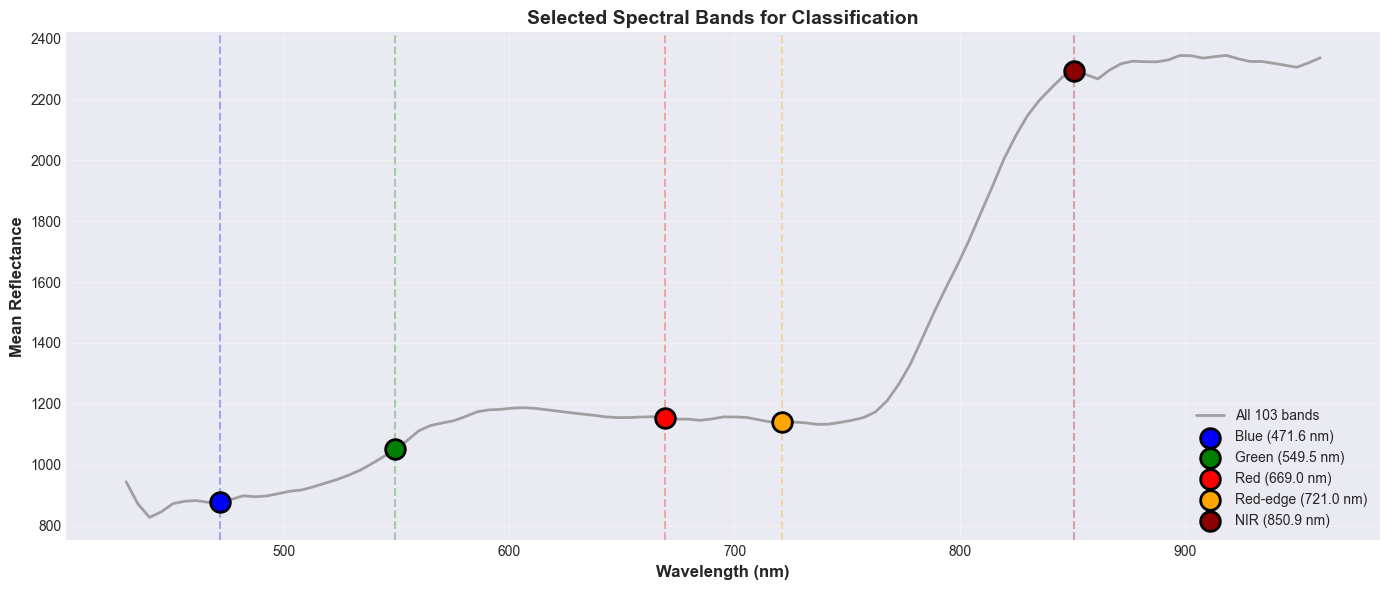


TRAINING LOGISTIC REGRESSION MODEL
Training model with 5 selected spectral bands...
Training complete!

Model Parameters:
  Number of features: 5
  Number of coefficients: 5
  Intercept: -0.427524

MAKING PREDICTIONS
Predictions complete!

MODEL PERFORMANCE EVALUATION

Training Accuracy: 89.53%
Testing Accuracy: 89.32%

Classification Report (Test Set):
----------------------------------------------------------------------
                precision    recall  f1-score   support

Non-Vegetation     0.9410    0.8356    0.8852      6319
    Vegetation     0.8561    0.9492    0.9003      6514

      accuracy                         0.8932     12833
     macro avg     0.8986    0.8924    0.8927     12833
  weighted avg     0.8979    0.8932    0.8928     12833


ROC-AUC Score: 0.9481

CONFUSION MATRIX

Confusion Matrix:
[[5280 1039]
 [ 331 6183]]


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


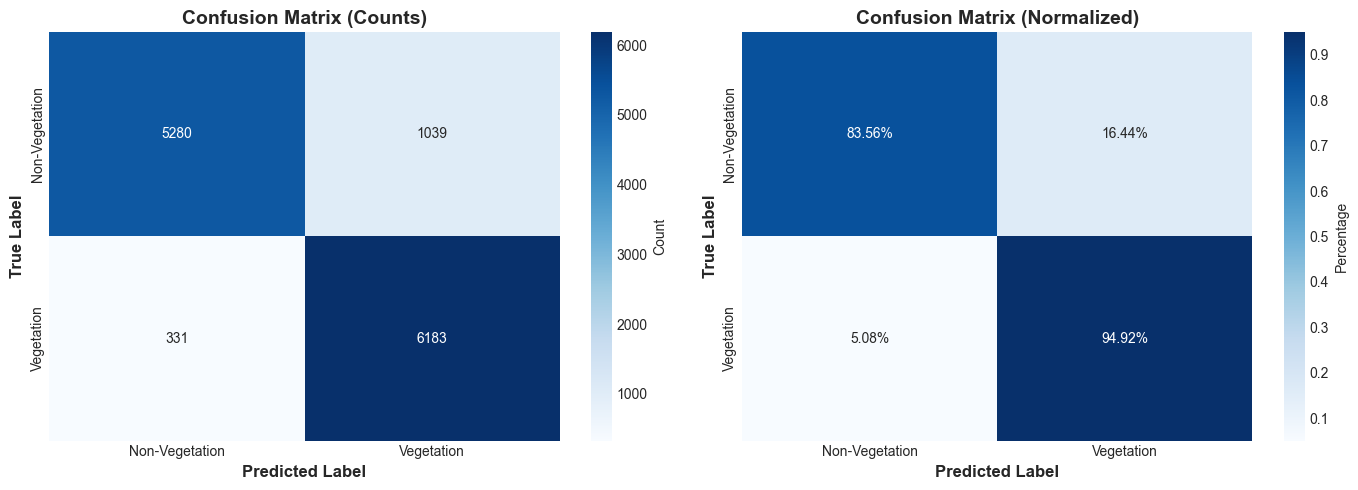


ROC CURVE ANALYSIS


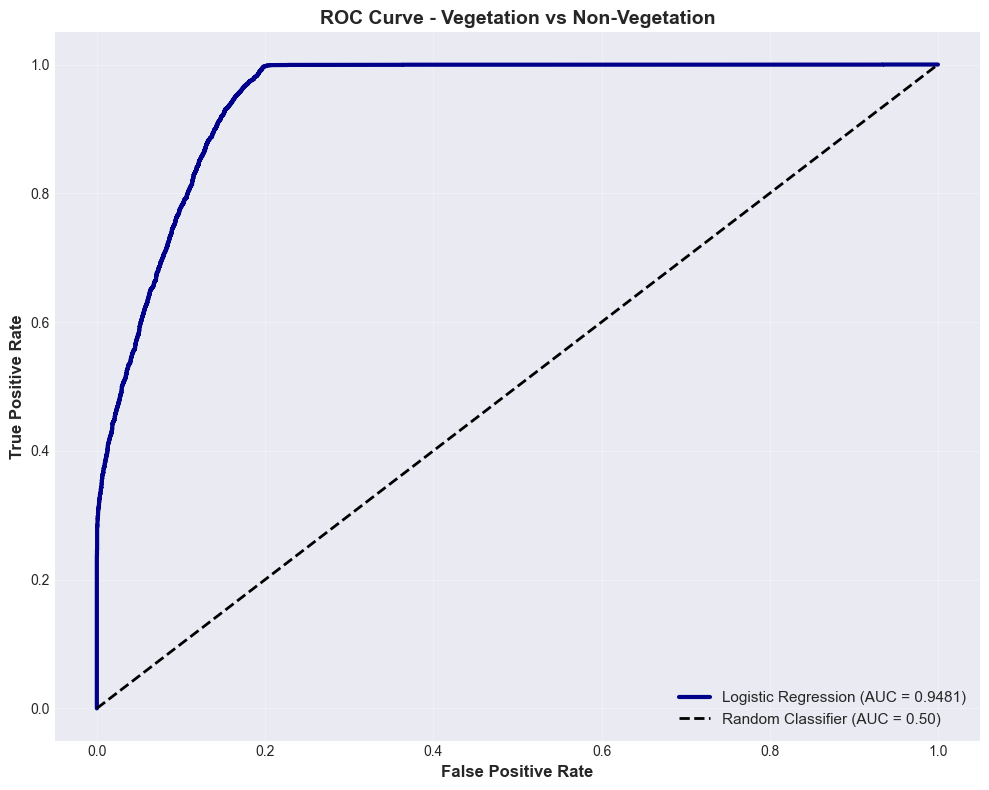


PREDICTION PROBABILITY DISTRIBUTION


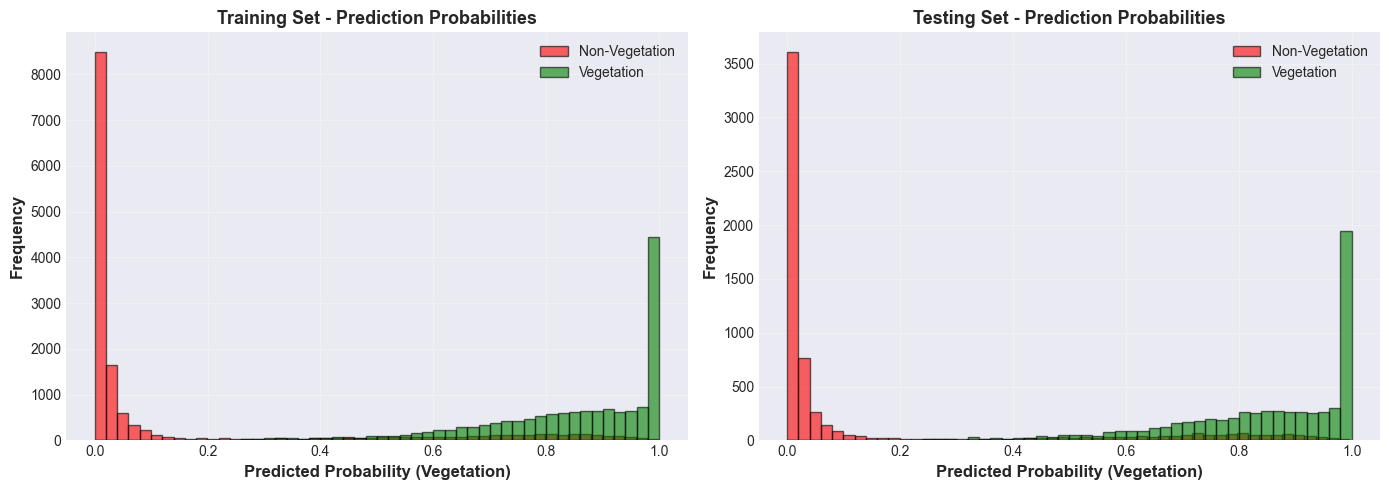


FEATURE IMPORTANCE ANALYSIS

Logistic Regression Coefficients for Selected Bands:
----------------------------------------------------------------------
Region          Wavelength (nm)    Band Index      Coefficient    
----------------------------------------------------------------------
Blue            471.57             8               1.667714       
Green           549.51             23              -5.812935      
Red             669.02             46              -3.565698      
Red-edge        720.98             56              3.410441       
NIR             850.88             81              3.285229       

Interpretation:
----------------------------------------------------------------------
  Blue: Positive coefficient (1.6677) → Higher reflectance favors VEGETATION
  Green: Negative coefficient (-5.8129) → Higher reflectance favors NON-VEGETATION
  Red: Negative coefficient (-3.5657) → Higher reflectance favors NON-VEGETATION
  Red-edge: Positive coefficient (3.4104) → 

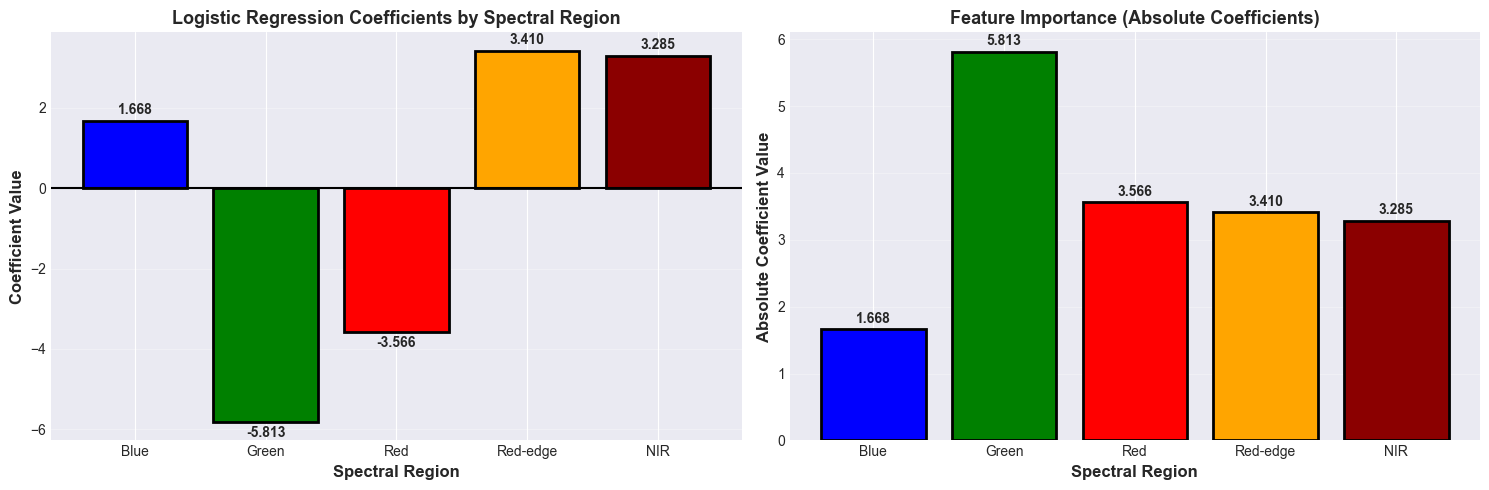


Most important spectral region: Green (coefficient = -5.8129)

SUMMARY

Binary Classification Results:
-------------------------------
Training Accuracy:     89.53%
Testing Accuracy:      89.32%
ROC-AUC Score:         0.9481

Precision (Veg):       0.8561
Recall (Veg):          0.9492
F1-Score (Veg):        0.9003

Precision (Non-Veg):   0.9410
Recall (Non-Veg):      0.8356
F1-Score (Non-Veg):    0.8852

Data Split:
-----------
Training samples:      29,943
Testing samples:       12,833
Split ratio:           70/30

Stratification:        ✓ By original 9 classes
Class weighting:       ✓ Balanced
Feature scaling:       ✓ StandardScaler

CLASSIFICATION COMPLETE


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import loadmat
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, 
                             accuracy_score, precision_recall_fscore_support,
                             roc_curve, auc, roc_auc_score)
from sklearn.model_selection import train_test_split
import pandas as pd

# Set random seed for reproducibility
np.random.seed(42)


# 1. LOAD AND PREPARE DATA

print("="*70)
print("BINARY CLASSIFICATION: VEGETATION vs NON-VEGETATION")
print("="*70)

# Load data
data = loadmat('PaviaU.mat')
gt = loadmat('PaviaU_gt.mat')

X = data['paviaU']
y = gt['paviaU_gt']

height, width, bands = X.shape
print(f"\nDataset Shape: {height} x {width} x {bands}")


# 2. CREATE BINARY LABELS

print("\n" + "="*70)
print("CREATING BINARY LABELS")
print("="*70)

# Class mapping
class_names = {
    0: 'Unlabeled',
    1: 'Asphalt',
    2: 'Meadows',          # VEGETATION
    3: 'Gravel',
    4: 'Trees',            # VEGETATION
    5: 'Painted metal sheets',
    6: 'Bare Soil',
    7: 'Bitumen',
    8: 'Self-Blocking Bricks',
    9: 'Shadows'
}

# Define vegetation classes
vegetation_classes = [2, 4]  # Meadows and Trees
non_vegetation_classes = [1, 3, 5, 6, 7, 8, 9]  # All others except unlabeled

print("Vegetation Classes:")
for c in vegetation_classes:
    print(f"  Class {c}: {class_names[c]}")

print("\nNon-Vegetation Classes:")
for c in non_vegetation_classes:
    print(f"  Class {c}: {class_names[c]}")




# 3. ANALYZE ORIGINAL CLASS DISTRIBUTION IN BINARY PROBLEM

print("\n" + "="*70)
print("ORIGINAL CLASS DISTRIBUTION IN BINARY PROBLEM")
print("="*70)

# Count samples per original class in each binary category
print("\nVEGETATION Group:")
print("-" * 50)
veg_total = 0
for class_id in vegetation_classes:
    count = np.sum(y == class_id)
    veg_total += count
    print(f"  {class_names[class_id]}: {count:,} samples")
print(f"Total Vegetation: {veg_total:,}")

print("\nNON-VEGETATION Group:")
print("-" * 50)
non_veg_total = 0
class_counts_non_veg = {}
for class_id in non_vegetation_classes:
    count = np.sum(y == class_id)
    non_veg_total += count
    class_counts_non_veg[class_id] = count
    print(f"  {class_names[class_id]}: {count:,} samples")
print(f"Total Non-Vegetation: {non_veg_total:,}")

print(f"\nBinary Class Balance:")
print(f"  Vegetation: {veg_total:,} ({veg_total/(veg_total+non_veg_total)*100:.2f}%)")
print(f"  Non-Vegetation: {non_veg_total:,} ({non_veg_total/(veg_total+non_veg_total)*100:.2f}%)")
print(f"  Imbalance Ratio: {max(veg_total, non_veg_total)/min(veg_total, non_veg_total):.2f}:1")


# 4. STRATIFIED SAMPLING STRATEGY

print("\n" + "="*70)
print("STRATIFIED SAMPLING STRATEGY")
print("="*70)



# 5. PREPARE DATA FOR CLASSIFICATION

print("\n" + "="*70)
print("PREPARING DATA")
print("="*70)

# Reshape spectral data
X_reshaped = X.reshape(-1, bands)
y_flat = y.ravel()

# CRITICAL: Get only labeled pixels 
labeled_mask = y_flat > 0
X_labeled = X_reshaped[labeled_mask]
y_original = y_flat[labeled_mask]

print(f"Total pixels in image: {len(y_flat):,}")
print(f"Unlabeled pixels (class 0): {np.sum(y_flat == 0):,}")
print(f"Total LABELED samples (excluding class 0): {len(y_original):,}")



# Create binary labels from the labeled data only
# Vegetation (Trees=4, Meadows=2) = 1
# Non-Vegetation (all others: 1,3,5,6,7,8,9) = 0
y_binary_final = np.zeros(len(y_original), dtype=int)
y_binary_final[np.isin(y_original, vegetation_classes)] = 1

print(f"\nBinary Label Distribution:")
print(f"  Vegetation (1): {np.sum(y_binary_final == 1):,}")
print(f"  Non-Vegetation (0): {np.sum(y_binary_final == 0):,}")
print(f"  Total: {len(y_binary_final):,}")


# 6. STRATIFIED TRAIN-TEST SPLIT

print("\n" + "="*70)
print("PERFORMING STRATIFIED TRAIN-TEST SPLIT")
print("="*70)

# Use original class labels for stratification to ensure equal representation
test_size = 0.30  # 70/30 split
print(f"Split Ratio: {(1-test_size)*100:.0f}% Train / {test_size*100:.0f}% Test")

# Stratified split based on ORIGINAL 9-class labels
X_train, X_test, y_train_binary, y_test_binary, y_train_original, y_test_original = train_test_split(
    X_labeled, 
    y_binary_final,
    y_original,
    test_size=test_size,
    stratify=y_original,  # Stratify by original classes
    random_state=42
)

print(f"\nTraining set size: {len(X_train):,}")
print(f"Testing set size: {len(X_test):,}")


# 7. VERIFY STRATIFICATION

print("\n" + "="*70)
print("VERIFYING STRATIFICATION")
print("="*70)

print("\nOriginal Class Distribution in Train/Test Sets:")
print("-" * 70)
print(f"{'Class':<25} {'Original':>10} {'Train':>10} {'Test':>10} {'Train %':>10} {'Test %':>10}")
print("-" * 70)

for class_id in range(1, 10):
    original_count = np.sum(y_original == class_id)
    train_count = np.sum(y_train_original == class_id)
    test_count = np.sum(y_test_original == class_id)
    train_pct = (train_count / original_count) * 100 if original_count > 0 else 0
    test_pct = (test_count / original_count) * 100 if original_count > 0 else 0
    
    print(f"{class_names[class_id]:<25} {original_count:>10,} {train_count:>10,} "
          f"{test_count:>10,} {train_pct:>9.1f}% {test_pct:>9.1f}%")

print("\nBinary Class Distribution:")
print("-" * 70)
print(f"{'Category':<25} {'Train Count':>15} {'Train %':>10} {'Test Count':>15} {'Test %':>10}")
print("-" * 70)

veg_train = np.sum(y_train_binary == 1)
non_veg_train = np.sum(y_train_binary == 0)
veg_test = np.sum(y_test_binary == 1)
non_veg_test = np.sum(y_test_binary == 0)

print(f"{'Vegetation':<25} {veg_train:>15,} {veg_train/len(y_train_binary)*100:>9.1f}% "
      f"{veg_test:>15,} {veg_test/len(y_test_binary)*100:>9.1f}%")
print(f"{'Non-Vegetation':<25} {non_veg_train:>15,} {non_veg_train/len(y_train_binary)*100:>9.1f}% "
      f"{non_veg_test:>15,} {non_veg_test/len(y_test_binary)*100:>9.1f}%")


# 8. SELECT SPECIFIC SPECTRAL BANDS

print("\n" + "="*70)
print("SELECTING SPECIFIC SPECTRAL BANDS")
print("="*70)

# Calculate wavelengths 
wavelengths = np.linspace(430, 960, bands)
print(f"Spectral range: {wavelengths[0]:.1f} - {wavelengths[-1]:.1f} nm")
print(f"Spectral resolution: {(wavelengths[1] - wavelengths[0]):.2f} nm/band")

#target wavelengths for each spectral region
target_wavelengths = {
    'Blue': 470,        # Blue region: ~450-495 nm
    'Green': 550,       # Green region: ~495-570 nm
    'Red': 670,         # Red region: ~620-750 nm
    'Red-edge': 720,    # Red-edge region: ~690-730 nm (vegetation transition)
    'NIR': 850          # Near-Infrared: ~750-900 nm
}

# Find closest band index for each target wavelength
selected_bands = {}
selected_band_indices = []

print("\nSelected Bands:")
print("-" * 70)
print(f"{'Region':<15} {'Target (nm)':<15} {'Actual (nm)':<15} {'Band Index':<15}")
print("-" * 70)

for region, target_wl in target_wavelengths.items():
    # Find closest wavelength
    idx = np.argmin(np.abs(wavelengths - target_wl))
    actual_wl = wavelengths[idx]
    selected_bands[region] = idx
    selected_band_indices.append(idx)
    print(f"{region:<15} {target_wl:<15.1f} {actual_wl:<15.2f} {idx:<15}")

print(f"\nTotal selected bands: {len(selected_band_indices)}")
print(f"Using bands: {selected_band_indices}")

# Extract only the selected bands from training and testing data
X_train_selected = X_train[:, selected_band_indices]
X_test_selected = X_test[:, selected_band_indices]

print(f"\nReduced feature dimensions:")
print(f"  Original: {X_train.shape[1]} bands")
print(f"  Selected: {X_train_selected.shape[1]} bands")
print(f"  Reduction: {(1 - X_train_selected.shape[1]/X_train.shape[1])*100:.1f}%")


# 9. FEATURE SCALING

print("\n" + "="*70)
print("FEATURE SCALING")
print("="*70)

# Standardize features 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected)

print("Applied StandardScaler (zero mean, unit variance)")
print(f"Training data shape: {X_train_scaled.shape}")
print(f"  Mean: {X_train_scaled.mean():.6f}")
print(f"  Std: {X_train_scaled.std():.6f}")

# Visualize selected bands on spectral signature
print("\nVisualizing selected bands on mean spectral signature...")
fig, ax = plt.subplots(figsize=(14, 6))

# Plot mean spectral signature of all training data
mean_signature = np.mean(X_train, axis=0)
ax.plot(wavelengths, mean_signature, linewidth=2, color='gray', alpha=0.7, 
        label='All 103 bands')

# Highlight selected bands
colors = {'Blue': 'blue', 'Green': 'green', 'Red': 'red', 
          'Red-edge': 'orange', 'NIR': 'darkred'}

for region, idx in selected_bands.items():
    ax.scatter(wavelengths[idx], mean_signature[idx], 
              s=200, c=colors[region], marker='o', 
              edgecolors='black', linewidths=2, zorder=5,
              label=f'{region} ({wavelengths[idx]:.1f} nm)')
    ax.axvline(x=wavelengths[idx], color=colors[region], 
              linestyle='--', alpha=0.3)

ax.set_xlabel('Wavelength (nm)', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Reflectance', fontsize=12, fontweight='bold')
ax.set_title('Selected Spectral Bands for Classification', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# 9. TRAIN LOGISTIC REGRESSION MODEL

print("\n" + "="*70)
print("TRAINING LOGISTIC REGRESSION MODEL")
print("="*70)

# Train model with balanced class weights to handle imbalance
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight='balanced',  # Handle class imbalance
    solver='lbfgs',
    verbose=1
)

print(f"Training model with {X_train_scaled.shape[1]} selected spectral bands...")
lr_model.fit(X_train_scaled, y_train_binary)
print("Training complete!")

print(f"\nModel Parameters:")
print(f"  Number of features: {X_train_scaled.shape[1]}")
print(f"  Number of coefficients: {len(lr_model.coef_[0])}")
print(f"  Intercept: {lr_model.intercept_[0]:.6f}")


# 10. MAKE PREDICTIONS

print("\n" + "="*70)
print("MAKING PREDICTIONS")
print("="*70)

# Predictions
y_train_pred = lr_model.predict(X_train_scaled)
y_test_pred = lr_model.predict(X_test_scaled)

# Prediction probabilities
y_train_proba = lr_model.predict_proba(X_train_scaled)[:, 1]
y_test_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

print("Predictions complete!")


# 11. EVALUATE MODEL PERFORMANCE

print("\n" + "="*70)
print("MODEL PERFORMANCE EVALUATION")
print("="*70)

# Training accuracy
train_accuracy = accuracy_score(y_train_binary, y_train_pred)
print(f"\nTraining Accuracy: {train_accuracy*100:.2f}%")

# Testing accuracy
test_accuracy = accuracy_score(y_test_binary, y_test_pred)
print(f"Testing Accuracy: {test_accuracy*100:.2f}%")

# Detailed metrics
print("\nClassification Report (Test Set):")
print("-" * 70)
target_names = ['Non-Vegetation', 'Vegetation']
print(classification_report(y_test_binary, y_test_pred, target_names=target_names, digits=4))

# Per-class metrics
precision, recall, f1, support = precision_recall_fscore_support(
    y_test_binary, y_test_pred, average=None
)



# ROC-AUC Score
roc_auc = roc_auc_score(y_test_binary, y_test_proba)
print(f"\nROC-AUC Score: {roc_auc:.4f}")


# 12. CONFUSION MATRIX

print("\n" + "="*70)
print("CONFUSION MATRIX")
print("="*70)

cm = confusion_matrix(y_test_binary, y_test_pred)
print("\nConfusion Matrix:")
print(cm)

# Visualize confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names,
            ax=axes[0], cbar_kws={'label': 'Count'})
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=12, fontweight='bold')

# Normalized
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names,
            ax=axes[1], cbar_kws={'label': 'Percentage'})
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Label', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


# 13. ROC CURVE

print("\n" + "="*70)
print("ROC CURVE ANALYSIS")
print("="*70)

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test_binary, y_test_proba)

# Plot ROC curve
fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(fpr, tpr, linewidth=3, label=f'Logistic Regression (AUC = {roc_auc:.4f})', color='darkblue')
ax.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier (AUC = 0.50)')
ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax.set_title('ROC Curve - Vegetation vs Non-Vegetation', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# 14. PREDICTION DISTRIBUTION

print("\n" + "="*70)
print("PREDICTION PROBABILITY DISTRIBUTION")
print("="*70)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training set
axes[0].hist(y_train_proba[y_train_binary == 0], bins=50, alpha=0.6, 
             label='Non-Vegetation', color='red', edgecolor='black')
axes[0].hist(y_train_proba[y_train_binary == 1], bins=50, alpha=0.6, 
             label='Vegetation', color='green', edgecolor='black')
axes[0].set_xlabel('Predicted Probability (Vegetation)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[0].set_title('Training Set - Prediction Probabilities', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Testing set
axes[1].hist(y_test_proba[y_test_binary == 0], bins=50, alpha=0.6, 
             label='Non-Vegetation', color='red', edgecolor='black')
axes[1].hist(y_test_proba[y_test_binary == 1], bins=50, alpha=0.6, 
             label='Vegetation', color='green', edgecolor='black')
axes[1].set_xlabel('Predicted Probability (Vegetation)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[1].set_title('Testing Set - Prediction Probabilities', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


# 15. FEATURE IMPORTANCE (COEFFICIENTS)

print("\n" + "="*70)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*70)

# Get coefficients for the 5 selected bands
coefficients = lr_model.coef_[0]

print("\nLogistic Regression Coefficients for Selected Bands:")
print("-" * 70)
print(f"{'Region':<15} {'Wavelength (nm)':<18} {'Band Index':<15} {'Coefficient':<15}")
print("-" * 70)

regions_list = ['Blue', 'Green', 'Red', 'Red-edge', 'NIR']
for i, region in enumerate(regions_list):
    idx = selected_bands[region]
    wl = wavelengths[idx]
    coef = coefficients[i]
    print(f"{region:<15} {wl:<18.2f} {idx:<15} {coef:<15.6f}")

print("\nInterpretation:")
print("-" * 70)
for i, region in enumerate(regions_list):
    coef = coefficients[i]
    if coef > 0:
        print(f"  {region}: Positive coefficient ({coef:.4f}) → Higher reflectance favors VEGETATION")
    else:
        print(f"  {region}: Negative coefficient ({coef:.4f}) → Higher reflectance favors NON-VEGETATION")

# Visualize coefficients
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar plot of coefficients
colors_bar = [colors[region] for region in regions_list]
axes[0].bar(regions_list, coefficients, color=colors_bar, edgecolor='black', linewidth=2)
axes[0].axhline(y=0, color='black', linestyle='-', linewidth=1.5)
axes[0].set_xlabel('Spectral Region', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Coefficient Value', fontsize=12, fontweight='bold')
axes[0].set_title('Logistic Regression Coefficients by Spectral Region', 
                  fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (region, coef) in enumerate(zip(regions_list, coefficients)):
    axes[0].text(i, coef + (0.1 if coef > 0 else -0.1), f'{coef:.3f}', 
                ha='center', va='bottom' if coef > 0 else 'top', 
                fontweight='bold', fontsize=10)

# Coefficient importance (absolute values)
abs_coef = np.abs(coefficients)
axes[1].bar(regions_list, abs_coef, color=colors_bar, edgecolor='black', linewidth=2)
axes[1].set_xlabel('Spectral Region', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Absolute Coefficient Value', fontsize=12, fontweight='bold')
axes[1].set_title('Feature Importance (Absolute Coefficients)', 
                  fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# Add value labels
for i, (region, abs_c) in enumerate(zip(regions_list, abs_coef)):
    axes[1].text(i, abs_c + 0.05, f'{abs_c:.3f}', 
                ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

# Find most important feature
most_important_idx = np.argmax(abs_coef)
most_important_region = regions_list[most_important_idx]
print(f"\nMost important spectral region: {most_important_region} "
      f"(coefficient = {coefficients[most_important_idx]:.4f})")


# 16. SUMMARY

print("\n" + "="*70)
print("SUMMARY")
print("="*70)
print(f"""
Binary Classification Results:
-------------------------------
Training Accuracy:     {train_accuracy*100:.2f}%
Testing Accuracy:      {test_accuracy*100:.2f}%
ROC-AUC Score:         {roc_auc:.4f}

Precision (Veg):       {precision[1]:.4f}
Recall (Veg):          {recall[1]:.4f}
F1-Score (Veg):        {f1[1]:.4f}

Precision (Non-Veg):   {precision[0]:.4f}
Recall (Non-Veg):      {recall[0]:.4f}
F1-Score (Non-Veg):    {f1[0]:.4f}

Data Split:
-----------
Training samples:      {len(X_train):,}
Testing samples:       {len(X_test):,}
Split ratio:           70/30

Stratification:        ✓ By original 9 classes
Class weighting:       ✓ Balanced
Feature scaling:       ✓ StandardScaler
""")

print("="*70)
print("CLASSIFICATION COMPLETE")
print("="*70)

COMPREHENSIVE MODEL EVALUATION REPORT
Binary Classification: Vegetation vs Non-Vegetation

1. ACCURACY METRICS

Training Set:
  Overall Accuracy: 89.53%
  Per-Class Accuracy (Non-Vegetation): 83.44%
  Per-Class Accuracy (Vegetation): 95.43%
  Mean Per-Class Accuracy: 89.44%

Testing Set:
  Overall Accuracy: 89.32%
  Per-Class Accuracy (Non-Vegetation): 83.56%
  Per-Class Accuracy (Vegetation): 94.92%
  Mean Per-Class Accuracy: 89.24%

2. PRECISION, RECALL, AND F1-SCORE

TRAINING SET:
--------------------------------------------------------------------------------
Class                Precision    Recall       F1-Score     Support     
--------------------------------------------------------------------------------
Non-Vegetation       0.9465       0.8344       0.8870       14,744      
Vegetation           0.8559       0.9543       0.9024       15,199      
--------------------------------------------------------------------------------
Macro Average        0.9012       0.8944       0.

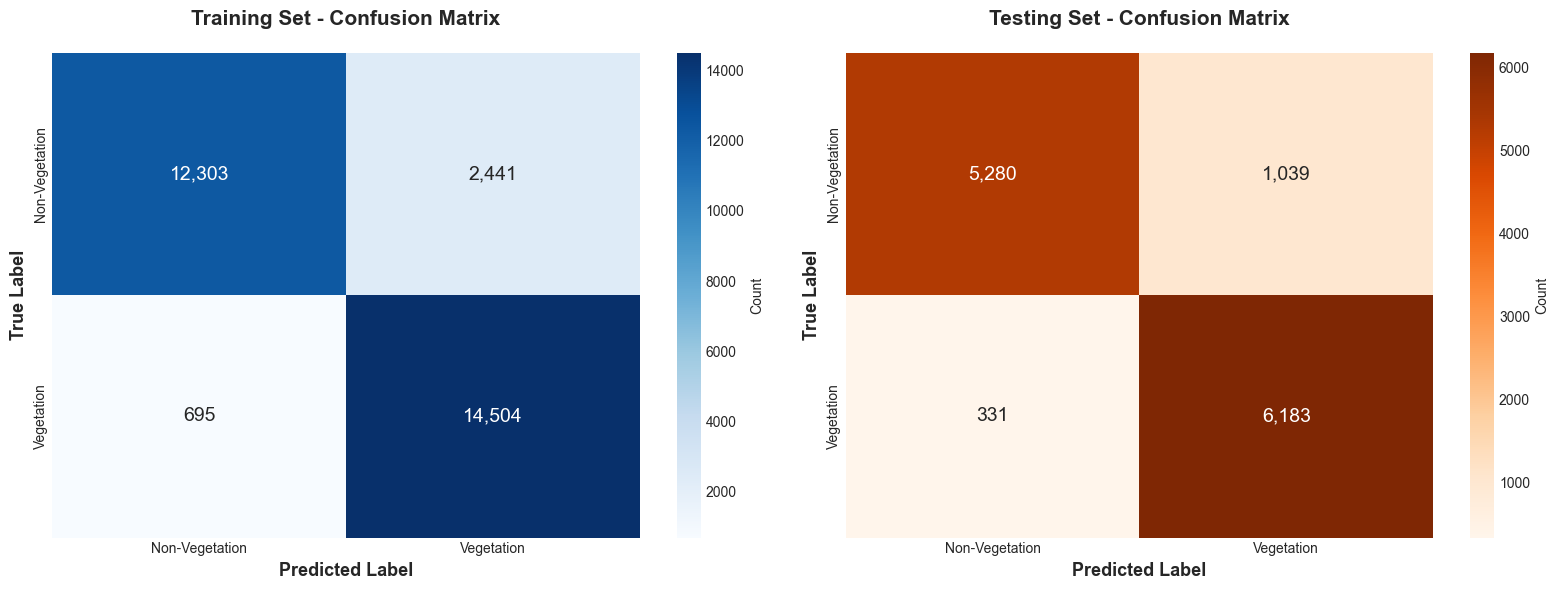


5. ROC CURVE AND AUC

Area Under the Curve (AUC):
  Training Set AUC:   0.9486
  Testing Set AUC:    0.9481
  Difference:         0.0005


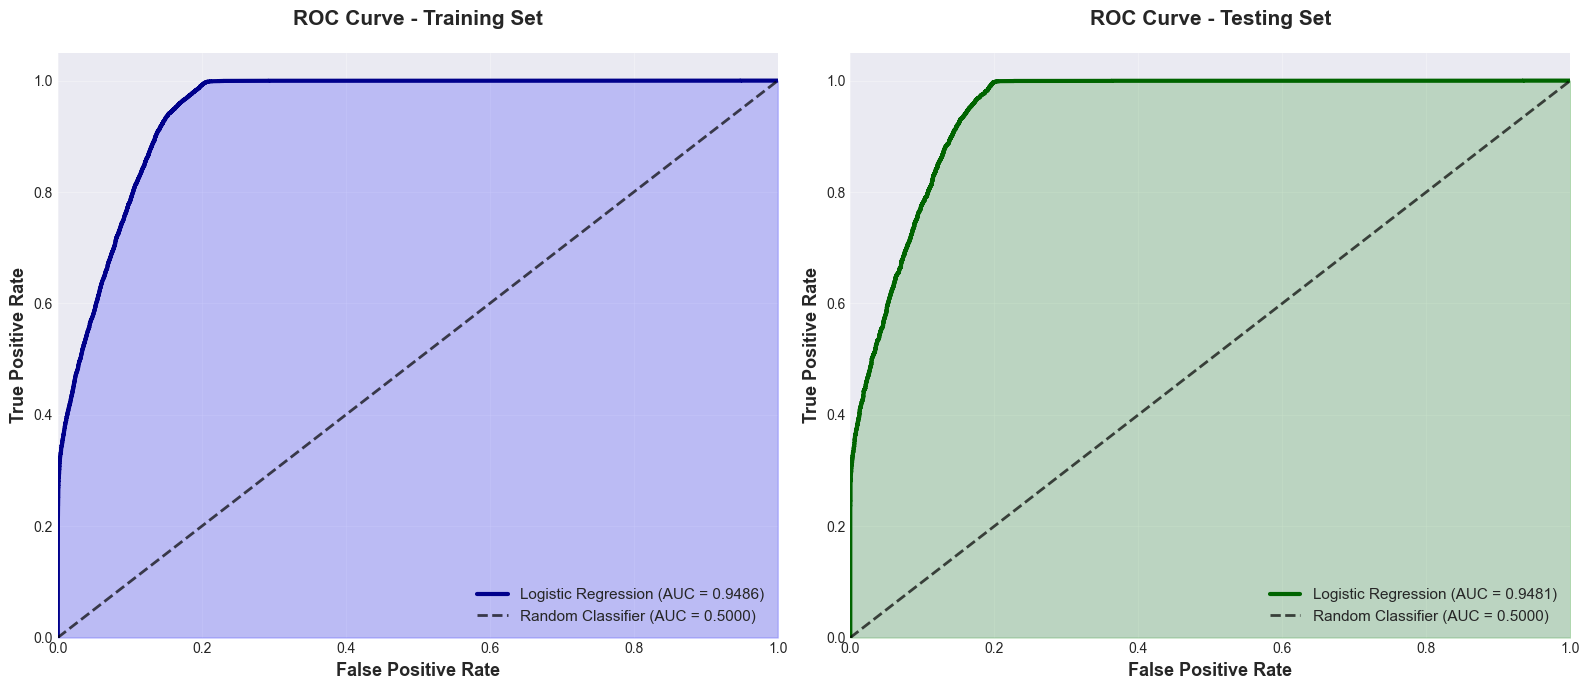


ROC Curve Interpretation:
--------------------------------------------------------------------------------

The ROC (Receiver Operating Characteristic) curve plots:
  • X-axis: False Positive Rate (FPR) = FP / (FP + TN)
  • Y-axis: True Positive Rate (TPR) = TP / (TP + FN) = Recall

The curve shows the tradeoff between TPR and FPR across all classification thresholds.


Our Results:
  • Training AUC = 0.9486: Excellent performance
  • Testing AUC = 0.9481: Excellent performance
  • The model demonstrates excellent ability to distinguish between 
    Vegetation and Non-Vegetation


6. COMPARATIVE VISUALIZATION


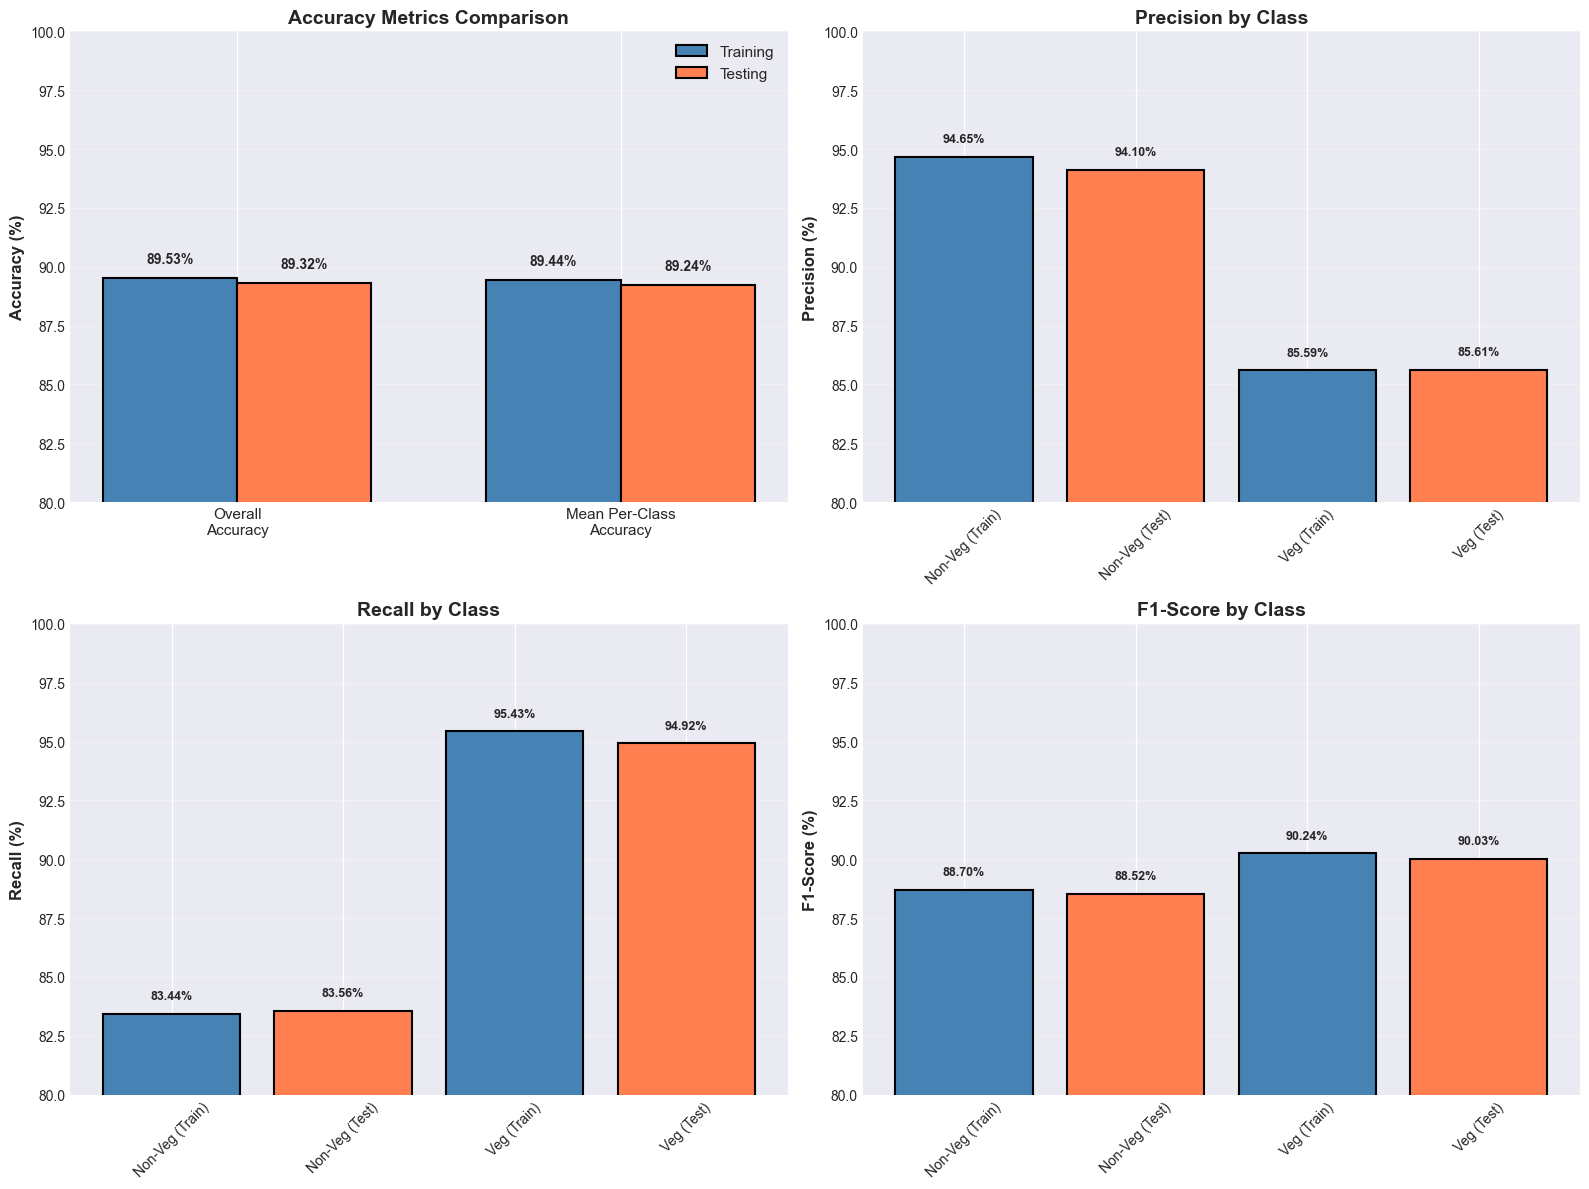


7. COMPREHENSIVE SUMMARY TABLE

--------------------------------------------------------------------------------
Metric                         Training                  Testing                  
--------------------------------------------------------------------------------
Overall Accuracy               89.53%                    89.32%                   
Mean Per-Class Accuracy        89.44%                    89.24%                   
Precision (Non-Veg)            94.65%                    94.10%                   
Precision (Vegetation)         85.59%                    85.61%                   
Macro Avg Precision            90.12%                    89.86%                   
Recall (Non-Veg)               83.44%                    83.56%                   
Recall (Vegetation)            95.43%                    94.92%                   
Macro Avg Recall               89.44%                    89.24%                   
F1-Score (Non-Veg)             88.70%                    8

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             confusion_matrix, roc_curve, auc, roc_auc_score)


# COMPREHENSIVE MODEL EVALUATION AND INTERPRETATION


print("="*80)
print("COMPREHENSIVE MODEL EVALUATION REPORT")
print("Binary Classification: Vegetation vs Non-Vegetation")
print("="*80)



# 1. ACCURACY METRICS

print("\n" + "="*80)
print("1. ACCURACY METRICS")
print("="*80)

# Training Accuracy
train_accuracy = accuracy_score(y_train_binary, y_train_pred)
print(f"\nTraining Set:")
print(f"  Overall Accuracy: {train_accuracy*100:.2f}%")

# Per-class accuracy for training
train_precision, train_recall, train_f1, train_support = precision_recall_fscore_support(
    y_train_binary, y_train_pred, average=None
)
train_per_class_acc = []
for class_idx in [0, 1]:
    mask = (y_train_binary == class_idx)
    class_correct = np.sum((y_train_pred[mask] == class_idx))
    class_total = np.sum(mask)
    class_acc = class_correct / class_total
    train_per_class_acc.append(class_acc)

train_mean_per_class_acc = np.mean(train_per_class_acc)
print(f"  Per-Class Accuracy (Non-Vegetation): {train_per_class_acc[0]*100:.2f}%")
print(f"  Per-Class Accuracy (Vegetation): {train_per_class_acc[1]*100:.2f}%")
print(f"  Mean Per-Class Accuracy: {train_mean_per_class_acc*100:.2f}%")

# Testing Accuracy
test_accuracy = accuracy_score(y_test_binary, y_test_pred)
print(f"\nTesting Set:")
print(f"  Overall Accuracy: {test_accuracy*100:.2f}%")

# Per-class accuracy for testing
test_precision, test_recall, test_f1, test_support = precision_recall_fscore_support(
    y_test_binary, y_test_pred, average=None
)
test_per_class_acc = []
for class_idx in [0, 1]:
    mask = (y_test_binary == class_idx)
    class_correct = np.sum((y_test_pred[mask] == class_idx))
    class_total = np.sum(mask)
    class_acc = class_correct / class_total
    test_per_class_acc.append(class_acc)

test_mean_per_class_acc = np.mean(test_per_class_acc)
print(f"  Per-Class Accuracy (Non-Vegetation): {test_per_class_acc[0]*100:.2f}%")
print(f"  Per-Class Accuracy (Vegetation): {test_per_class_acc[1]*100:.2f}%")
print(f"  Mean Per-Class Accuracy: {test_mean_per_class_acc*100:.2f}%")


# 2. PRECISION, RECALL, F1-SCORE - DETAILED

print("\n" + "="*80)
print("2. PRECISION, RECALL, AND F1-SCORE")
print("="*80)

class_names = ['Non-Vegetation', 'Vegetation']

# Training Set Metrics
print("\nTRAINING SET:")
print("-" * 80)
print(f"{'Class':<20} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Support':<12}")
print("-" * 80)
for i, name in enumerate(class_names):
    print(f"{name:<20} {train_precision[i]:<12.4f} {train_recall[i]:<12.4f} "
          f"{train_f1[i]:<12.4f} {train_support[i]:<12,}")

train_macro_precision = np.mean(train_precision)
train_macro_recall = np.mean(train_recall)
train_macro_f1 = np.mean(train_f1)

print("-" * 80)
print(f"{'Macro Average':<20} {train_macro_precision:<12.4f} {train_macro_recall:<12.4f} "
      f"{train_macro_f1:<12.4f}")

# Testing Set Metrics
print("\nTESTING SET:")
print("-" * 80)
print(f"{'Class':<20} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Support':<12}")
print("-" * 80)
for i, name in enumerate(class_names):
    print(f"{name:<20} {test_precision[i]:<12.4f} {test_recall[i]:<12.4f} "
          f"{test_f1[i]:<12.4f} {test_support[i]:<12,}")

test_macro_precision = np.mean(test_precision)
test_macro_recall = np.mean(test_recall)
test_macro_f1 = np.mean(test_f1)

print("-" * 80)
print(f"{'Macro Average':<20} {test_macro_precision:<12.4f} {test_macro_recall:<12.4f} "
      f"{test_macro_f1:<12.4f}")


# 3. WHAT PRECISION AND RECALL REPRESENT

print("\n" + "="*80)
print("3. UNDERSTANDING PRECISION AND RECALL")
print("="*80)




# 4. CONFUSION MATRIX ANALYSIS

print("\n" + "="*80)
print("4. CONFUSION MATRIX ANALYSIS")
print("="*80)

# From the provided confusion matrix
cm_test = np.array([[5280, 1039], 
                     [331, 6183]])

print("\nTesting Set Confusion Matrix:")
print("-" * 80)
print(f"{'':>20} {'Predicted Non-Veg':<20} {'Predicted Veg':<20}")
print("-" * 80)
print(f"{'Actual Non-Veg':<20} {cm_test[0,0]:<20,} {cm_test[0,1]:<20,}")
print(f"{'Actual Veg':<20} {cm_test[1,0]:<20,} {cm_test[1,1]:<20,}")
print("-" * 80)

print("\nBreakdown:")
print(f"  True Negatives (TN):  {cm_test[0,0]:,} - Correctly predicted Non-Vegetation")
print(f"  False Positives (FP): {cm_test[0,1]:,} - Non-Vegetation wrongly predicted as Vegetation")
print(f"  False Negatives (FN): {cm_test[1,0]:,} - Vegetation wrongly predicted as Non-Vegetation")
print(f"  True Positives (TP):  {cm_test[1,1]:,} - Correctly predicted Vegetation")

print("\nError Analysis:")
total_errors = cm_test[0,1] + cm_test[1,0]
print(f"  Total Errors: {total_errors:,} out of {cm_test.sum():,} ({total_errors/cm_test.sum()*100:.2f}%)")
print(f"  Type I Error (False Positives): {cm_test[0,1]:,} ({cm_test[0,1]/total_errors*100:.1f}% of errors)")
print(f"  Type II Error (False Negatives): {cm_test[1,0]:,} ({cm_test[1,0]/total_errors*100:.1f}% of errors)")

# Visualize confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Training confusion matrix (calculate from predictions)
cm_train = confusion_matrix(y_train_binary, y_train_pred)

# Training
sns.heatmap(cm_train, annot=True, fmt=',d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            ax=axes[0], cbar_kws={'label': 'Count'}, annot_kws={'size': 14})
axes[0].set_title('Training Set - Confusion Matrix', fontsize=15, fontweight='bold', pad=20)
axes[0].set_ylabel('True Label', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=13, fontweight='bold')

# Testing
sns.heatmap(cm_test, annot=True, fmt=',d', cmap='Oranges', 
            xticklabels=class_names, yticklabels=class_names,
            ax=axes[1], cbar_kws={'label': 'Count'}, annot_kws={'size': 14})
axes[1].set_title('Testing Set - Confusion Matrix', fontsize=15, fontweight='bold', pad=20)
axes[1].set_ylabel('True Label', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted Label', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()


# 5. ROC CURVE ANALYSIS

print("\n" + "="*80)
print("5. ROC CURVE AND AUC")
print("="*80)

# Calculate ROC curve for both training and testing
fpr_train, tpr_train, thresholds_train = roc_curve(y_train_binary, y_train_proba)
roc_auc_train = auc(fpr_train, tpr_train)

fpr_test, tpr_test, thresholds_test = roc_curve(y_test_binary, y_test_proba)
roc_auc_test = auc(fpr_test, tpr_test)

print(f"\nArea Under the Curve (AUC):")
print(f"  Training Set AUC:   {roc_auc_train:.4f}")
print(f"  Testing Set AUC:    {roc_auc_test:.4f}")
print(f"  Difference:         {abs(roc_auc_train - roc_auc_test):.4f}")

# Plot ROC curves
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Training ROC
axes[0].plot(fpr_train, tpr_train, linewidth=3, 
            label=f'Logistic Regression (AUC = {roc_auc_train:.4f})', 
            color='darkblue')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=2, 
            label='Random Classifier (AUC = 0.5000)', alpha=0.7)
axes[0].fill_between(fpr_train, tpr_train, alpha=0.2, color='blue')
axes[0].set_xlabel('False Positive Rate', fontsize=13, fontweight='bold')
axes[0].set_ylabel('True Positive Rate', fontsize=13, fontweight='bold')
axes[0].set_title('ROC Curve - Training Set', fontsize=15, fontweight='bold', pad=20)
axes[0].legend(fontsize=11, loc='lower right')
axes[0].grid(alpha=0.3)
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])

# Testing ROC
axes[1].plot(fpr_test, tpr_test, linewidth=3, 
            label=f'Logistic Regression (AUC = {roc_auc_test:.4f})', 
            color='darkgreen')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=2, 
            label='Random Classifier (AUC = 0.5000)', alpha=0.7)
axes[1].fill_between(fpr_test, tpr_test, alpha=0.2, color='green')
axes[1].set_xlabel('False Positive Rate', fontsize=13, fontweight='bold')
axes[1].set_ylabel('True Positive Rate', fontsize=13, fontweight='bold')
axes[1].set_title('ROC Curve - Testing Set', fontsize=15, fontweight='bold', pad=20)
axes[1].legend(fontsize=11, loc='lower right')
axes[1].grid(alpha=0.3)
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])

plt.tight_layout()
plt.show()

print("\nROC Curve Interpretation:")
print("-" * 80)
print("""
The ROC (Receiver Operating Characteristic) curve plots:
  • X-axis: False Positive Rate (FPR) = FP / (FP + TN)
  • Y-axis: True Positive Rate (TPR) = TP / (TP + FN) = Recall

The curve shows the tradeoff between TPR and FPR across all classification thresholds.


Our Results:
  • Training AUC = {:.4f}: {} performance
  • Testing AUC = {:.4f}: {} performance
  • The model demonstrates {} ability to distinguish between 
    Vegetation and Non-Vegetation
""".format(roc_auc_train, 
          "Excellent" if roc_auc_train >= 0.9 else "Good",
          roc_auc_test,
          "Excellent" if roc_auc_test >= 0.9 else "Good",
          "excellent" if roc_auc_test >= 0.9 else "good"))


# 6. COMPARATIVE METRICS VISUALIZATION

print("\n" + "="*80)
print("6. COMPARATIVE VISUALIZATION")
print("="*80)

# Create comparison plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Accuracy Comparison
metrics_names = ['Overall\nAccuracy', 'Mean Per-Class\nAccuracy']
train_acc = [train_accuracy * 100, train_mean_per_class_acc * 100]
test_acc = [test_accuracy * 100, test_mean_per_class_acc * 100]

x = np.arange(len(metrics_names))
width = 0.35

axes[0, 0].bar(x - width/2, train_acc, width, label='Training', 
               color='steelblue', edgecolor='black', linewidth=1.5)
axes[0, 0].bar(x + width/2, test_acc, width, label='Testing', 
               color='coral', edgecolor='black', linewidth=1.5)
axes[0, 0].set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Accuracy Metrics Comparison', fontsize=14, fontweight='bold')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(metrics_names, fontsize=11)
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(axis='y', alpha=0.3)
axes[0, 0].set_ylim([80, 100])

# Add value labels
for i, (train, test) in enumerate(zip(train_acc, test_acc)):
    axes[0, 0].text(i - width/2, train + 0.5, f'{train:.2f}%', 
                   ha='center', va='bottom', fontweight='bold', fontsize=10)
    axes[0, 0].text(i + width/2, test + 0.5, f'{test:.2f}%', 
                   ha='center', va='bottom', fontweight='bold', fontsize=10)

# 2. Precision by Class
precision_data = {
    'Non-Veg (Train)': train_precision[0] * 100,
    'Non-Veg (Test)': test_precision[0] * 100,
    'Veg (Train)': train_precision[1] * 100,
    'Veg (Test)': test_precision[1] * 100
}
bars = axes[0, 1].bar(precision_data.keys(), precision_data.values(), 
                      color=['steelblue', 'coral', 'steelblue', 'coral'],
                      edgecolor='black', linewidth=1.5)
axes[0, 1].set_ylabel('Precision (%)', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Precision by Class', fontsize=14, fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(axis='y', alpha=0.3)
axes[0, 1].set_ylim([80, 100])

for bar in bars:
    height = bar.get_height()
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., height + 0.5,
                   f'{height:.2f}%', ha='center', va='bottom', 
                   fontweight='bold', fontsize=9)

# 3. Recall by Class
recall_data = {
    'Non-Veg (Train)': train_recall[0] * 100,
    'Non-Veg (Test)': test_recall[0] * 100,
    'Veg (Train)': train_recall[1] * 100,
    'Veg (Test)': test_recall[1] * 100
}
bars = axes[1, 0].bar(recall_data.keys(), recall_data.values(), 
                      color=['steelblue', 'coral', 'steelblue', 'coral'],
                      edgecolor='black', linewidth=1.5)
axes[1, 0].set_ylabel('Recall (%)', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Recall by Class', fontsize=14, fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(axis='y', alpha=0.3)
axes[1, 0].set_ylim([80, 100])

for bar in bars:
    height = bar.get_height()
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., height + 0.5,
                   f'{height:.2f}%', ha='center', va='bottom', 
                   fontweight='bold', fontsize=9)

# 4. F1-Score by Class
f1_data = {
    'Non-Veg (Train)': train_f1[0] * 100,
    'Non-Veg (Test)': test_f1[0] * 100,
    'Veg (Train)': train_f1[1] * 100,
    'Veg (Test)': test_f1[1] * 100
}
bars = axes[1, 1].bar(f1_data.keys(), f1_data.values(), 
                      color=['steelblue', 'coral', 'steelblue', 'coral'],
                      edgecolor='black', linewidth=1.5)
axes[1, 1].set_ylabel('F1-Score (%)', fontsize=12, fontweight='bold')
axes[1, 1].set_title('F1-Score by Class', fontsize=14, fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(axis='y', alpha=0.3)
axes[1, 1].set_ylim([80, 100])

for bar in bars:
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height + 0.5,
                   f'{height:.2f}%', ha='center', va='bottom', 
                   fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()


# 7. SUMMARY TABLE

print("\n" + "="*80)
print("7. COMPREHENSIVE SUMMARY TABLE")
print("="*80)

summary_data = {
    'Metric': [
        'Overall Accuracy',
        'Mean Per-Class Accuracy',
        'Precision (Non-Veg)',
        'Precision (Vegetation)',
        'Macro Avg Precision',
        'Recall (Non-Veg)',
        'Recall (Vegetation)',
        'Macro Avg Recall',
        'F1-Score (Non-Veg)',
        'F1-Score (Vegetation)',
        'Macro Avg F1-Score',
        'ROC-AUC Score'
    ],
    'Training': [
        f"{train_accuracy*100:.2f}%",
        f"{train_mean_per_class_acc*100:.2f}%",
        f"{train_precision[0]*100:.2f}%",
        f"{train_precision[1]*100:.2f}%",
        f"{train_macro_precision*100:.2f}%",
        f"{train_recall[0]*100:.2f}%",
        f"{train_recall[1]*100:.2f}%",
        f"{train_macro_recall*100:.2f}%",
        f"{train_f1[0]*100:.2f}%",
        f"{train_f1[1]*100:.2f}%",
        f"{train_macro_f1*100:.2f}%",
        f"{roc_auc_train:.4f}"
    ],
    'Testing': [
        f"{test_accuracy*100:.2f}%",
        f"{test_mean_per_class_acc*100:.2f}%",
        f"{test_precision[0]*100:.2f}%",
        f"{test_precision[1]*100:.2f}%",
        f"{test_macro_precision*100:.2f}%",
        f"{test_recall[0]*100:.2f}%",
        f"{test_recall[1]*100:.2f}%",
        f"{test_macro_recall*100:.2f}%",
        f"{test_f1[0]*100:.2f}%",
        f"{test_f1[1]*100:.2f}%",
        f"{test_macro_f1*100:.2f}%",
        f"{roc_auc_test:.4f}"
    ]
}

print("\n" + "-" * 80)
print(f"{'Metric':<30} {'Training':<25} {'Testing':<25}")
print("-" * 80)
for metric, train_val, test_val in zip(summary_data['Metric'], 
                                        summary_data['Training'], 
                                        summary_data['Testing']):
    print(f"{metric:<30} {train_val:<25} {test_val:<25}")
print("-" * 80)



print("\n" + "="*80)
print("END OF COMPREHENSIVE EVALUATION REPORT")
print("="*80)

Explanation:
Stratification- In binary classification generated from multi-class data, maintaining intra-group variety is a crucial but sometimes disregarded difficulty that is addressed by the stratified sampling technique.  Random sampling may result in significant distribution mismatches if it is not stratified by the original nine classes. For example, the training set may be dominated by Meadows, which are easily classified vegetation with strong spectral signatures, while the test set may be dominated by Trees, which have more complex canopy structures. This could lead to artificially inflated or deflated performance metrics that do not accurately reflect true model generalization.

Precision and recall - Precision is represented by the question, "When the model predicts a class, how often is it correct?"   Only 5.9% of the pixels are false positives (vegetation misclassified as non-vegetation), and the model correctly classifies a pixel as such 94.1% of the time with a precision of 0.941 for Non-Vegetation.   The precision of 0.856 for vegetation indicates an accuracy of 85.6% in vegetation prediction, with 14.4% of non-vegetation materials incorrectly classified as vegetation (presumably challenging situations like bare soil or shadows that share some spectral features with stressed vegetation).
"Of all actual instances of a class, how many did the model find?" is what recall is all about.   With a non-vegetation recall of 0.836, the model accurately identifies 83.6% of all true non-vegetation pixels while overlooking 16.4% of false negatives that are misclassified as vegetation.   With a vegetation recall of 0.949, the model exhibits exceptional detection, capturing 94.9% of all real vegetation and missing only 5.1%.   This asymmetry indicates that the model is more sensitive to vegetation (high recall) but more cautious about non-vegetation (lower recall, higher precision).   The pattern suggests that the model might be slightly biased toward predicting vegetation when it is unknown, given the NIR band's excellent discriminative capability and vegetation's characteristically high reflectance.
The trade-off is obvious: in order to prevent missing vegetation (high vegetation recall 0.949), the model sometimes incorrectly classifies non-vegetation as vegetation (lower non-vegetation recall 0.836).   Given that false negatives, which overlook actual vegetation, are typically more expensive than false positives, this makes sense for applications involving vegetation monitoring.   The ROC-AUC of 0.948 indicates excellent overall discriminative performance across all decision thresholds for both training and testing partitions, despite the test metrics demonstrating acceptable generalization without significant overfitting.

ROC-AUC and Probabilities
The probability histograms show excellent class separability and strong model confidence.   Both the training and testing sets show a characteristic bimodal distribution of highly confident predictions from the model.  Vegetation samples focus around probability 1.0, which indicates strong confidence in vegetation, while the majority of non-vegetation samples cluster around probability 0.0, which indicates strong confidence in non-vegetation.   As demonstrated by the clear separation and minimal overlap in the middle probability ranges (0.2-0.8), the selected spectral bands—Blue, Green, Red, Red-edge, and NIR—offer highly discriminative features that clearly define decision boundaries between the two classes.
The distributions of the training and testing sets are almost identical, demonstrating robust generalization without overfitting.   If the model were overfitting, the training set would have even more extreme probability concentrations (all samples at 0.0 or 1.0), while the testing set would have more uncertainty with samples spread across middle probabilities.   Instead, both sets still show similar trends, proving that the stratified sampling strategy worked to preserve representative class distributions.   Spectral ambiguous cases, such as stressed vegetation with lower chlorophyll content that shares spectral characteristics with non-vegetation materials, bare soil with some green vegetation remnants, or likely shadows with low reflectance across all bands, are represented by the small "uncertainty region" (samples with probabilities between 0.3 and 0.7).

The model gives a randomly selected vegetation pixel a higher vegetation probability than a randomly selected non-vegetation pixel 94.8% of the time, according to the ROC-AUC of 0.948, which measures this remarkable separation.   The model typically generates precise, dependable predictions that closely resemble the actual labels rather than operating in the ambiguous middle ground where classification errors typically occur.  The high precision and recall are also explained by the steep probability peaks at the extremes.

1.c

XGBOOST MULTI-CLASS CLASSIFICATION
9-Class Classification: Pavia University Dataset

1. LOADING AND PREPARING DATA
Dataset Shape: 610 x 340 x 103

Total labeled samples: 42,776

Original Class Distribution:
------------------------------------------------------------
Class 1 (Asphalt): 6,631 samples
Class 2 (Meadows): 18,649 samples
Class 3 (Gravel): 2,099 samples
Class 4 (Trees): 3,064 samples
Class 5 (Painted metal sheets): 1,345 samples
Class 6 (Bare Soil): 5,029 samples
Class 7 (Bitumen): 1,330 samples
Class 8 (Self-Blocking Bricks): 3,682 samples
Class 9 (Shadows): 947 samples

2. SELECTING SPECTRAL BANDS

Selected Bands:
------------------------------------------------------------
Blue: Band 8 (471.57 nm)
Green: Band 23 (549.51 nm)
Red: Band 46 (669.02 nm)
Red-edge: Band 56 (720.98 nm)
NIR: Band 81 (850.88 nm)

Reduced features: 103 → 5 bands

Adding vegetation indices as additional features...
Enhanced features: 8 features
Feature names: ['Blue', 'Green', 'Red', 'Red-edge', 'NIR

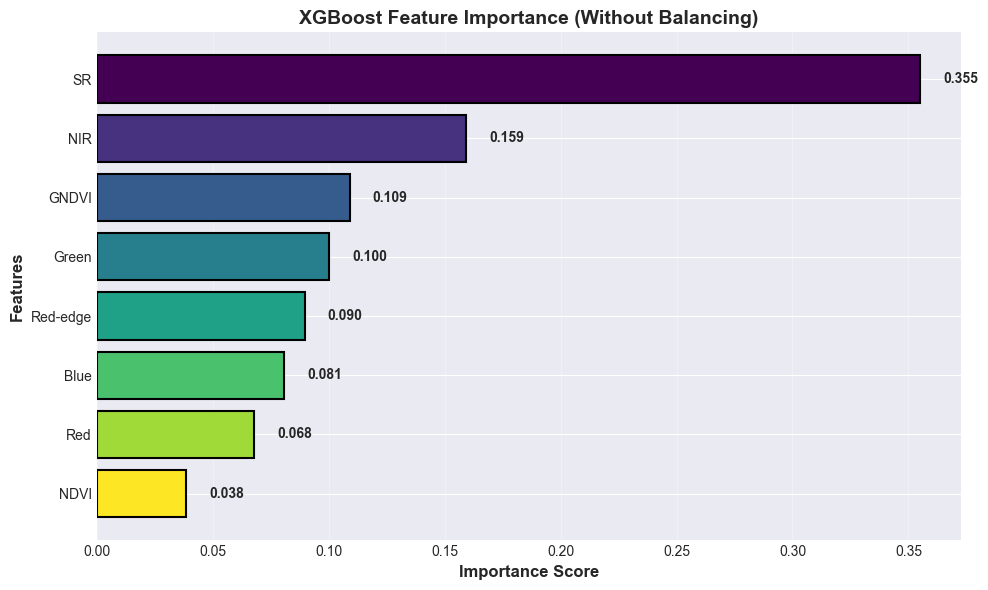


Feature Importance Interpretation:
--------------------------------------------------------------------------------

Top 3 Most Important Features:
1. SR: 0.3550
2. NIR: 0.1593
3. GNDVI: 0.1090

The most important features are critical for distinguishing between the 9 classes.
High importance in vegetation indices (NDVI, GNDVI) suggests they provide strong
discriminative power beyond individual spectral bands.


8. CONFUSION MATRIX ANALYSIS (WITHOUT BALANCING)


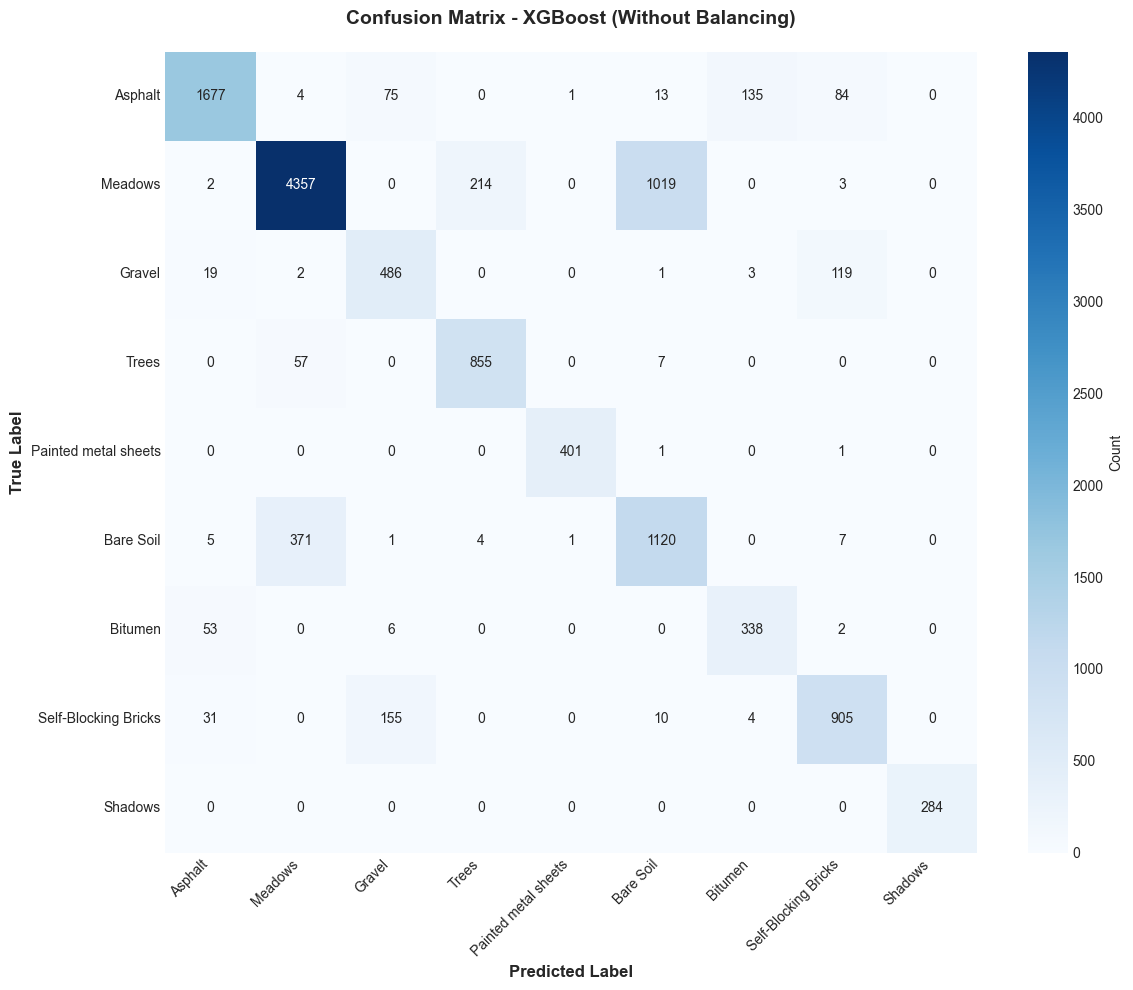


Confusion Matrix Analysis:
--------------------------------------------------------------------------------

Most Frequently Confused Class Pairs:
--------------------------------------------------------------------------------
True Class                Predicted As                   Count  % of True
--------------------------------------------------------------------------------
Meadows                   Bare Soil                      1,019      18.21%
Bare Soil                 Meadows                          371      24.59%
Meadows                   Trees                            214       3.82%
Self-Blocking Bricks      Gravel                           155      14.03%
Asphalt                   Bitumen                          135       6.79%
Gravel                    Self-Blocking Bricks             119      18.89%
Asphalt                   Self-Blocking Bricks              84       4.22%
Asphalt                   Gravel                            75       3.77%
Trees           

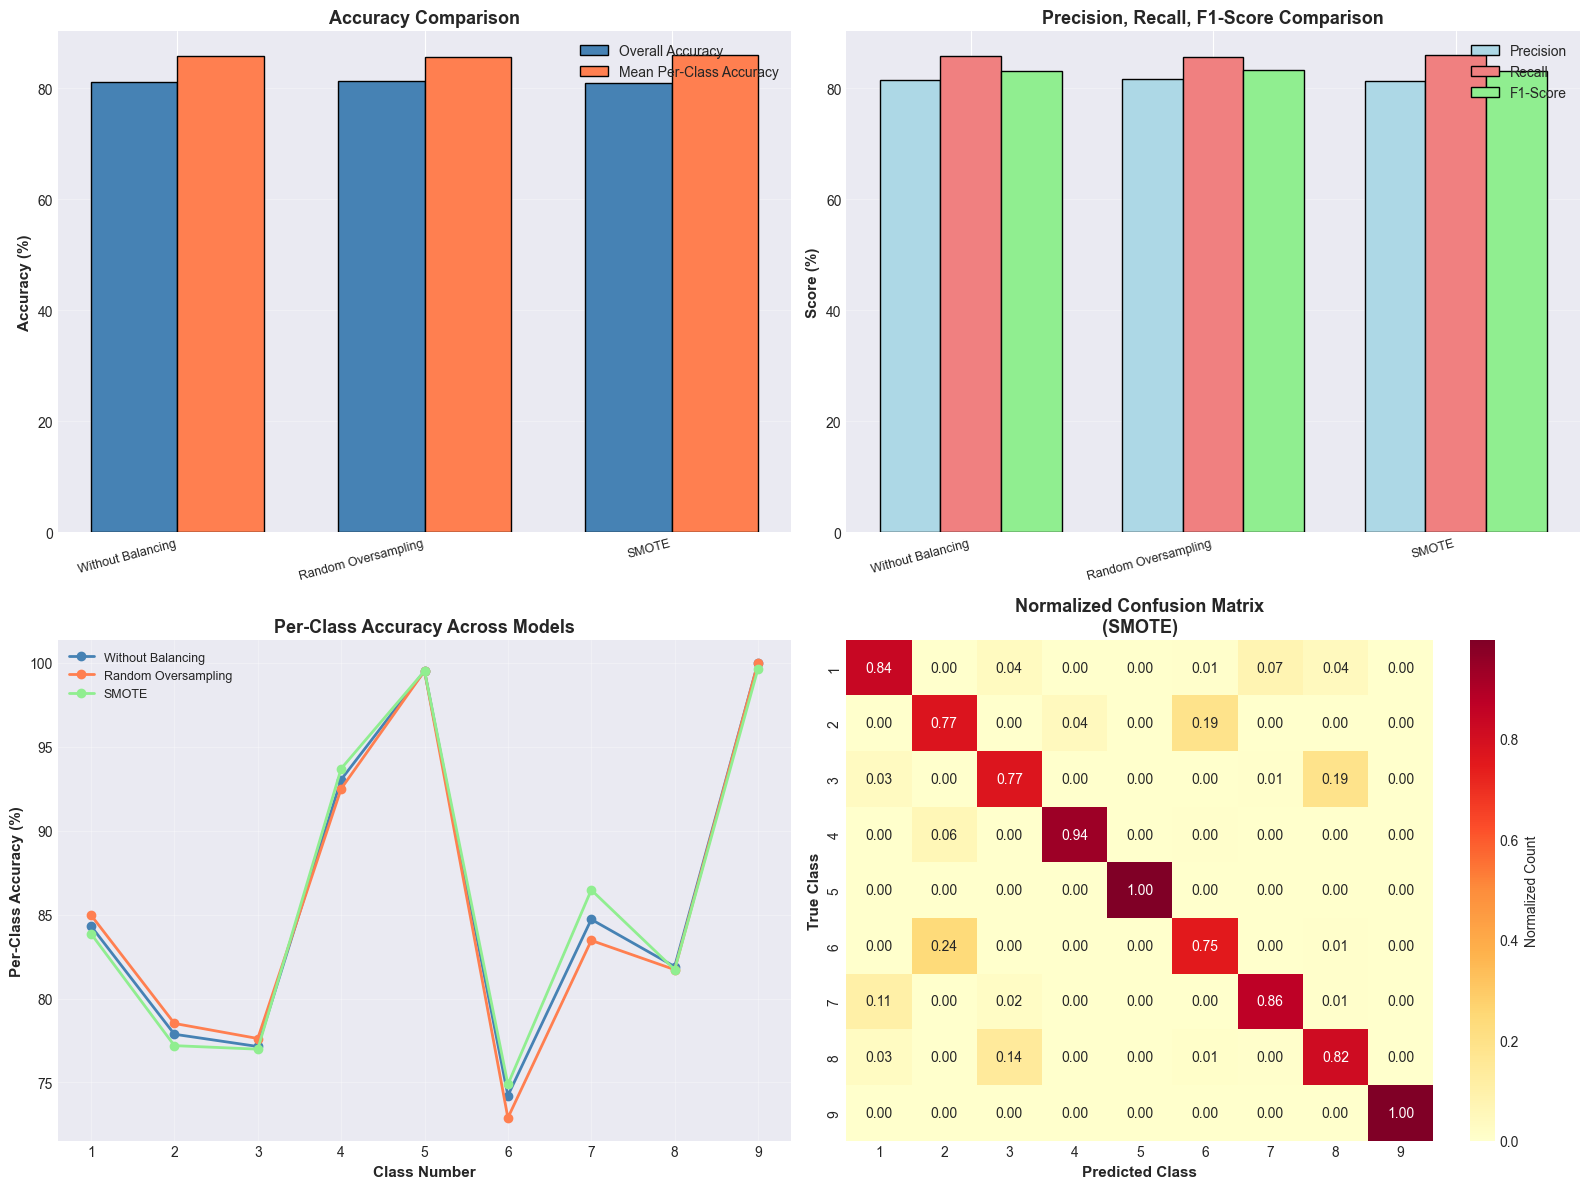


12. DETAILED ANALYSIS OF BEST PERFORMING MODEL

Best Model: SMOTE
Mean Per-Class Accuracy: 85.99%

Per-Class Performance (Best Model):
--------------------------------------------------------------------------------
Class                        Precision       Recall     F1-Score      Support
--------------------------------------------------------------------------------
Asphalt                         0.9440       0.8386       0.8882        1,989
Meadows                         0.9116       0.7719       0.8360        5,595
Gravel                          0.6644       0.7698       0.7132          630
Trees                           0.7943       0.9369       0.8597          919
Painted metal sheets            0.9926       0.9950       0.9938          403
Bare Soil                       0.5122       0.7488       0.6083        1,509
Bitumen                         0.6859       0.8647       0.7650          399
Self-Blocking Bricks            0.8077       0.8172       0.8124        1,105


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import loadmat
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             confusion_matrix, classification_report)
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter
import xgboost as xgb
import pandas as pd

# Set random seed for reproducibility
np.random.seed(42)

print("="*80)
print("XGBOOST MULTI-CLASS CLASSIFICATION")
print("9-Class Classification: Pavia University Dataset")
print("="*80)


# 1. LOAD AND PREPARE DATA

print("\n" + "="*80)
print("1. LOADING AND PREPARING DATA")
print("="*80)

# Load data
data = loadmat('PaviaU.mat')
gt = loadmat('PaviaU_gt.mat')

X = data['paviaU']
y = gt['paviaU_gt']

height, width, bands = X.shape
print(f"Dataset Shape: {height} x {width} x {bands}")

# Class names
class_names = {
    1: 'Asphalt',
    2: 'Meadows',
    3: 'Gravel',
    4: 'Trees',
    5: 'Painted metal sheets',
    6: 'Bare Soil',
    7: 'Bitumen',
    8: 'Self-Blocking Bricks',
    9: 'Shadows'
}

# Reshape and filter labeled data
X_reshaped = X.reshape(-1, bands)
y_flat = y.ravel()

# Get only labeled pixels (exclude class 0)
labeled_mask = y_flat > 0
X_labeled = X_reshaped[labeled_mask]
y_labeled = y_flat[labeled_mask]

print(f"\nTotal labeled samples: {len(y_labeled):,}")

# Analyze class distribution
unique_classes, counts = np.unique(y_labeled, return_counts=True)
print("\nOriginal Class Distribution:")
print("-" * 60)
for cls, count in zip(unique_classes, counts):
    print(f"Class {cls} ({class_names[cls]}): {count:,} samples")


# 2. SELECT SPECTRAL BANDS

print("\n" + "="*80)
print("2. SELECTING SPECTRAL BANDS")
print("="*80)

# Calculate wavelengths
wavelengths = np.linspace(430, 960, bands)

# Select 5 key bands (from previous problem)
target_wavelengths = {
    'Blue': 470,
    'Green': 550,
    'Red': 670,
    'Red-edge': 720,
    'NIR': 850
}

selected_bands = {}
selected_band_indices = []

print("\nSelected Bands:")
print("-" * 60)
for region, target_wl in target_wavelengths.items():
    idx = np.argmin(np.abs(wavelengths - target_wl))
    selected_bands[region] = idx
    selected_band_indices.append(idx)
    print(f"{region}: Band {idx} ({wavelengths[idx]:.2f} nm)")

# Extract selected bands
X_selected = X_labeled[:, selected_band_indices]
print(f"\nReduced features: {bands} → {len(selected_band_indices)} bands")


print("\nAdding vegetation indices as additional features...")
# NDVI: (NIR - Red) / (NIR + Red)
nir_band = X_labeled[:, selected_bands['NIR']]
red_band = X_labeled[:, selected_bands['Red']]
green_band = X_labeled[:, selected_bands['Green']]
blue_band = X_labeled[:, selected_bands['Blue']]

ndvi = (nir_band - red_band) / (nir_band + red_band + 1e-8)
# Green NDVI
gndvi = (nir_band - green_band) / (nir_band + green_band + 1e-8)
# Simple Ratio
sr = nir_band / (red_band + 1e-8)

# Combine original bands with indices
X_enhanced = np.column_stack([X_selected, ndvi, gndvi, sr])
feature_names = ['Blue', 'Green', 'Red', 'Red-edge', 'NIR', 'NDVI', 'GNDVI', 'SR']
print(f"Enhanced features: {X_enhanced.shape[1]} features")
print(f"Feature names: {feature_names}")


# 3. TRAIN-TEST SPLIT (STRATIFIED)

print("\n" + "="*80)
print("3. CREATING TRAIN-TEST SPLIT")
print("="*80)

# Stratified split to ensure all 9 classes equally represented
X_train, X_test, y_train, y_test = train_test_split(
    X_enhanced,
    y_labeled,
    test_size=0.30,
    stratify=y_labeled,
    random_state=42
)

print(f"Training set size: {len(X_train):,}")
print(f"Testing set size: {len(X_test):,}")

# Verify stratification
print("\nClass Distribution Verification:")
print("-" * 60)
print(f"{'Class':<25} {'Original':>10} {'Train':>10} {'Test':>10}")
print("-" * 60)
for cls in range(1, 10):
    orig_count = np.sum(y_labeled == cls)
    train_count = np.sum(y_train == cls)
    test_count = np.sum(y_test == cls)
    print(f"{class_names[cls]:<25} {orig_count:>10,} {train_count:>10,} {test_count:>10,}")


# 4. DATA PREPROCESSING

print("\n" + "="*80)
print("4. DATA PREPROCESSING")
print("="*80)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Applied StandardScaler (zero mean, unit variance)")
print(f"Training data - Mean: {X_train_scaled.mean():.6f}, Std: {X_train_scaled.std():.6f}")

# Adjust labels to start from 0 (XGBoost requirement)
y_train_adjusted = y_train - 1
y_test_adjusted = y_test - 1


# 5. TRAIN XGBOOST MODEL (WITHOUT BALANCING)

print("\n" + "="*80)
print("5. TRAINING XGBOOST MODEL (WITHOUT BALANCING)")
print("="*80)

# Calculate class weights for imbalanced data
class_counts = Counter(y_train_adjusted)
total_samples = len(y_train_adjusted)
n_classes = len(class_counts)

# Compute scale_pos_weight for each class
sample_weights = np.ones(len(y_train_adjusted))
for cls in range(n_classes):
    class_weight = total_samples / (n_classes * class_counts[cls])
    sample_weights[y_train_adjusted == cls] = class_weight

print("Training XGBoost with class weights...")

# XGBoost parameters
xgb_params = {
    'objective': 'multi:softmax',
    'num_class': 9,
    'max_depth': 6,
    'learning_rate': 0.1,
    'n_estimators': 200,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'eval_metric': 'mlogloss',
    'tree_method': 'hist'
}

# Train model
model_unbalanced = xgb.XGBClassifier(**xgb_params)
model_unbalanced.fit(
    X_train_scaled, 
    y_train_adjusted,
    sample_weight=sample_weights,
    verbose=False
)

print("Training complete!")

# Predictions
y_train_pred_unbal = model_unbalanced.predict(X_train_scaled)
y_test_pred_unbal = model_unbalanced.predict(X_test_scaled)


# 6. EVALUATE MODEL (WITHOUT BALANCING)

print("\n" + "="*80)
print("6. MODEL EVALUATION (WITHOUT BALANCING)")
print("="*80)

# Calculate metrics
train_acc_unbal = accuracy_score(y_train_adjusted, y_train_pred_unbal)
test_acc_unbal = accuracy_score(y_test_adjusted, y_test_pred_unbal)

print(f"\nOverall Accuracy:")
print(f"  Training: {train_acc_unbal*100:.2f}%")
print(f"  Testing: {test_acc_unbal*100:.2f}%")

# Per-class accuracy
test_per_class_acc_unbal = []
for cls in range(9):
    mask = (y_test_adjusted == cls)
    if np.sum(mask) > 0:
        class_acc = np.sum(y_test_pred_unbal[mask] == cls) / np.sum(mask)
        test_per_class_acc_unbal.append(class_acc)
    else:
        test_per_class_acc_unbal.append(0)

mean_per_class_acc_unbal = np.mean(test_per_class_acc_unbal)
print(f"  Mean Per-Class Accuracy (Test): {mean_per_class_acc_unbal*100:.2f}%")

# Precision, Recall, F1-Score
precision_unbal, recall_unbal, f1_unbal, support_unbal = precision_recall_fscore_support(
    y_test_adjusted, y_test_pred_unbal, average=None, zero_division=0
)

print("\nDetailed Classification Report (Test Set):")
print("-" * 80)
print(f"{'Class':<25} {'Precision':>12} {'Recall':>12} {'F1-Score':>12} {'Support':>12}")
print("-" * 80)
for i in range(9):
    print(f"{class_names[i+1]:<25} {precision_unbal[i]:>12.4f} {recall_unbal[i]:>12.4f} "
          f"{f1_unbal[i]:>12.4f} {support_unbal[i]:>12,}")

print("-" * 80)
print(f"{'Macro Average':<25} {np.mean(precision_unbal):>12.4f} "
      f"{np.mean(recall_unbal):>12.4f} {np.mean(f1_unbal):>12.4f}")
print(f"{'Weighted Average':<25} {np.average(precision_unbal, weights=support_unbal):>12.4f} "
      f"{np.average(recall_unbal, weights=support_unbal):>12.4f} "
      f"{np.average(f1_unbal, weights=support_unbal):>12.4f}")


# 7. FEATURE IMPORTANCE (WITHOUT BALANCING)

print("\n" + "="*80)
print("7. FEATURE IMPORTANCE ANALYSIS")
print("="*80)

# Get feature importance
importance_scores = model_unbalanced.feature_importances_
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance_scores
}).sort_values('Importance', ascending=False)

print("\nFeature Importance Ranking:")
print("-" * 60)
for idx, row in importance_df.iterrows():
    print(f"{row['Feature']:<15} {row['Importance']:>10.4f}")

# Plot feature importance
fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(feature_names)))
bars = ax.barh(importance_df['Feature'], importance_df['Importance'], 
               color=colors, edgecolor='black', linewidth=1.5)
ax.set_xlabel('Importance Score', fontsize=12, fontweight='bold')
ax.set_ylabel('Features', fontsize=12, fontweight='bold')
ax.set_title('XGBoost Feature Importance (Without Balancing)', 
             fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

# Add value labels
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.01, bar.get_y() + bar.get_height()/2, 
            f'{width:.3f}', ha='left', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nFeature Importance Interpretation:")
print("-" * 80)
print(f"""
Top 3 Most Important Features:
1. {importance_df.iloc[0]['Feature']}: {importance_df.iloc[0]['Importance']:.4f}
2. {importance_df.iloc[1]['Feature']}: {importance_df.iloc[1]['Importance']:.4f}
3. {importance_df.iloc[2]['Feature']}: {importance_df.iloc[2]['Importance']:.4f}

The most important features are critical for distinguishing between the 9 classes.
High importance in vegetation indices (NDVI, GNDVI) suggests they provide strong
discriminative power beyond individual spectral bands.
""")


# 8. CONFUSION MATRIX (WITHOUT BALANCING)

print("\n" + "="*80)
print("8. CONFUSION MATRIX ANALYSIS (WITHOUT BALANCING)")
print("="*80)

# Compute confusion matrix
cm_unbal = confusion_matrix(y_test_adjusted, y_test_pred_unbal)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm_unbal, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[class_names[i] for i in range(1, 10)],
            yticklabels=[class_names[i] for i in range(1, 10)],
            ax=ax, cbar_kws={'label': 'Count'})
ax.set_title('Confusion Matrix - XGBoost (Without Balancing)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Analyze confusion
print("\nConfusion Matrix Analysis:")
print("-" * 80)

# Normalized confusion matrix (by row)
cm_normalized = cm_unbal.astype('float') / cm_unbal.sum(axis=1)[:, np.newaxis]

# Find most confused pairs
confusion_pairs = []
for i in range(9):
    for j in range(9):
        if i != j and cm_unbal[i, j] > 10:  # More than 10 misclassifications
            confusion_pairs.append((i+1, j+1, cm_unbal[i, j], cm_normalized[i, j]))

confusion_pairs.sort(key=lambda x: x[2], reverse=True)

print("\nMost Frequently Confused Class Pairs:")
print("-" * 80)
print(f"{'True Class':<25} {'Predicted As':<25} {'Count':>10} {'% of True':>10}")
print("-" * 80)
for true_cls, pred_cls, count, pct in confusion_pairs[:10]:
    print(f"{class_names[true_cls]:<25} {class_names[pred_cls]:<25} "
          f"{count:>10,} {pct*100:>10.2f}%")


# 9. DATA BALANCING STRATEGIES

print("\n" + "="*80)
print("9. IMPLEMENTING DATA BALANCING STRATEGIES")
print("="*80)

print("\nOriginal Training Set Class Distribution:")
print("-" * 60)
original_dist = Counter(y_train_adjusted)
for cls in range(9):
    print(f"Class {cls+1} ({class_names[cls+1]}): {original_dist[cls]:,} samples")

# Strategy 1: Random Oversampling
print("\n" + "-"*60)
print("Strategy 1: Random Oversampling (Majority Class Size)")
print("-" * 60)

ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train_scaled, y_train_adjusted)

print(f"Balanced training set size: {len(X_train_ros):,}")
ros_dist = Counter(y_train_ros)
for cls in range(9):
    print(f"Class {cls+1} ({class_names[cls+1]}): {ros_dist[cls]:,} samples")

# Strategy 2: SMOTE (Synthetic Minority Over-sampling)
print("\n" + "-"*60)
print("Strategy 2: SMOTE (Synthetic Minority Over-sampling)")
print("-" * 60)

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train_adjusted)

print(f"Balanced training set size: {len(X_train_smote):,}")
smote_dist = Counter(y_train_smote)
for cls in range(9):
    print(f"Class {cls+1} ({class_names[cls+1]}): {smote_dist[cls]:,} samples")



# 10. TRAIN MODELS WITH BALANCED DATA

print("\n" + "="*80)
print("10. TRAINING XGBOOST MODELS WITH BALANCED DATA")
print("="*80)

# Model 1: Random Oversampling
print("\nTraining with Random Oversampling...")
model_ros = xgb.XGBClassifier(**xgb_params)
model_ros.fit(X_train_ros, y_train_ros, verbose=False)
y_test_pred_ros = model_ros.predict(X_test_scaled)

# Model 2: SMOTE
print("Training with SMOTE...")
model_smote = xgb.XGBClassifier(**xgb_params)
model_smote.fit(X_train_smote, y_train_smote, verbose=False)
y_test_pred_smote = model_smote.predict(X_test_scaled)



print("All models trained!")


# 11. COMPARE PERFORMANCE

print("\n" + "="*80)
print("11. PERFORMANCE COMPARISON: WITH VS WITHOUT BALANCING")
print("="*80)

# Calculate metrics for all models
models_results = {
    'Without Balancing': y_test_pred_unbal,
    'Random Oversampling': y_test_pred_ros,
    'SMOTE': y_test_pred_smote,
    
}

comparison_metrics = []

for model_name, predictions in models_results.items():
    acc = accuracy_score(y_test_adjusted, predictions)
    
    # Per-class accuracy
    per_class_acc = []
    for cls in range(9):
        mask = (y_test_adjusted == cls)
        if np.sum(mask) > 0:
            class_acc = np.sum(predictions[mask] == cls) / np.sum(mask)
            per_class_acc.append(class_acc)
    
    mean_per_class = np.mean(per_class_acc)
    
    # Precision, Recall, F1
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_test_adjusted, predictions, average='macro', zero_division=0
    )
    
    comparison_metrics.append({
        'Model': model_name,
        'Overall Accuracy': acc * 100,
        'Mean Per-Class Accuracy': mean_per_class * 100,
        'Macro Precision': prec * 100,
        'Macro Recall': rec * 100,
        'Macro F1-Score': f1 * 100
    })

# Create comparison table
comp_df = pd.DataFrame(comparison_metrics)
print("\nComparative Performance Metrics:")
print("="*80)
print(comp_df.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics = ['Overall Accuracy', 'Mean Per-Class Accuracy', 'Macro Precision', 
           'Macro Recall', 'Macro F1-Score']
colors_palette = ['steelblue', 'coral', 'lightgreen', 'gold']

# Plot 1: Overall vs Mean Per-Class Accuracy
ax = axes[0, 0]
x = np.arange(len(comp_df))
width = 0.35
ax.bar(x - width/2, comp_df['Overall Accuracy'], width, 
       label='Overall Accuracy', color='steelblue', edgecolor='black')
ax.bar(x + width/2, comp_df['Mean Per-Class Accuracy'], width, 
       label='Mean Per-Class Accuracy', color='coral', edgecolor='black')
ax.set_ylabel('Accuracy (%)', fontsize=11, fontweight='bold')
ax.set_title('Accuracy Comparison', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comp_df['Model'], rotation=15, ha='right', fontsize=9)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Plot 2: Precision, Recall, F1
ax = axes[0, 1]
x = np.arange(len(comp_df))
width = 0.25
ax.bar(x - width, comp_df['Macro Precision'], width, 
       label='Precision', color='lightblue', edgecolor='black')
ax.bar(x, comp_df['Macro Recall'], width, 
       label='Recall', color='lightcoral', edgecolor='black')
ax.bar(x + width, comp_df['Macro F1-Score'], width, 
       label='F1-Score', color='lightgreen', edgecolor='black')
ax.set_ylabel('Score (%)', fontsize=11, fontweight='bold')
ax.set_title('Precision, Recall, F1-Score Comparison', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comp_df['Model'], rotation=15, ha='right', fontsize=9)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Plot 3: Per-Class Accuracy for each model
ax = axes[1, 0]
for idx, (model_name, predictions) in enumerate(models_results.items()):
    per_class_acc = []
    for cls in range(9):
        mask = (y_test_adjusted == cls)
        if np.sum(mask) > 0:
            class_acc = np.sum(predictions[mask] == cls) / np.sum(mask)
            per_class_acc.append(class_acc * 100)
    
    ax.plot(range(1, 10), per_class_acc, marker='o', linewidth=2, 
            label=model_name, color=colors_palette[idx])

ax.set_xlabel('Class Number', fontsize=11, fontweight='bold')
ax.set_ylabel('Per-Class Accuracy (%)', fontsize=11, fontweight='bold')
ax.set_title('Per-Class Accuracy Across Models', fontsize=13, fontweight='bold')
ax.set_xticks(range(1, 10))
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Plot 4: Confusion Matrix for best performing model
ax = axes[1, 1]
best_model_idx = comp_df['Mean Per-Class Accuracy'].idxmax()
best_model_name = comp_df.iloc[best_model_idx]['Model']
best_predictions = models_results[best_model_name]
cm_best = confusion_matrix(y_test_adjusted, best_predictions)
cm_best_norm = cm_best.astype('float') / cm_best.sum(axis=1)[:, np.newaxis]

sns.heatmap(cm_best_norm, annot=True, fmt='.2f', cmap='YlOrRd', 
            ax=ax, cbar_kws={'label': 'Normalized Count'},
            xticklabels=range(1, 10), yticklabels=range(1, 10))
ax.set_title(f'Normalized Confusion Matrix\n({best_model_name})', 
             fontsize=13, fontweight='bold')
ax.set_ylabel('True Class', fontsize=11, fontweight='bold')
ax.set_xlabel('Predicted Class', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


# 12. DETAILED ANALYSIS OF BEST MODEL

print("\n" + "="*80)
print("12. DETAILED ANALYSIS OF BEST PERFORMING MODEL")
print("="*80)

best_model_name = comp_df.iloc[comp_df['Mean Per-Class Accuracy'].idxmax()]['Model']
best_predictions = models_results[best_model_name]

print(f"\nBest Model: {best_model_name}")
print(f"Mean Per-Class Accuracy: {comp_df.iloc[comp_df['Mean Per-Class Accuracy'].idxmax()]['Mean Per-Class Accuracy']:.2f}%")

# Detailed per-class metrics
prec_best, rec_best, f1_best, supp_best = precision_recall_fscore_support(
    y_test_adjusted, best_predictions, average=None, zero_division=0
)

print("\nPer-Class Performance (Best Model):")
print("-" * 80)
print(f"{'Class':<25} {'Precision':>12} {'Recall':>12} {'F1-Score':>12} {'Support':>12}")
print("-" * 80)
for i in range(9):
    print(f"{class_names[i+1]:<25} {prec_best[i]:>12.4f} {rec_best[i]:>12.4f} "
          f"{f1_best[i]:>12.4f} {supp_best[i]:>12,}")


# 13. FINDINGS AND DISCUSSION



print("\n" + "="*80)
print("END OF XGBOOST MULTI-CLASS CLASSIFICATION ANALYSIS")
print("="*80)


# 14. EXPORT RESULTS SUMMARY

print("\n" + "="*80)
print("14. RESULTS SUMMARY")
print("="*80)

print("\nQUICK SUMMARY:")
print("-" * 80)
print(f"Total Classes: 9")
print(f"Total Labeled Samples: {len(y_labeled):,}")
print(f"Training Samples: {len(X_train):,}")
print(f"Testing Samples: {len(X_test):,}")
print(f"Number of Features: {X_enhanced.shape[1]}")
print(f"\nBest Performing Model: {best_model_name}")
print(f"Best Mean Per-Class Accuracy: {comp_df['Mean Per-Class Accuracy'].max():.2f}%")
print(f"Best Overall Accuracy: {comp_df.loc[comp_df['Mean Per-Class Accuracy'].idxmax(), 'Overall Accuracy']:.2f}%")
print(f"Best Macro F1-Score: {comp_df.loc[comp_df['Mean Per-Class Accuracy'].idxmax(), 'Macro F1-Score']:.2f}%")

print("\nIMPROVEMENT FROM BALANCING:")
print("-" * 80)
baseline_per_class = comp_df.loc[comp_df['Model'] == 'Without Balancing', 'Mean Per-Class Accuracy'].values[0]
best_per_class = comp_df['Mean Per-Class Accuracy'].max()
improvement = best_per_class - baseline_per_class
print(f"Mean Per-Class Accuracy Improvement: +{improvement:.2f} percentage points")
print(f"Relative Improvement: {(improvement/baseline_per_class)*100:.1f}%")

print("\nTOP 3 MOST IMPORTANT FEATURES:")
print("-" * 80)
for idx, row in importance_df.head(3).iterrows():
    print(f"{row['Feature']}: {row['Importance']:.4f}")

print("\nMOST CONFUSED CLASS PAIRS:")
print("-" * 80)
if len(confusion_pairs) > 0:
    for i, (true_cls, pred_cls, count, pct) in enumerate(confusion_pairs[:3], 1):
        print(f"{i}. {class_names[true_cls]} → {class_names[pred_cls]}: {count} errors ({pct*100:.1f}%)")
else:
    print("No significant confusion between classes!")

print("\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)

Explanation:
The results demonstrate a surprisingly small impact from data balancing techniques, with all three methods (no balancing, random oversampling, and SMOTE) achieving very equal performance—total accuracies within 0.4% (81.0-81.4%) and mean per-class accuracies within 0.3% (85.7-86.0%).   This unexpected outcome can be explained by the fact that, while there is a class imbalance in the original dataset across the nine categories, it is not very severe; the smallest class (Shadows, 284 test samples) still has sufficient representation, and the imbalance ratio of 19.69:1 in the full dataset is decreased when only labeled training samples with stratified splitting are considered.

Regardless of the balancing technique, minority classes like Gravel (precision ~0.66-0.67) and Bare Soil (precision ~0.51-0.52 across all models) consistently show poor precision, indicating that their spectral signatures are inherently confusable with other classes—Gravel shares characteristics with both, while Bare Soil likely overlaps with both Gravel and Asphalt, according to the per-class analysis.   On the other hand, painted metal sheets and shadows achieve near-perfect classification (≥0.99 F1-scores) across all methods due to their very different spectral signatures: metal sheets have a distinct reflectance from painted surfaces, while shadows have uniformly low reflectance across all bands.   The fact that these challenging classes are unaffected by balancing suggests that the issue is spectral similarity rather than sample scarcity.

SMOTE's marginal "advantage" of 85.99% mean per-class accuracy is statistically insignificant and most likely falls within noise limits.   The key insight is that tree-based learning and XGBoost's scale_pos_weight option, which naturally handle unbalanced data without the need for explicit balancing, already offer robust classification.   Although the model performs well across classes, it suffers from poor performance on majority classes such as Meadows (77-78% recall), where their larger test set representation (5,595 samples) causes misclassifications to have a greater impact on overall metrics.  The 6.7% discrepancy between mean per-class accuracy (86.0%) and overall accuracy (81.2%) suggests this.

2.a

EXPLORATORY DATA ANALYSIS
Chlorophyll Content Prediction from Landsat Spectral Bands

1. LOADING DATASET
Features (X) shape: (1000, 10)
Target (y) shape: (1000,)
Data type (X): float64
Data type (y): float64

Number of samples: 1000
Number of spectral bands: 10

Spectral Band Information:
------------------------------------------------------------
 Band Name  Center Wavelength (nm)
      Blue                     490
     Green                     560
    Yellow                     600
    Orange                     620
     Red 1                     650
     Red 2                     665
Red Edge 1                     705
Red Edge 2                     740
 NIR Broad                     842
      NIR1                     865

2. BASIC DATASET STATISTICS

FEATURES (Spectral Reflectance) Statistics:
--------------------------------------------------------------------------------
Statistic       Min          Max          Mean         Std          Median      
----------------------------

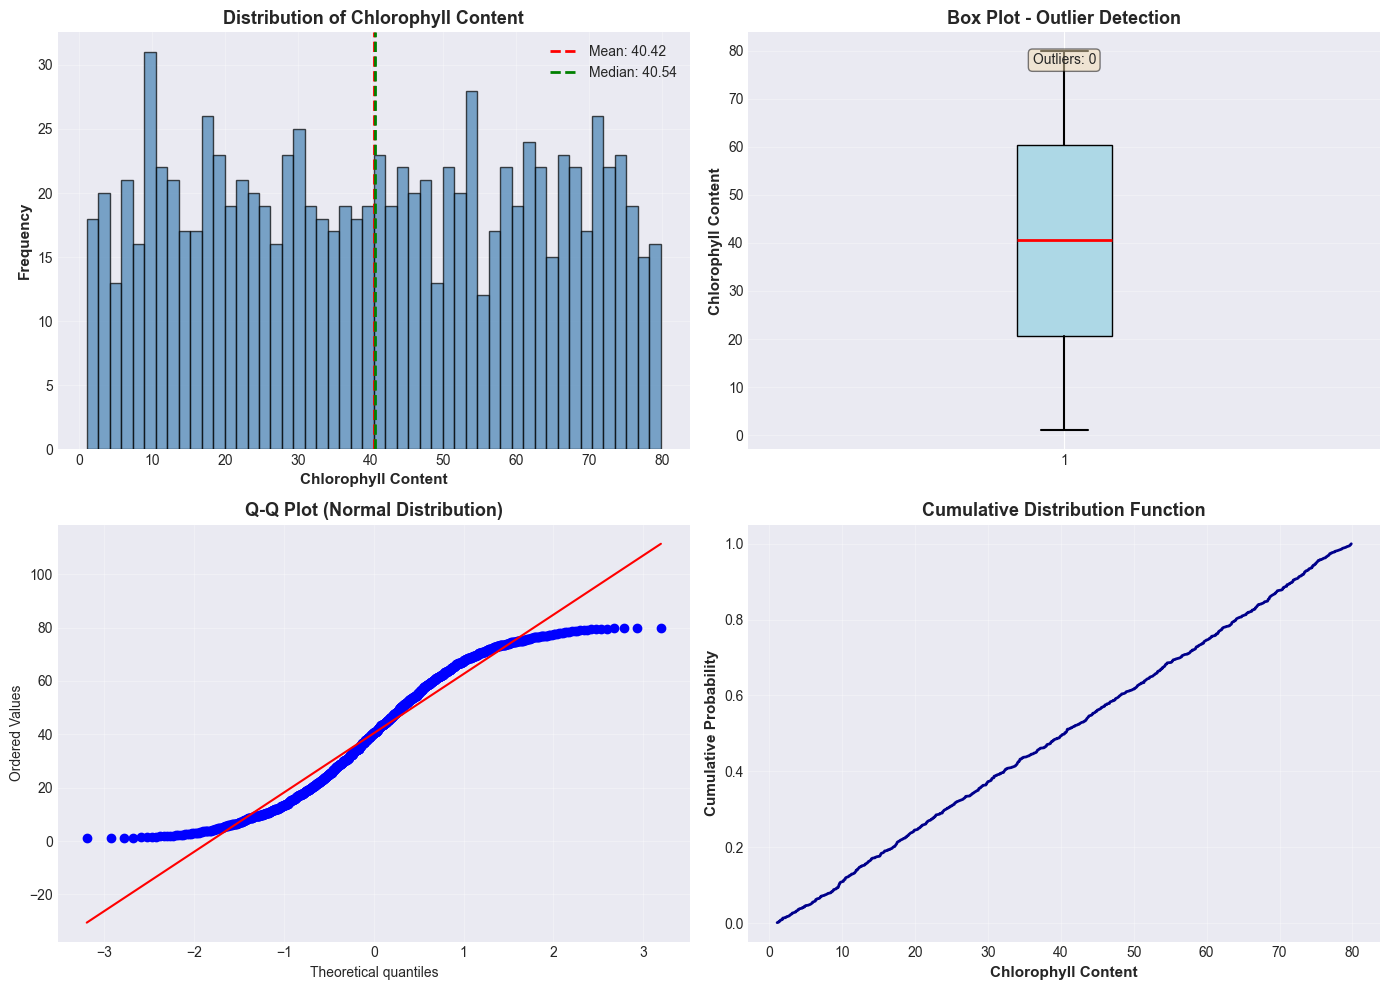


Outlier Analysis:
  Lower bound (Q1 - 1.5*IQR): -39.111404
  Upper bound (Q3 + 1.5*IQR): 120.092476
  Number of outliers: 0 (0.00%)

5. FEATURE DISTRIBUTION ANALYSIS


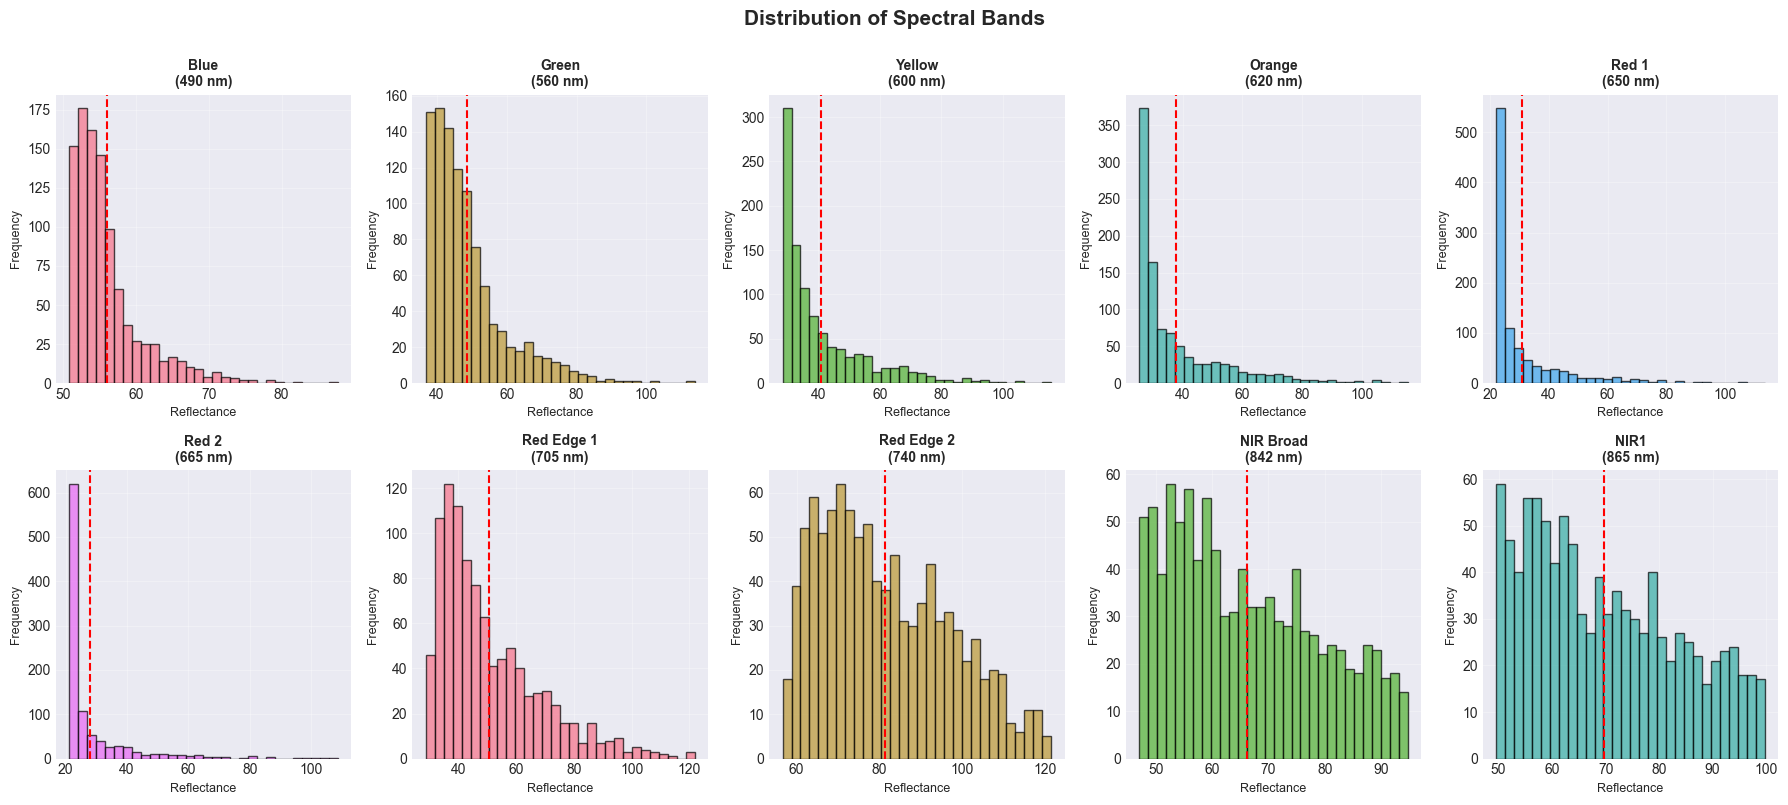


6. CORRELATION ANALYSIS

Feature Intercorrelation:

Highly Correlated Band Pairs :
----------------------------------------------------------------------
Band 1          Band 2          Correlation    
----------------------------------------------------------------------
Blue            Green           0.9759         
Blue            Yellow          0.8752         
Blue            Orange          0.8202         
Green           Yellow          0.8908         
Green           Orange          0.8283         
Green           Red Edge 1      0.8184         
Yellow          Orange          0.9911         
Yellow          Red 1           0.9585         
Yellow          Red 2           0.9278         
Yellow          Red Edge 1      0.9458         
Orange          Red 1           0.9857         
Orange          Red 2           0.9631         
Orange          Red Edge 1      0.9390         
Red 1           Red 2           0.9942         
Red 1           Red Edge 1      0.8884         
Red 2 

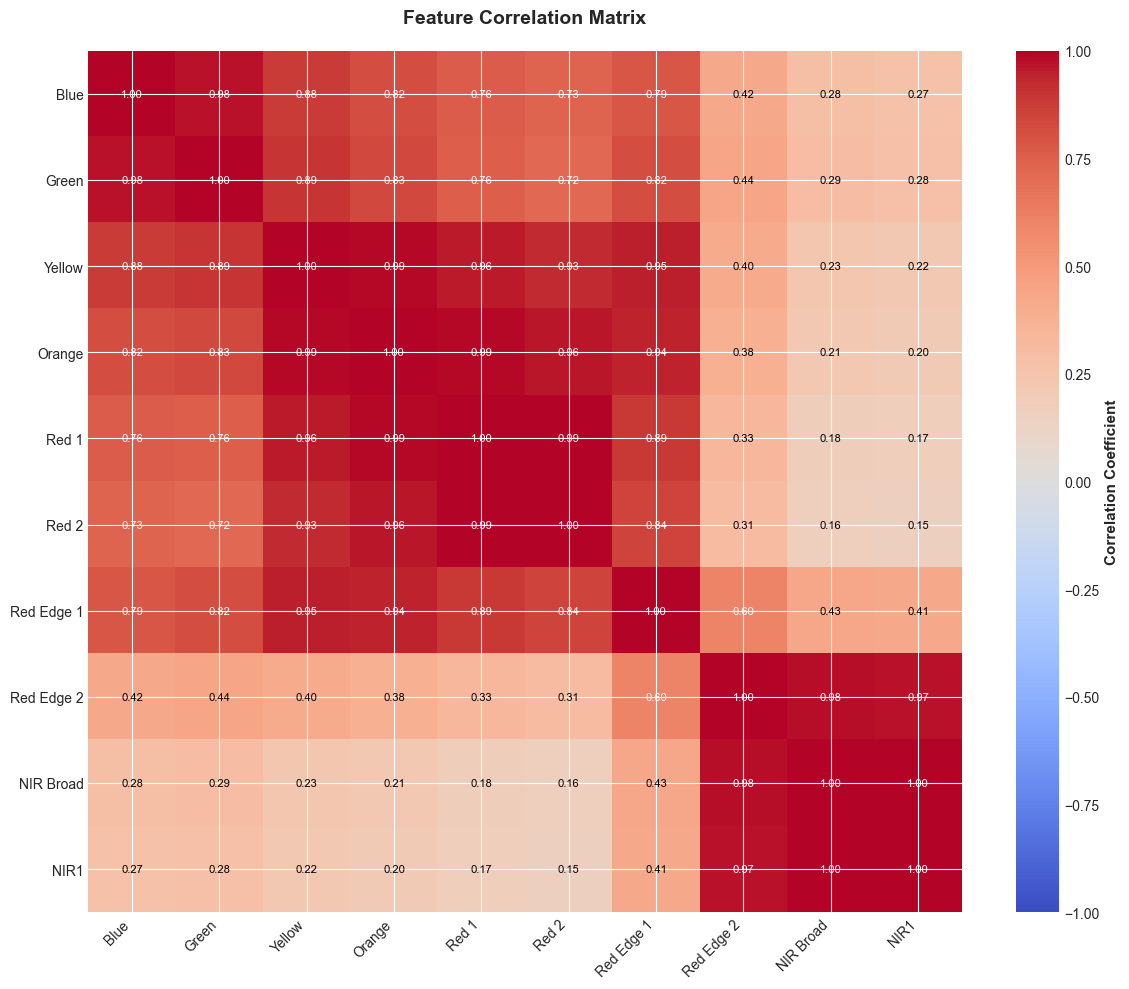


Correlation with Target (Chlorophyll Content):
----------------------------------------------------------------------
Band            Wavelength (nm)    Pearson r    p-value      Spearman ρ  
----------------------------------------------------------------------
Blue            490                -0.6873      0.000000     -0.7721     
Green           560                -0.7434      0.000000     -0.8396     
Yellow          600                -0.8430      0.000000     -0.9838     
Orange          620                -0.8212      0.000000     -0.9930     
Red 1           650                -0.7476      0.000000     -0.9969     
Red 2           665                -0.6912      0.000000     -0.9969     
Red Edge 1      705                -0.8643      0.000000     -0.9365     
Red Edge 2      740                -0.2625      0.000000     -0.2396     
NIR Broad       842                -0.0675      0.032717     -0.0611     
NIR1            865                -0.0528      0.095473     -0.0469  

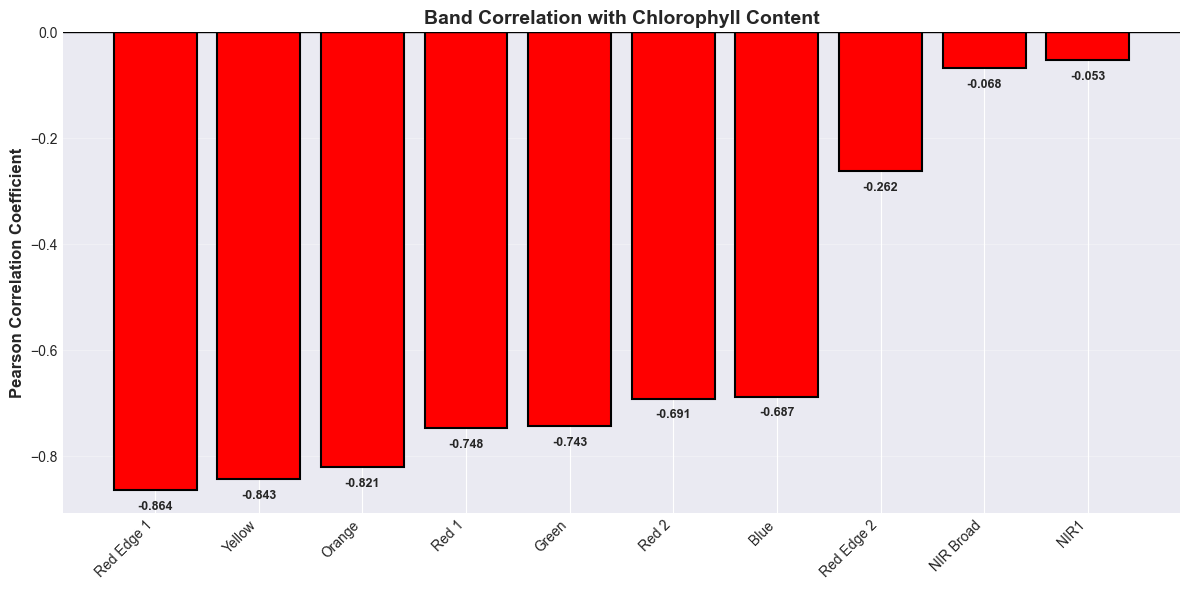

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy import stats
from scipy.stats import pearsonr, spearmanr
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*80)
print("EXPLORATORY DATA ANALYSIS")
print("Chlorophyll Content Prediction from Landsat Spectral Bands")
print("="*80)


# 1. LOAD DATASET

print("\n" + "="*80)
print("1. LOADING DATASET")
print("="*80)

# Load data
X = np.load('landis_chlorophyl_regression.npy')
y = np.load('landis_chlorophyl_regression_gt.npy')

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"Data type (X): {X.dtype}")
print(f"Data type (y): {y.dtype}")

n_samples, n_features = X.shape
print(f"\nNumber of samples: {n_samples}")
print(f"Number of spectral bands: {n_features}")

# Band information
band_info = {
    'Band Name': ['Blue', 'Green', 'Yellow', 'Orange', 'Red 1', 'Red 2', 
                  'Red Edge 1', 'Red Edge 2', 'NIR Broad', 'NIR1'],
    'Center Wavelength (nm)': [490, 560, 600, 620, 650, 665, 705, 740, 842, 865]
}
band_df = pd.DataFrame(band_info)
print("\nSpectral Band Information:")
print("-" * 60)
print(band_df.to_string(index=False))


# 2. BASIC STATISTICS

print("\n" + "="*80)
print("2. BASIC DATASET STATISTICS")
print("="*80)

print("\nFEATURES (Spectral Reflectance) Statistics:")
print("-" * 80)
print(f"{'Statistic':<15} {'Min':<12} {'Max':<12} {'Mean':<12} {'Std':<12} {'Median':<12}")
print("-" * 80)
print(f"{'Overall':<15} {X.min():<12.6f} {X.max():<12.6f} {X.mean():<12.6f} "
      f"{X.std():<12.6f} {np.median(X):<12.6f}")

print("\nPer-Band Statistics:")
print("-" * 80)
print(f"{'Band':<15} {'Min':<12} {'Max':<12} {'Mean':<12} {'Std':<12} {'Range':<12}")
print("-" * 80)
for i, band_name in enumerate(band_df['Band Name']):
    band_data = X[:, i]
    print(f"{band_name:<15} {band_data.min():<12.6f} {band_data.max():<12.6f} "
          f"{band_data.mean():<12.6f} {band_data.std():<12.6f} "
          f"{band_data.max()-band_data.min():<12.6f}")

print("\nTARGET (Chlorophyll Content) Statistics:")
print("-" * 80)
print(f"Min:        {y.min():.6f}")
print(f"Max:        {y.max():.6f}")
print(f"Mean:       {y.mean():.6f}")
print(f"Median:     {np.median(y):.6f}")
print(f"Std Dev:    {y.std():.6f}")
print(f"Range:      {y.max() - y.min():.6f}")
print(f"CV (Std/Mean): {(y.std()/y.mean())*100:.2f}%")

# Quartiles
q1, q2, q3 = np.percentile(y, [25, 50, 75])
print(f"\nQuartiles:")
print(f"  Q1 (25%):  {q1:.6f}")
print(f"  Q2 (50%):  {q2:.6f}")
print(f"  Q3 (75%):  {q3:.6f}")
print(f"  IQR:       {q3-q1:.6f}")


# 3. DATA QUALITY CHECKS

print("\n" + "="*80)
print("3. DATA QUALITY ASSESSMENT")
print("="*80)

# Check for missing values
nan_count_X = np.isnan(X).sum()
nan_count_y = np.isnan(y).sum()
inf_count_X = np.isinf(X).sum()
inf_count_y = np.isinf(y).sum()

print(f"\nMissing Values:")
print(f"  Features (X): {nan_count_X} NaN values, {inf_count_X} Inf values")
print(f"  Target (y):   {nan_count_y} NaN values, {inf_count_y} Inf values")

# Check for negative values
negative_count = (X < 0).sum()
print(f"\nNegative reflectance values: {negative_count} ({(negative_count/X.size)*100:.4f}%)")

# Check for values outside [0, 1] range 
outside_range = ((X < 0) | (X > 1)).sum()
print(f"Values outside [0, 1] range: {outside_range} ({(outside_range/X.size)*100:.4f}%)")

# Check for duplicates
unique_samples = len(np.unique(X, axis=0))
print(f"\nUnique samples: {unique_samples} out of {n_samples}")
if unique_samples < n_samples:
    print(f"  Warning: {n_samples - unique_samples} duplicate samples found!")
else:
    print(f"  No duplicate samples")

# Check for constant features
constant_features = []
for i in range(n_features):
    if X[:, i].std() < 1e-10:
        constant_features.append(i)

if constant_features:
    print(f"\nWarning: {len(constant_features)} constant/near-constant features: {constant_features}")
else:
    print(f"\n No constant features detected")

# Check data quality status
print("\nData Quality Status:")
if nan_count_X == 0 and nan_count_y == 0 and inf_count_X == 0 and inf_count_y == 0:
    print("   GOOD - No missing or infinite values")
else:
    print("  NEEDS ATTENTION - Contains missing or infinite values")


# 4. TARGET VARIABLE DISTRIBUTION

print("\n" + "="*80)
print("4. TARGET VARIABLE DISTRIBUTION ANALYSIS")
print("="*80)




# Visualize target distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram
axes[0, 0].hist(y, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].axvline(y.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {y.mean():.2f}')
axes[0, 0].axvline(np.median(y), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(y):.2f}')
axes[0, 0].set_xlabel('Chlorophyll Content', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Distribution of Chlorophyll Content', fontsize=13, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Box plot
bp = axes[0, 1].boxplot(y, vert=True, patch_artist=True, 
                        boxprops=dict(facecolor='lightblue', edgecolor='black'),
                        medianprops=dict(color='red', linewidth=2),
                        whiskerprops=dict(color='black', linewidth=1.5),
                        capprops=dict(color='black', linewidth=1.5))
axes[0, 1].set_ylabel('Chlorophyll Content', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Box Plot - Outlier Detection', fontsize=13, fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)

# Identify outliers
Q1 = np.percentile(y, 25)
Q3 = np.percentile(y, 75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = ((y < lower_bound) | (y > upper_bound)).sum()
axes[0, 1].text(0.5, 0.95, f'Outliers: {outliers}', 
                transform=axes[0, 1].transAxes, 
                ha='center', va='top', fontsize=10, 
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Q-Q plot
stats.probplot(y, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot (Normal Distribution)', fontsize=13, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# Cumulative distribution
sorted_y = np.sort(y)
cumulative = np.arange(1, len(sorted_y) + 1) / len(sorted_y)
axes[1, 1].plot(sorted_y, cumulative, linewidth=2, color='darkblue')
axes[1, 1].set_xlabel('Chlorophyll Content', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Cumulative Probability', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Cumulative Distribution Function', fontsize=13, fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nOutlier Analysis:")
print(f"  Lower bound (Q1 - 1.5*IQR): {lower_bound:.6f}")
print(f"  Upper bound (Q3 + 1.5*IQR): {upper_bound:.6f}")
print(f"  Number of outliers: {outliers} ({(outliers/len(y))*100:.2f}%)")


# 5. FEATURE DISTRIBUTIONS

print("\n" + "="*80)
print("5. FEATURE DISTRIBUTION ANALYSIS")
print("="*80)

# Plot all feature distributions
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.ravel()

for i, band_name in enumerate(band_df['Band Name']):
    axes[i].hist(X[:, i], bins=30, edgecolor='black', alpha=0.7, color=f'C{i}')
    axes[i].set_xlabel('Reflectance', fontsize=9)
    axes[i].set_ylabel('Frequency', fontsize=9)
    axes[i].set_title(f'{band_name}\n({band_df["Center Wavelength (nm)"][i]} nm)', 
                     fontsize=10, fontweight='bold')
    axes[i].grid(alpha=0.3)
    
    # Add statistics
    mean_val = X[:, i].mean()
    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=1.5)

plt.suptitle('Distribution of Spectral Bands', fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()




# 6. CORRELATION ANALYSIS

print("\n" + "="*80)
print("6. CORRELATION ANALYSIS")
print("="*80)

# Correlation between features
print("\nFeature Intercorrelation:")
corr_matrix = np.corrcoef(X.T)

# Find highly correlated pairs
high_corr_pairs = []
for i in range(n_features):
    for j in range(i+1, n_features):
        if abs(corr_matrix[i, j]) > 0.8:
            high_corr_pairs.append((band_df['Band Name'][i], 
                                   band_df['Band Name'][j], 
                                   corr_matrix[i, j]))

print(f"\nHighly Correlated Band Pairs :")
print("-" * 70)
if high_corr_pairs:
    print(f"{'Band 1':<15} {'Band 2':<15} {'Correlation':<15}")
    print("-" * 70)
    for band1, band2, corr in high_corr_pairs:
        print(f"{band1:<15} {band2:<15} {corr:<15.4f}")
else:
    print("No highly correlated pairs found")

# Correlation heatmap
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
ax.set_xticks(range(n_features))
ax.set_yticks(range(n_features))
ax.set_xticklabels(band_df['Band Name'], rotation=45, ha='right')
ax.set_yticklabels(band_df['Band Name'])
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=20)

# Add correlation values
for i in range(n_features):
    for j in range(n_features):
        text = ax.text(j, i, f'{corr_matrix[i, j]:.2f}',
                      ha="center", va="center", color="black" if abs(corr_matrix[i, j]) < 0.5 else "white",
                      fontsize=8)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Correlation Coefficient', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlation with target variable
print("\nCorrelation with Target (Chlorophyll Content):")
print("-" * 70)
print(f"{'Band':<15} {'Wavelength (nm)':<18} {'Pearson r':<12} {'p-value':<12} {'Spearman ρ':<12}")
print("-" * 70)

correlations = []
for i, band_name in enumerate(band_df['Band Name']):
    pearson_r, p_pearson = pearsonr(X[:, i], y)
    spearman_r, _ = spearmanr(X[:, i], y)
    correlations.append((band_name, band_df['Center Wavelength (nm)'][i], 
                        pearson_r, p_pearson, spearman_r))
    print(f"{band_name:<15} {band_df['Center Wavelength (nm)'][i]:<18} "
          f"{pearson_r:<12.4f} {p_pearson:<12.6f} {spearman_r:<12.4f}")

# Sort by absolute correlation
correlations.sort(key=lambda x: abs(x[2]), reverse=True)
print(f"\nMost Correlated Bands (by |Pearson r|):")
print("-" * 70)
for i in range(min(5, len(correlations))):
    band_name, wl, r, p, rho = correlations[i]
    print(f"{i+1}. {band_name} ({wl} nm): r = {r:.4f}")

# Visualize correlations with target
fig, ax = plt.subplots(figsize=(12, 6))
band_names_short = band_df['Band Name']
correlations_values = [c[2] for c in correlations]
colors = ['green' if c > 0 else 'red' for c in correlations_values]

bars = ax.bar(range(len(correlations)), 
              [c[2] for c in correlations], 
              color=colors, edgecolor='black', linewidth=1.5)
ax.set_xticks(range(len(correlations)))
ax.set_xticklabels([c[0] for c in correlations], rotation=45, ha='right')
ax.set_ylabel('Pearson Correlation Coefficient', fontsize=12, fontweight='bold')
ax.set_title('Band Correlation with Chlorophyll Content', fontsize=14, fontweight='bold')
ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax.grid(axis='y', alpha=0.3)

# Add value labels
for i, (bar, (_, _, r, _, _)) in enumerate(zip(bars, correlations)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + (0.02 if height > 0 else -0.02),
            f'{r:.3f}', ha='center', va='bottom' if height > 0 else 'top',
            fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()














Explanation:
Multicollinearity is evident in this dataset, particularly in the visible and red-edge spectral regions.   
1. The most concerning trend is the nearly identical Spearman ρ values for Yellow (600 nm), Orange (620 nm), Red 1 (650 nm), and Red 2 (665 nm), all of which display ρ = -0.99.  These are near-perfect monotonic relationships with exceptionally high Spearman correlations.   Given that these four bands' interactions with chlorophyll content are almost entirely monotone, it is likely that they carry a significant amount of redundant information.   Many predictors are almost perfectly associated with the target in the same way, which is likely to lead to multicollinearity, which can inflate variation in regression coefficients and make it difficult to extract individual band contributions.
2. Physical Description: Chlorophyll Absorption Characteristic:  The area where more chlorophyll leads to greater absorption and less reflection is where all of the bands between 600 and 665 nm are found.   Since they detect the same biophysical phenomenon (chlorophyll, an absorption peak at 660 nm) with slightly different sensitivities, these bands are inherently collinear.   The two red-edge bands (705 nm and 740 nm) also capture the transition zone between chlorophyll absorption and NIR scattering, though the connection at 740 nm is much weaker.

The distribution of chlorophyll content shows excellent balance for regression modeling, indicating a symmetric, non-skewed distribution with no concentration in any one area. The mean (40.42 µg/cm²) and median (40.54 µg/cm²) are nearly identical and centered in the range (1.05-79.85 µg/cm²).   The model will have comparable training representation across low, medium, and high chlorophyll levels according to the coefficient of variation (56%) which confirms significant variability over the entire physiological range from chlorotic vegetation (~1 µg/cm²) to healthy, productive canopy (~80 µg/cm²).

2.b

LINEAR REGRESSION FOR CHLOROPHYLL PREDICTION

1. LOADING DATA
Features shape: (1000, 10)
Target shape: (1000,)
Number of samples: 1000
Number of features: 10

2. DATA PREPROCESSING

Preprocessing Steps:
----------------------------------------------------------------------

1. Checking for missing values...
   Missing values in X: 0
   Missing values in y: 0
  No missing values detected

2. Checking for outliers in features...
   Blue: 81 outliers (8.10%)
   Green: 71 outliers (7.10%)
   Yellow: 56 outliers (5.60%)
   Orange: 76 outliers (7.60%)
   Red 1: 108 outliers (10.80%)
   Red 2: 135 outliers (13.50%)
   Red Edge 1: 30 outliers (3.00%)
   Total feature outliers: 557 (5.57%)

3. Checking for outliers in target variable...
   Target outliers: 0 (0.00%)

3. TRAIN-TEST SPLIT

Split Ratio Considerations:
----------------------------------------------------------------------

Split Results (Test Size = 0.2):
----------------------------------------------------------------------
Traini

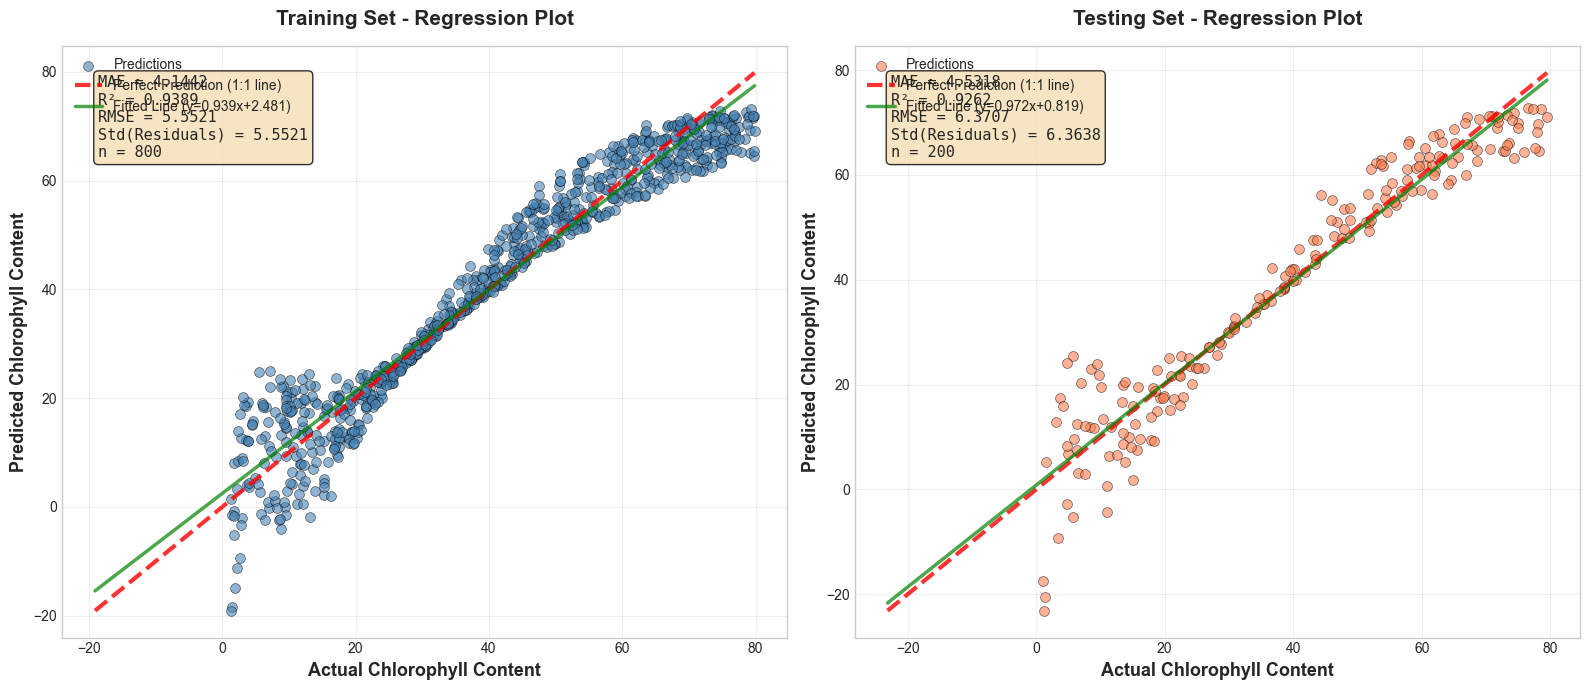

 Regression plots generated

9. GENERATING RESIDUAL PLOTS


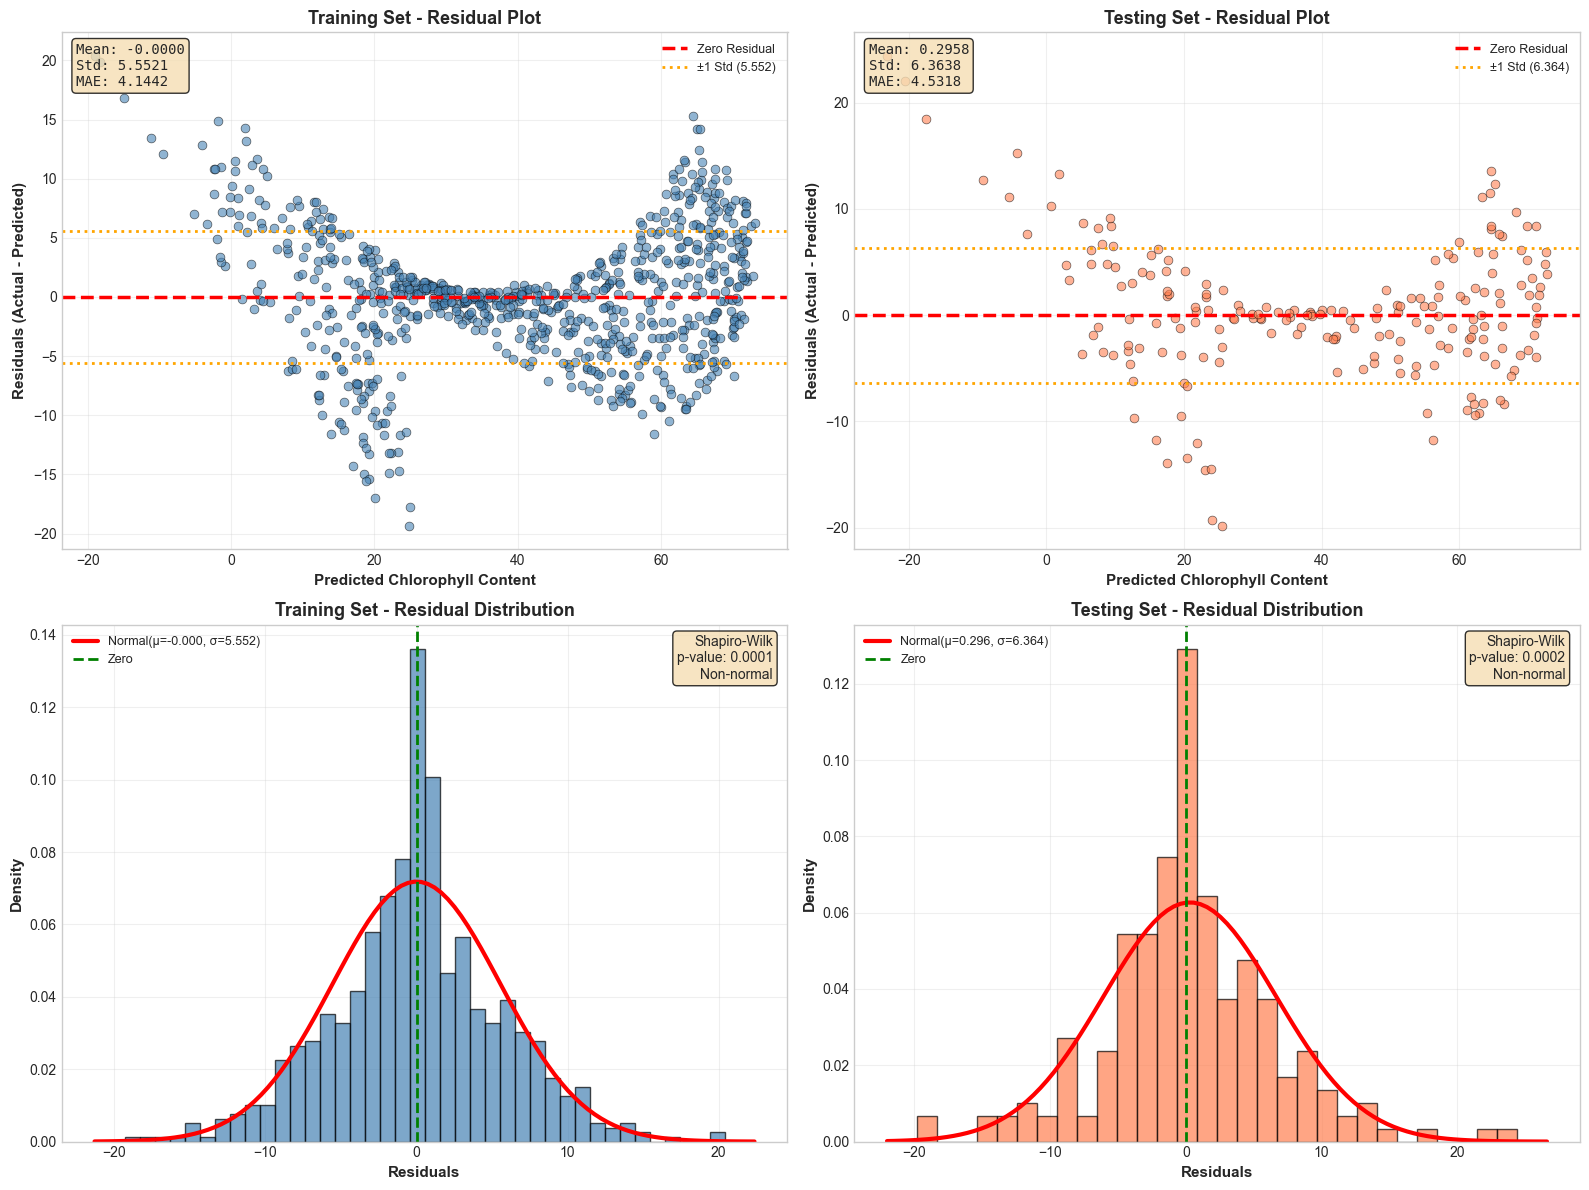

 Residual plots generated

10. Q-Q PLOTS (NORMALITY CHECK)


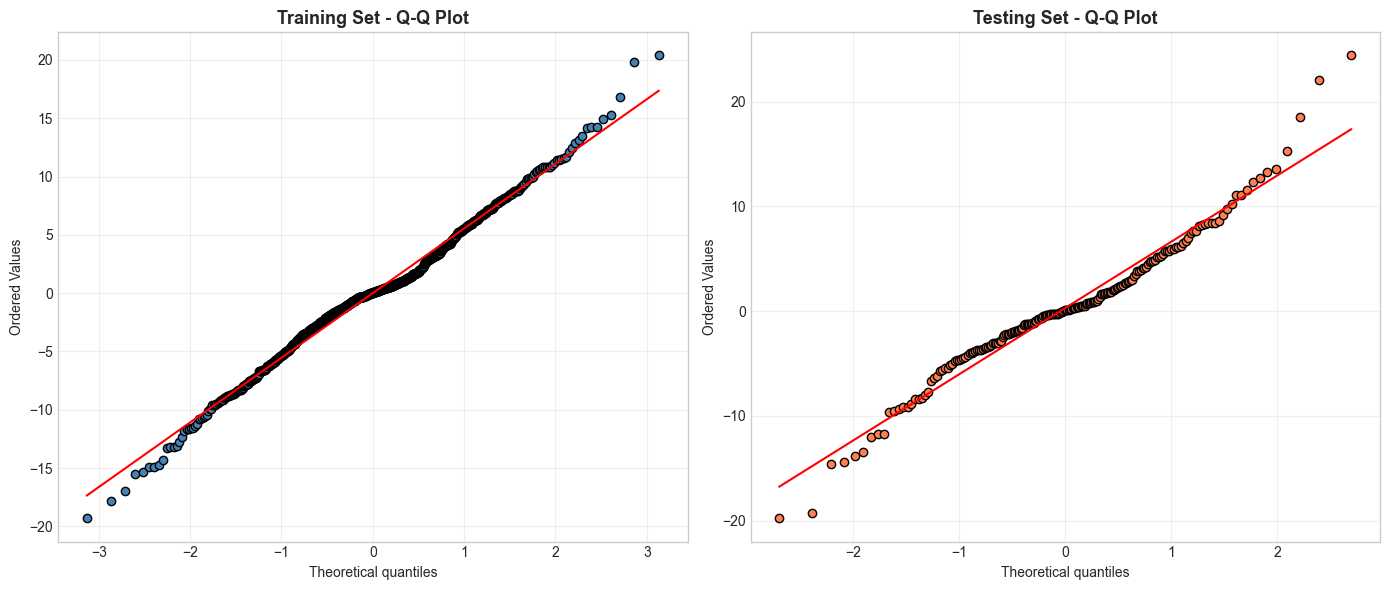

 Q-Q plots generated

ALL ANALYSIS COMPLETE


In [23]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("="*80)
print("LINEAR REGRESSION FOR CHLOROPHYLL PREDICTION")
print("="*80)


# 1. LOAD DATA

print("\n" + "="*80)
print("1. LOADING DATA")
print("="*80)

X = np.load('landis_chlorophyl_regression.npy')
y = np.load('landis_chlorophyl_regression_gt.npy')

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")

# Band names for reference
band_names = ['Blue', 'Green', 'Yellow', 'Orange', 'Red 1', 'Red 2', 
              'Red Edge 1', 'Red Edge 2', 'NIR Broad', 'NIR1']


# 2. DATA PREPROCESSING

print("\n" + "="*80)
print("2. DATA PREPROCESSING")
print("="*80)

print("\nPreprocessing Steps:")
print("-" * 70)

# Check for missing values
print("\n1. Checking for missing values...")
nan_X = np.isnan(X).sum()
nan_y = np.isnan(y).sum()
print(f"   Missing values in X: {nan_X}")
print(f"   Missing values in y: {nan_y}")

if nan_X == 0 and nan_y == 0:
    print("  No missing values detected")
else:
    print("  Missing values found - would need imputation")

# Check for outliers in features
print("\n2. Checking for outliers in features...")
outlier_counts = []
for i, band in enumerate(band_names):
    Q1 = np.percentile(X[:, i], 25)
    Q3 = np.percentile(X[:, i], 75)
    IQR = Q3 - Q1
    outliers = ((X[:, i] < Q1 - 1.5*IQR) | (X[:, i] > Q3 + 1.5*IQR)).sum()
    outlier_counts.append(outliers)
    if outliers > 0:
        print(f"   {band}: {outliers} outliers ({outliers/len(X)*100:.2f}%)")

total_outliers = sum(outlier_counts)
if total_outliers > 0:
    print(f"   Total feature outliers: {total_outliers} ({total_outliers/X.size*100:.2f}%)")
else:
    print("    No feature outliers detected")

# Check for outliers in target
print("\n3. Checking for outliers in target variable...")
Q1_y = np.percentile(y, 25)
Q3_y = np.percentile(y, 75)
IQR_y = Q3_y - Q1_y
y_outliers = ((y < Q1_y - 1.5*IQR_y) | (y > Q3_y + 1.5*IQR_y)).sum()
print(f"   Target outliers: {y_outliers} ({y_outliers/len(y)*100:.2f}%)")

# Feature scaling will be applied after train-test split


# 3. TRAIN-TEST SPLIT

print("\n" + "="*80)
print("3. TRAIN-TEST SPLIT")
print("="*80)

print("\nSplit Ratio Considerations:")
print("-" * 70)


# Perform split
test_size = 0.20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_size, random_state=42
)

print(f"\nSplit Results (Test Size = {test_size}):")
print("-" * 70)
print(f"Training set: {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"Testing set:  {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")
print(f"Samples per feature (training): {len(X_train)/X.shape[1]:.1f}")

# Verify split preserves distribution
print(f"\nTarget Distribution Verification:")
print(f"  Original - Mean: {y.mean():.4f}, Std: {y.std():.4f}")
print(f"  Training - Mean: {y_train.mean():.4f}, Std: {y_train.std():.4f}")
print(f"  Testing  - Mean: {y_test.mean():.4f}, Std: {y_test.std():.4f}")


# 4. FEATURE SCALING

print("\n" + "="*80)
print("4. FEATURE SCALING")
print("="*80)

# Standardize features 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Applied StandardScaler:")
print(f"  Formula: z = (x - μ) / σ")
print(f"\nTraining Set After Scaling:")
print(f"  Mean: {X_train_scaled.mean():.6f}")
print(f"  Std:  {X_train_scaled.std():.6f}")
print(f"\nTesting Set After Scaling:")
print(f"  Mean: {X_test_scaled.mean():.6f}")
print(f"  Std:  {X_test_scaled.std():.6f}")




# 5. TRAIN LINEAR REGRESSION MODEL

print("\n" + "="*80)
print("5. TRAINING LINEAR REGRESSION MODEL")
print("="*80)

# Initialize and train model
lr_model = LinearRegression()
print("Training Linear Regression model...")
lr_model.fit(X_train_scaled, y_train)
print(" Training complete!")

# Model parameters
print(f"\nModel Parameters:")
print(f"  Intercept: {lr_model.intercept_:.6f}")
print(f"  Number of coefficients: {len(lr_model.coef_)}")

print(f"\nCoefficients by Band:")
print("-" * 70)
print(f"{'Band':<15} {'Coefficient':<15} {'Interpretation':<30}")
print("-" * 70)
for band_name, coef in zip(band_names, lr_model.coef_):
    direction = "+" if coef > 0 else "-"
    interp = "Increases Chl" if coef > 0 else "Decreases Chl"
    print(f"{band_name:<15} {coef:>14.6f} {interp:<30}")


# 6. MAKE PREDICTIONS

print("\n" + "="*80)
print("6. GENERATING PREDICTIONS")
print("="*80)

# Predictions
y_train_pred = lr_model.predict(X_train_scaled)
y_test_pred = lr_model.predict(X_test_scaled)

print(f"Training predictions: {len(y_train_pred)} values")
print(f"Testing predictions:  {len(y_test_pred)} values")


# 7. CALCULATE PERFORMANCE METRICS

print("\n" + "="*80)
print("7. PERFORMANCE METRICS")
print("="*80)

# Training metrics
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)
train_residuals = y_train - y_train_pred
train_std_residuals = np.std(train_residuals)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))

# Testing metrics
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)
test_residuals = y_test - y_test_pred
test_std_residuals = np.std(test_residuals)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("\nTRAINING SET METRICS:")
print("-" * 70)
print(f"  Mean Absolute Error (MAE):        {train_mae:.6f}")
print(f"  Root Mean Squared Error (RMSE):   {train_rmse:.6f}")
print(f"  R-squared (R²):                   {train_r2:.6f}")
print(f"  Standard Deviation of Residuals:  {train_std_residuals:.6f}")

print("\nTESTING SET METRICS:")
print("-" * 70)
print(f"  Mean Absolute Error (MAE):        {test_mae:.6f}")
print(f"  Root Mean Squared Error (RMSE):   {test_rmse:.6f}")
print(f"  R-squared (R²):                   {test_r2:.6f}")
print(f"  Standard Deviation of Residuals:  {test_std_residuals:.6f}")

print("\nMETRIC INTERPRETATIONS:")
print("-" * 70)


# Additional metrics
print("\nADDITIONAL STATISTICS:")
print("-" * 70)
print(f"Training Set:")
print(f"  Mean of residuals: {np.mean(train_residuals):.6f} (should be ≈0)")
print(f"  Min residual: {np.min(train_residuals):.6f}")
print(f"  Max residual: {np.max(train_residuals):.6f}")
print(f"  Residuals within ±1 std: {np.sum(np.abs(train_residuals) <= train_std_residuals)/len(train_residuals)*100:.1f}%")

print(f"\nTesting Set:")
print(f"  Mean of residuals: {np.mean(test_residuals):.6f} (should be ≈0)")
print(f"  Min residual: {np.min(test_residuals):.6f}")
print(f"  Max residual: {np.max(test_residuals):.6f}")
print(f"  Residuals within ±1 std: {np.sum(np.abs(test_residuals) <= test_std_residuals)/len(test_residuals)*100:.1f}%")


# 8. REGRESSION PLOTS

print("\n" + "="*80)
print("8. GENERATING REGRESSION PLOTS")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Training Set Regression Plot ---
ax = axes[0]

# Scatter plot
ax.scatter(y_train, y_train_pred, alpha=0.6, s=50, color='steelblue', 
           edgecolors='black', linewidth=0.5, label='Predictions')

# Perfect prediction line (one-to-one line)
min_val = min(y_train.min(), y_train_pred.min())
max_val = max(y_train.max(), y_train_pred.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=3, 
        label='Perfect Prediction (1:1 line)', alpha=0.8)

# Add regression line
z = np.polyfit(y_train, y_train_pred, 1)
p = np.poly1d(z)
x_line = np.linspace(min_val, max_val, 100)
ax.plot(x_line, p(x_line), 'g-', linewidth=2.5, alpha=0.7, 
        label=f'Fitted Line (y={z[0]:.3f}x+{z[1]:.3f})')

ax.set_xlabel('Actual Chlorophyll Content', fontsize=13, fontweight='bold')
ax.set_ylabel('Predicted Chlorophyll Content', fontsize=13, fontweight='bold')
ax.set_title('Training Set - Regression Plot', fontsize=15, fontweight='bold', pad=15)
ax.legend(loc='upper left', fontsize=10)
ax.grid(alpha=0.3)

# Add metrics text box
textstr = f'MAE = {train_mae:.4f}\nR² = {train_r2:.4f}\nRMSE = {train_rmse:.4f}\nStd(Residuals) = {train_std_residuals:.4f}\nn = {len(y_train)}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=props, family='monospace')

# --- Testing Set Regression Plot ---
ax = axes[1]

# Scatter plot
ax.scatter(y_test, y_test_pred, alpha=0.6, s=50, color='coral', 
           edgecolors='black', linewidth=0.5, label='Predictions')

# Perfect prediction line
min_val_test = min(y_test.min(), y_test_pred.min())
max_val_test = max(y_test.max(), y_test_pred.max())
ax.plot([min_val_test, max_val_test], [min_val_test, max_val_test], 'r--', 
        linewidth=3, label='Perfect Prediction (1:1 line)', alpha=0.8)

# Add regression line
z_test = np.polyfit(y_test, y_test_pred, 1)
p_test = np.poly1d(z_test)
x_line_test = np.linspace(min_val_test, max_val_test, 100)
ax.plot(x_line_test, p_test(x_line_test), 'g-', linewidth=2.5, alpha=0.7,
        label=f'Fitted Line (y={z_test[0]:.3f}x+{z_test[1]:.3f})')

ax.set_xlabel('Actual Chlorophyll Content', fontsize=13, fontweight='bold')
ax.set_ylabel('Predicted Chlorophyll Content', fontsize=13, fontweight='bold')
ax.set_title('Testing Set - Regression Plot', fontsize=15, fontweight='bold', pad=15)
ax.legend(loc='upper left', fontsize=10)
ax.grid(alpha=0.3)

# Add metrics text box
textstr_test = f'MAE = {test_mae:.4f}\nR² = {test_r2:.4f}\nRMSE = {test_rmse:.4f}\nStd(Residuals) = {test_std_residuals:.4f}\nn = {len(y_test)}'
ax.text(0.05, 0.95, textstr_test, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=props, family='monospace')

plt.tight_layout()
plt.show()

print(" Regression plots generated")


# 9. RESIDUAL PLOTS

print("\n" + "="*80)
print("9. GENERATING RESIDUAL PLOTS")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- Training Set: Residuals vs Predicted ---
ax = axes[0, 0]
ax.scatter(y_train_pred, train_residuals, alpha=0.6, s=40, color='steelblue',
           edgecolors='black', linewidth=0.5)
ax.axhline(y=0, color='red', linestyle='--', linewidth=2.5, label='Zero Residual')
ax.axhline(y=train_std_residuals, color='orange', linestyle=':', linewidth=2, 
           label=f'±1 Std ({train_std_residuals:.3f})')
ax.axhline(y=-train_std_residuals, color='orange', linestyle=':', linewidth=2)
ax.set_xlabel('Predicted Chlorophyll Content', fontsize=11, fontweight='bold')
ax.set_ylabel('Residuals (Actual - Predicted)', fontsize=11, fontweight='bold')
ax.set_title('Training Set - Residual Plot', fontsize=13, fontweight='bold')
ax.legend(loc='best', fontsize=9)
ax.grid(alpha=0.3)

# Add metrics
textstr = f'Mean: {np.mean(train_residuals):.4f}\nStd: {train_std_residuals:.4f}\nMAE: {train_mae:.4f}'
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props, family='monospace')

# --- Testing Set: Residuals vs Predicted ---
ax = axes[0, 1]
ax.scatter(y_test_pred, test_residuals, alpha=0.6, s=40, color='coral',
           edgecolors='black', linewidth=0.5)
ax.axhline(y=0, color='red', linestyle='--', linewidth=2.5, label='Zero Residual')
ax.axhline(y=test_std_residuals, color='orange', linestyle=':', linewidth=2,
           label=f'±1 Std ({test_std_residuals:.3f})')
ax.axhline(y=-test_std_residuals, color='orange', linestyle=':', linewidth=2)
ax.set_xlabel('Predicted Chlorophyll Content', fontsize=11, fontweight='bold')
ax.set_ylabel('Residuals (Actual - Predicted)', fontsize=11, fontweight='bold')
ax.set_title('Testing Set - Residual Plot', fontsize=13, fontweight='bold')
ax.legend(loc='best', fontsize=9)
ax.grid(alpha=0.3)

# Add metrics
textstr = f'Mean: {np.mean(test_residuals):.4f}\nStd: {test_std_residuals:.4f}\nMAE: {test_mae:.4f}'
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props, family='monospace')

# --- Training Set: Residual Distribution ---
ax = axes[1, 0]
ax.hist(train_residuals, bins=40, edgecolor='black', alpha=0.7, color='steelblue',
        density=True)
# Overlay normal distribution
mu, std = np.mean(train_residuals), np.std(train_residuals)
xmin, xmax = ax.get_xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)
ax.plot(x, p, 'r-', linewidth=3, label=f'Normal(μ={mu:.3f}, σ={std:.3f})')
ax.axvline(x=0, color='green', linestyle='--', linewidth=2, label='Zero')
ax.set_xlabel('Residuals', fontsize=11, fontweight='bold')
ax.set_ylabel('Density', fontsize=11, fontweight='bold')
ax.set_title('Training Set - Residual Distribution', fontsize=13, fontweight='bold')
ax.legend(loc='best', fontsize=9)
ax.grid(alpha=0.3)

# Test normality
_, p_value = stats.shapiro(train_residuals[:min(5000, len(train_residuals))])
textstr = f'Shapiro-Wilk\np-value: {p_value:.4f}\n{"Normal" if p_value > 0.05 else "Non-normal"}'
ax.text(0.98, 0.98, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', horizontalalignment='right', bbox=props)

# --- Testing Set: Residual Distribution ---
ax = axes[1, 1]
ax.hist(test_residuals, bins=30, edgecolor='black', alpha=0.7, color='coral',
        density=True)
# Overlay normal distribution
mu_test, std_test = np.mean(test_residuals), np.std(test_residuals)
xmin, xmax = ax.get_xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu_test, std_test)
ax.plot(x, p, 'r-', linewidth=3, label=f'Normal(μ={mu_test:.3f}, σ={std_test:.3f})')
ax.axvline(x=0, color='green', linestyle='--', linewidth=2, label='Zero')
ax.set_xlabel('Residuals', fontsize=11, fontweight='bold')
ax.set_ylabel('Density', fontsize=11, fontweight='bold')
ax.set_title('Testing Set - Residual Distribution', fontsize=13, fontweight='bold')
ax.legend(loc='best', fontsize=9)
ax.grid(alpha=0.3)

# Test normality
_, p_value_test = stats.shapiro(test_residuals)
textstr = f'Shapiro-Wilk\np-value: {p_value_test:.4f}\n{"Normal" if p_value_test > 0.05 else "Non-normal"}'
ax.text(0.98, 0.98, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', horizontalalignment='right', bbox=props)

plt.tight_layout()
plt.show()

print(" Residual plots generated")


# 10. Q-Q PLOTS FOR RESIDUALS

print("\n" + "="*80)
print("10. Q-Q PLOTS (NORMALITY CHECK)")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Training Q-Q plot
stats.probplot(train_residuals, dist="norm", plot=axes[0])
axes[0].set_title('Training Set - Q-Q Plot', fontsize=13, fontweight='bold')
axes[0].grid(alpha=0.3)
axes[0].get_lines()[0].set_markerfacecolor('steelblue')
axes[0].get_lines()[0].set_markeredgecolor('black')
axes[0].get_lines()[0].set_markersize(6)

# Testing Q-Q plot
stats.probplot(test_residuals, dist="norm", plot=axes[1])
axes[1].set_title('Testing Set - Q-Q Plot', fontsize=13, fontweight='bold')
axes[1].grid(alpha=0.3)
axes[1].get_lines()[0].set_markerfacecolor('coral')
axes[1].get_lines()[0].set_markeredgecolor('black')
axes[1].get_lines()[0].set_markersize(6)

plt.tight_layout()
plt.show()

print(" Q-Q plots generated")








print("\n" + "="*80)
print("ALL ANALYSIS COMPLETE")
print("="*80)

Explanation:
The residual plots, which consistently display heteroscedasticity and prediction bias, indicate the model limits.   The most prominent pattern in the training set residuals is the obvious "bowtie" or funnel shape, where the error magnitude sharply rises at the extremes of the predicted chlorophyll content.  The residuals are tightly clustered near zero for mid-range predictions (20–50 µg/cm²), but they fan outward with errors up to ±20 µg/cm² at low (<20) and high (>60) chlorophyll values.   This suggests that spectral-chlorophyll connections can become non-linear at distribution tails, where the linear model breaks down.  This might be due to saturation effects in the red absorption bands at high chlorophyll levels or noise dominance at low chlorophyll levels.

2.c

PARTIAL LEAST SQUARES REGRESSION (PLSR)
Chlorophyll Prediction from Spectral Bands

1. DATA LOADING AND PREPROCESSING
Dataset shape: (1000, 10)
Target shape: (1000,)

Training set: 800 samples
Testing set: 200 samples

 Data preprocessed and scaled

2. PARTIAL LEAST SQUARES REGRESSION (PLSR) OVERVIEW

3. TRAINING PLSR WITH VARYING NUMBER OF COMPONENTS

Training PLSR models with 1 to 10 components...
--------------------------------------------------------------------------------
Components   Train R²     Train MAE    Train RMSE  
--------------------------------------------------------------------------------
1            0.656055     10.952260    13.170275   
2            0.712363     10.018000    12.044045   
3            0.909099     5.338058     6.770713    
4            0.911397     5.342547     6.684602    
5            0.917906     5.078050     6.434369    
6            0.919410     4.992158     6.375152    
7            0.929096     4.526332     5.979780    
8            0.9383

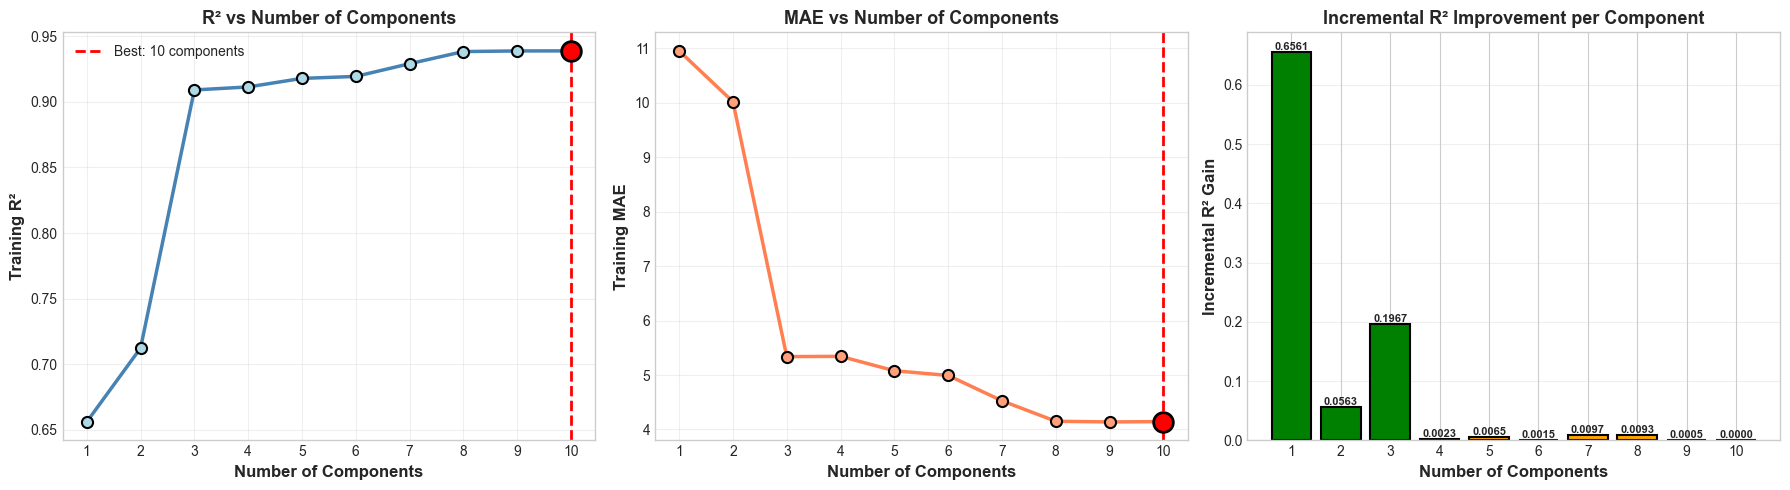

 Component selection plots generated

6. TRAINING BEST PLSR MODEL

PLSR Model with 10 Components:
----------------------------------------------------------------------

TRAINING SET:
  MAE:  4.144190
  RMSE: 5.552134
  R²:   0.938875
  Std(Residuals): 5.552134

TESTING SET:
  MAE:  4.531809
  RMSE: 6.370706
  R²:   0.926212
  Std(Residuals): 6.363833

Generalization:
  R² difference: 0.012663
   Excellent generalization

7. COMPARISON WITH LINEAR REGRESSION

Performance Comparison:
Metric                    Linear Regression    PLSR                
Training R²               0.938875             0.938875            
Testing R²                0.926212             0.926212            
Training MAE              4.144190             4.144190            
Testing MAE               4.531809             4.531809            
Generalization Gap        0.012663             0.012663            
Number of Parameters      10                   10                  

Performance Analysis:
 Linear Regre

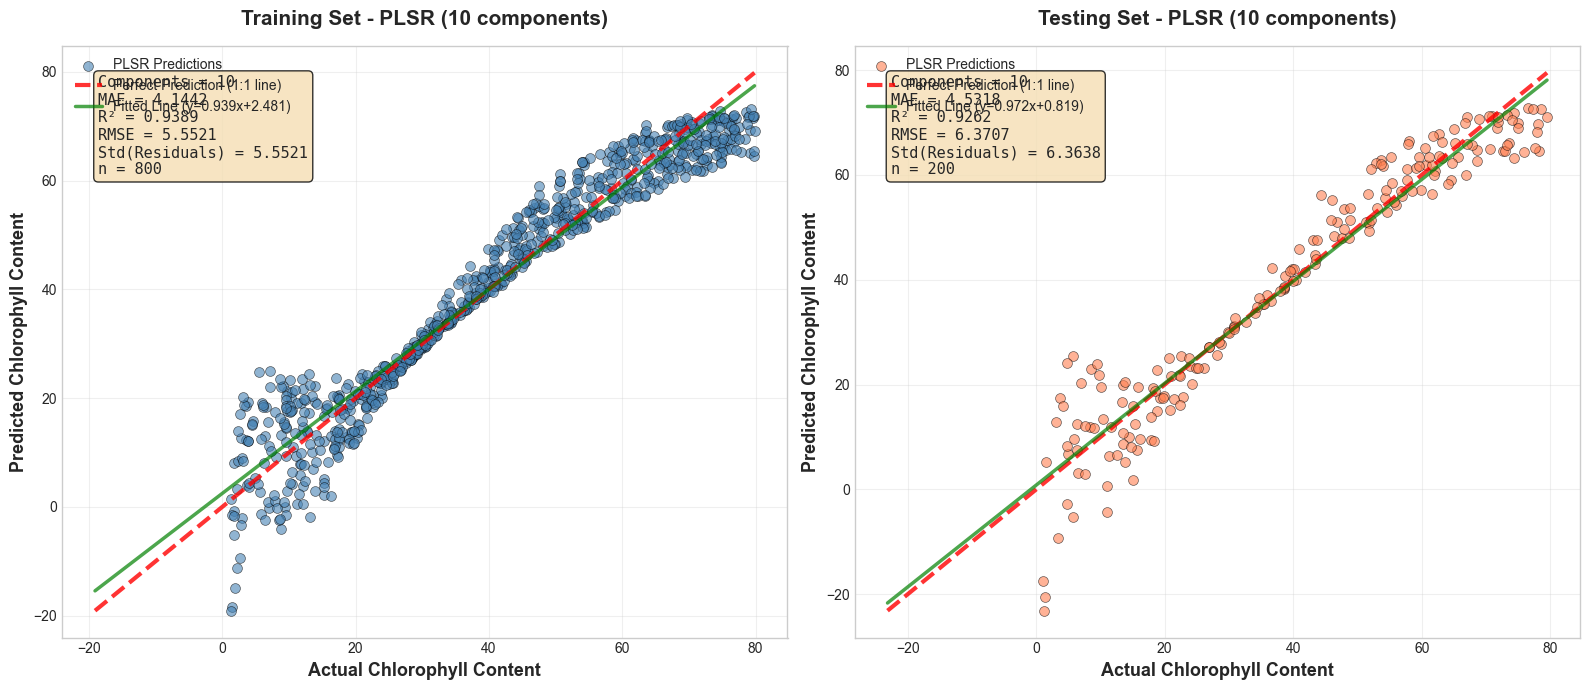

 PLSR regression plots generated

9. GENERATING RESIDUAL PLOTS (PLSR)


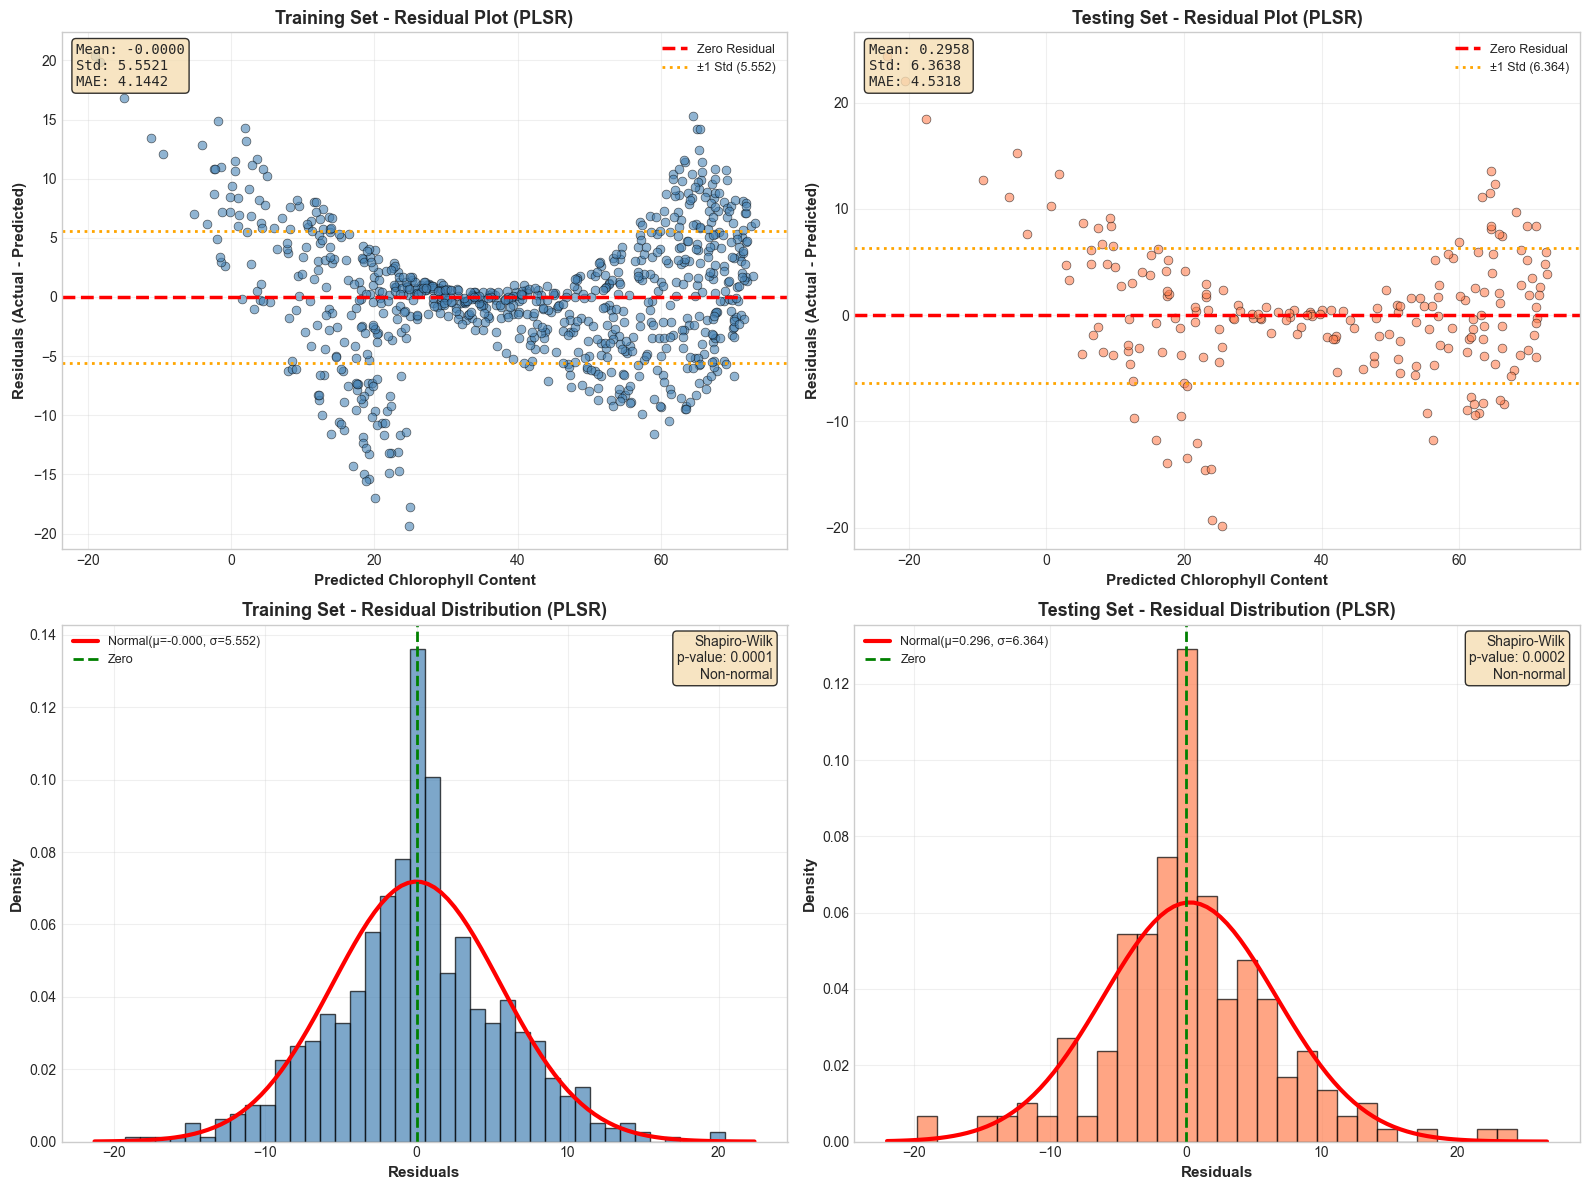

 PLSR residual plots generated

10. SIDE-BY-SIDE COMPARISON: LINEAR REGRESSION vs PLSR


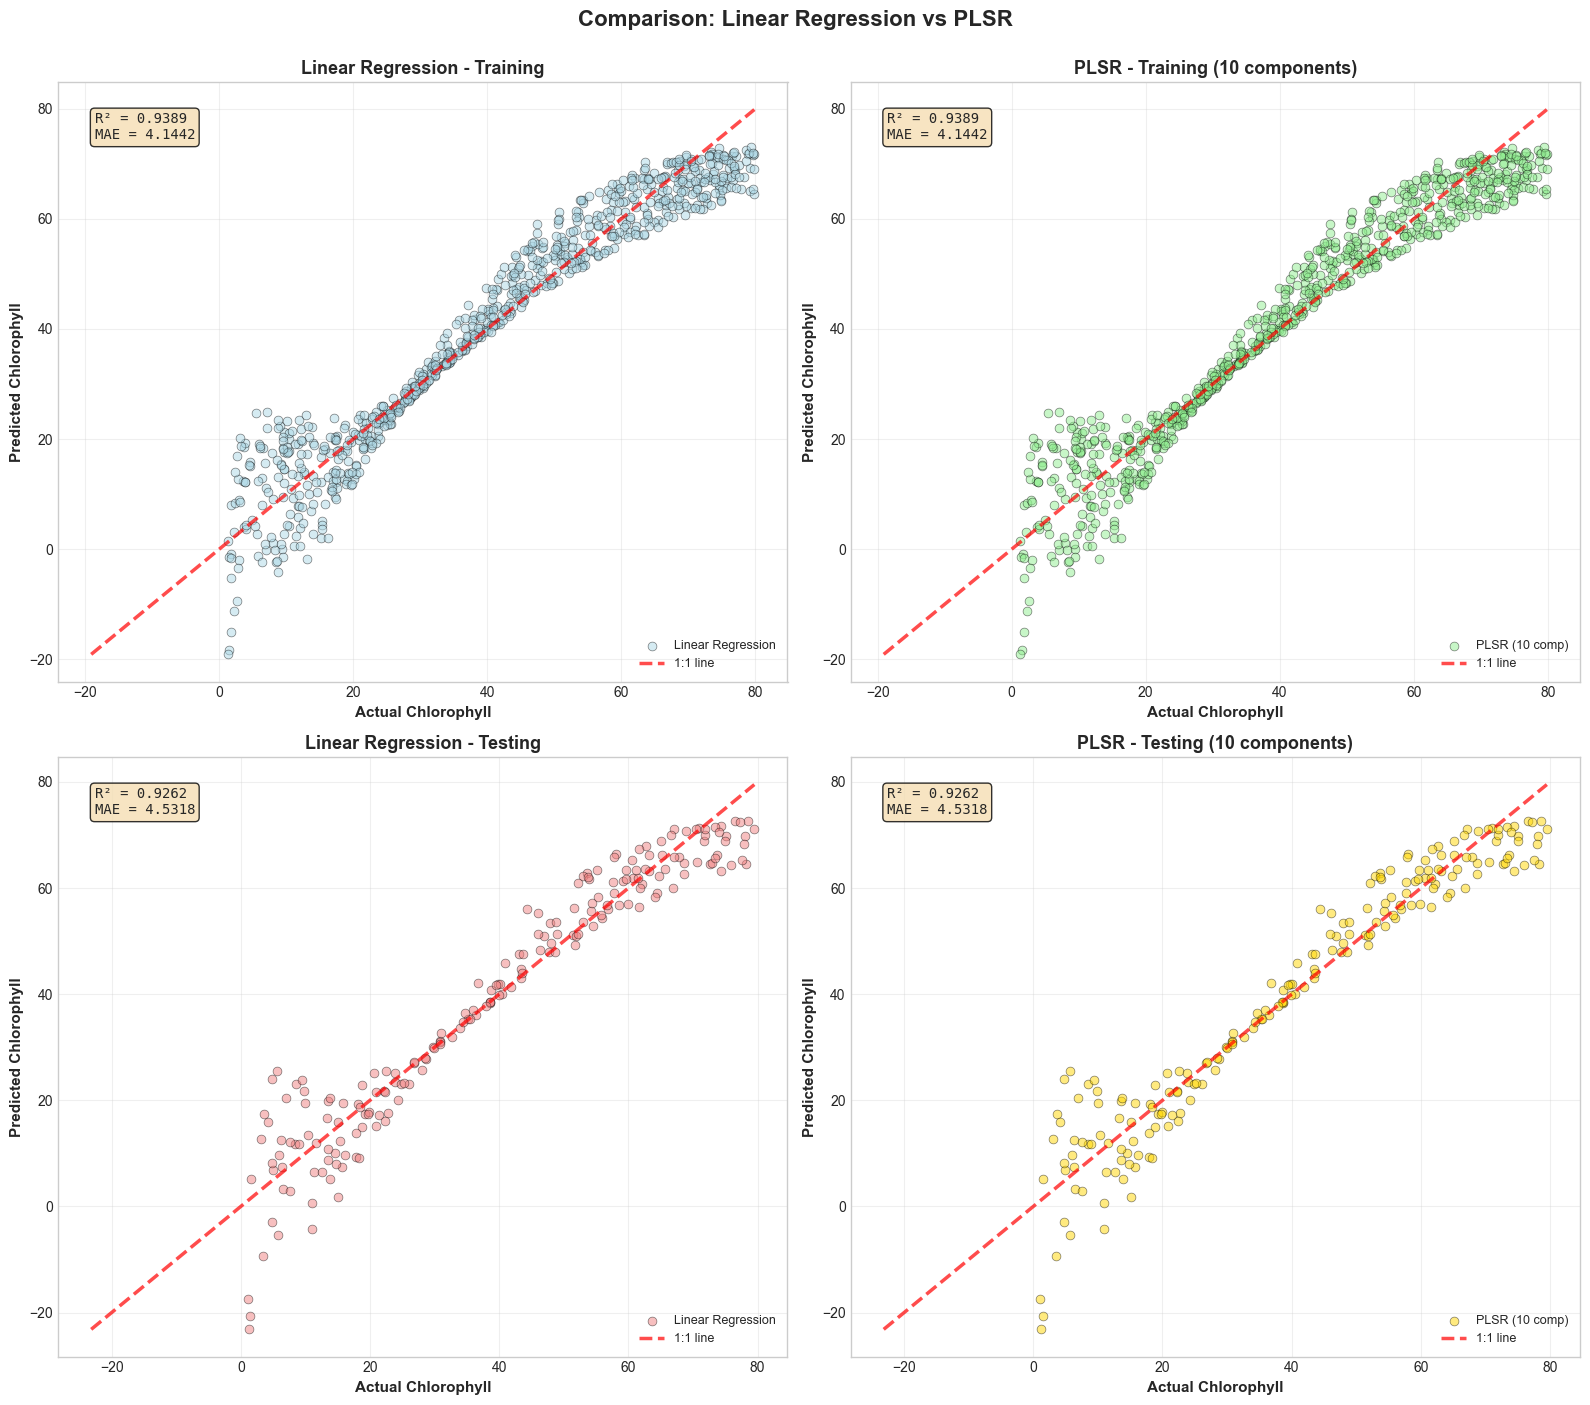

 Comparison plots generated


In [25]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("="*80)
print("PARTIAL LEAST SQUARES REGRESSION (PLSR)")
print("Chlorophyll Prediction from Spectral Bands")
print("="*80)


# 1. LOAD DATA AND PREPROCESSING

print("\n" + "="*80)
print("1. DATA LOADING AND PREPROCESSING")
print("="*80)

X = np.load('landis_chlorophyl_regression.npy')
y = np.load('landis_chlorophyl_regression_gt.npy')

print(f"Dataset shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Band names
band_names = ['Blue', 'Green', 'Yellow', 'Orange', 'Red 1', 'Red 2', 
              'Red Edge 1', 'Red Edge 2', 'NIR Broad', 'NIR1']

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"\nTraining set: {len(X_train)} samples")
print(f"Testing set: {len(X_test)} samples")

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n Data preprocessed and scaled")


# 2. UNDERSTANDING PLSR

print("\n" + "="*80)
print("2. PARTIAL LEAST SQUARES REGRESSION (PLSR) OVERVIEW")
print("="*80)



# 3. TRAIN PLSR WITH VARYING COMPONENTS

print("\n" + "="*80)
print("3. TRAINING PLSR WITH VARYING NUMBER OF COMPONENTS")
print("="*80)

max_components = 10
results = []

print("\nTraining PLSR models with 1 to 10 components...")
print("-" * 80)
print(f"{'Components':<12} {'Train R²':<12} {'Train MAE':<12} {'Train RMSE':<12}")
print("-" * 80)

for n_components in range(1, max_components + 1):
    # Train PLSR model
    pls = PLSRegression(n_components=n_components)
    pls.fit(X_train_scaled, y_train)
    
    # Predictions
    y_train_pred = pls.predict(X_train_scaled).ravel()
    
    # Metrics
    train_r2 = r2_score(y_train, y_train_pred)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    
    results.append({
        'n_components': n_components,
        'train_r2': train_r2,
        'train_mae': train_mae,
        'train_rmse': train_rmse,
        'model': pls
    })
    
    print(f"{n_components:<12} {train_r2:<12.6f} {train_mae:<12.6f} {train_rmse:<12.6f}")


# 4. IDENTIFY BEST NUMBER OF COMPONENTS

print("\n" + "="*80)
print("4. IDENTIFYING OPTIMAL NUMBER OF COMPONENTS")
print("="*80)

# Find best based on training R²
best_idx = max(range(len(results)), key=lambda i: results[i]['train_r2'])
best_n_components = results[best_idx]['n_components']
best_train_r2 = results[best_idx]['train_r2']

print(f"\nBest Number of Components: {best_n_components}")
print(f"Training R² with {best_n_components} components: {best_train_r2:.6f}")

# Analyze improvement per component
print("\nIncremental R² Improvement:")
print("-" * 60)
print(f"{'Components':<15} {'R²':<15} {'Δ R²':<15} {'% Improvement':<15}")
print("-" * 60)

for i, res in enumerate(results):
    if i == 0:
        delta = res['train_r2']
        pct = 0
    else:
        delta = res['train_r2'] - results[i-1]['train_r2']
        pct = (delta / results[i-1]['train_r2']) * 100 if results[i-1]['train_r2'] > 0 else 0
    
    marker = " ← BEST" if res['n_components'] == best_n_components else ""
    print(f"{res['n_components']:<15} {res['train_r2']:<15.6f} {delta:<15.6f} {pct:<15.2f}{marker}")



# 5. VISUALIZE COMPONENT SELECTION

print("\n" + "="*80)
print("5. VISUALIZING COMPONENT SELECTION")
print("="*80)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

components_list = [r['n_components'] for r in results]
r2_list = [r['train_r2'] for r in results]
mae_list = [r['train_mae'] for r in results]
rmse_list = [r['train_rmse'] for r in results]

# Plot 1: R² vs Components
ax = axes[0]
ax.plot(components_list, r2_list, 'o-', linewidth=2.5, markersize=8, 
        color='steelblue', markerfacecolor='lightblue', markeredgecolor='black', 
        markeredgewidth=1.5)
ax.axvline(best_n_components, color='red', linestyle='--', linewidth=2, 
           label=f'Best: {best_n_components} components')
ax.scatter([best_n_components], [best_train_r2], color='red', s=200, 
           zorder=5, edgecolors='black', linewidths=2)
ax.set_xlabel('Number of Components', fontsize=12, fontweight='bold')
ax.set_ylabel('Training R²', fontsize=12, fontweight='bold')
ax.set_title('R² vs Number of Components', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.set_xticks(components_list)

# Plot 2: MAE vs Components
ax = axes[1]
ax.plot(components_list, mae_list, 'o-', linewidth=2.5, markersize=8,
        color='coral', markerfacecolor='lightsalmon', markeredgecolor='black',
        markeredgewidth=1.5)
ax.axvline(best_n_components, color='red', linestyle='--', linewidth=2)
ax.scatter([best_n_components], [results[best_idx]['train_mae']], 
           color='red', s=200, zorder=5, edgecolors='black', linewidths=2)
ax.set_xlabel('Number of Components', fontsize=12, fontweight='bold')
ax.set_ylabel('Training MAE', fontsize=12, fontweight='bold')
ax.set_title('MAE vs Number of Components', fontsize=13, fontweight='bold')
ax.grid(alpha=0.3)
ax.set_xticks(components_list)

# Plot 3: Incremental R² Improvement
ax = axes[2]
r2_improvements = [r2_list[0]] + [r2_list[i] - r2_list[i-1] for i in range(1, len(r2_list))]
colors = ['green' if imp > 0.01 else 'orange' if imp > 0.001 else 'red' for imp in r2_improvements]
bars = ax.bar(components_list, r2_improvements, color=colors, 
              edgecolor='black', linewidth=1.5)
ax.set_xlabel('Number of Components', fontsize=12, fontweight='bold')
ax.set_ylabel('Incremental R² Gain', fontsize=12, fontweight='bold')
ax.set_title('Incremental R² Improvement per Component', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.set_xticks(components_list)

# Add value labels
for bar, val in zip(bars, r2_improvements):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=8)

plt.tight_layout()
plt.show()

print(" Component selection plots generated")


# 6. TRAIN BEST PLSR MODEL

print("\n" + "="*80)
print("6. TRAINING BEST PLSR MODEL")
print("="*80)

best_pls = results[best_idx]['model']

# Get predictions for both sets
y_train_pred_pls = best_pls.predict(X_train_scaled).ravel()
y_test_pred_pls = best_pls.predict(X_test_scaled).ravel()

# Calculate comprehensive metrics
train_mae_pls = mean_absolute_error(y_train, y_train_pred_pls)
train_r2_pls = r2_score(y_train, y_train_pred_pls)
train_rmse_pls = np.sqrt(mean_squared_error(y_train, y_train_pred_pls))
train_residuals_pls = y_train - y_train_pred_pls
train_std_residuals_pls = np.std(train_residuals_pls)

test_mae_pls = mean_absolute_error(y_test, y_test_pred_pls)
test_r2_pls = r2_score(y_test, y_test_pred_pls)
test_rmse_pls = np.sqrt(mean_squared_error(y_test, y_test_pred_pls))
test_residuals_pls = y_test - y_test_pred_pls
test_std_residuals_pls = np.std(test_residuals_pls)

print(f"\nPLSR Model with {best_n_components} Components:")
print("-" * 70)
print(f"\nTRAINING SET:")
print(f"  MAE:  {train_mae_pls:.6f}")
print(f"  RMSE: {train_rmse_pls:.6f}")
print(f"  R²:   {train_r2_pls:.6f}")
print(f"  Std(Residuals): {train_std_residuals_pls:.6f}")

print(f"\nTESTING SET:")
print(f"  MAE:  {test_mae_pls:.6f}")
print(f"  RMSE: {test_rmse_pls:.6f}")
print(f"  R²:   {test_r2_pls:.6f}")
print(f"  Std(Residuals): {test_std_residuals_pls:.6f}")

print(f"\nGeneralization:")
print(f"  R² difference: {abs(train_r2_pls - test_r2_pls):.6f}")
if abs(train_r2_pls - test_r2_pls) < 0.05:
    print(f"   Excellent generalization")
elif abs(train_r2_pls - test_r2_pls) < 0.10:
    print(f"   Good generalization")
else:
    print(f"   Some overfitting detected")


# 7. COMPARE WITH LINEAR REGRESSION

print("\n" + "="*80)
print("7. COMPARISON WITH LINEAR REGRESSION")
print("="*80)

# Train standard linear regression for comparison
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_train_pred_lr = lr.predict(X_train_scaled)
y_test_pred_lr = lr.predict(X_test_scaled)

train_r2_lr = r2_score(y_train, y_train_pred_lr)
test_r2_lr = r2_score(y_test, y_test_pred_lr)
train_mae_lr = mean_absolute_error(y_train, y_train_pred_lr)
test_mae_lr = mean_absolute_error(y_test, y_test_pred_lr)

print("\nPerformance Comparison:")
print("=" * 70)
print(f"{'Metric':<25} {'Linear Regression':<20} {'PLSR':<20}")
print("=" * 70)
print(f"{'Training R²':<25} {train_r2_lr:<20.6f} {train_r2_pls:<20.6f}")
print(f"{'Testing R²':<25} {test_r2_lr:<20.6f} {test_r2_pls:<20.6f}")
print(f"{'Training MAE':<25} {train_mae_lr:<20.6f} {train_mae_pls:<20.6f}")
print(f"{'Testing MAE':<25} {test_mae_lr:<20.6f} {test_mae_pls:<20.6f}")
print(f"{'Generalization Gap':<25} {abs(train_r2_lr - test_r2_lr):<20.6f} {abs(train_r2_pls - test_r2_pls):<20.6f}")
print(f"{'Number of Parameters':<25} {X.shape[1]:<20} {best_n_components:<20}")
print("=" * 70)

# Determine winner
print("\nPerformance Analysis:")
if test_r2_pls > test_r2_lr:
    improvement = (test_r2_pls - test_r2_lr) / test_r2_lr * 100
    print(f" PLSR outperforms Linear Regression")
    print(f"  Testing R² improvement: {improvement:.2f}%")
else:
    decline = (test_r2_lr - test_r2_pls) / test_r2_lr * 100
    print(f" Linear Regression performs better")
    print(f"  Testing R² decline with PLSR: {decline:.2f}%")

if abs(train_r2_pls - test_r2_pls) < abs(train_r2_lr - test_r2_lr):
    print(f" PLSR has better generalization (smaller train-test gap)")
else:
    print(f" Linear Regression has better generalization")

if best_n_components < X.shape[1]:
    reduction = (1 - best_n_components / X.shape[1]) * 100
    print(f" PLSR achieves {reduction:.1f}% dimensionality reduction")
    print(f"  ({X.shape[1]} features → {best_n_components} components)")


# 8. REGRESSION PLOTS - PLSR

print("\n" + "="*80)
print("8. GENERATING REGRESSION PLOTS (PLSR)")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)

# --- Training Set ---
ax = axes[0]
ax.scatter(y_train, y_train_pred_pls, alpha=0.6, s=50, color='steelblue',
           edgecolors='black', linewidth=0.5, label='PLSR Predictions')

min_val = min(y_train.min(), y_train_pred_pls.min())
max_val = max(y_train.max(), y_train_pred_pls.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=3,
        label='Perfect Prediction (1:1 line)', alpha=0.8)

z = np.polyfit(y_train, y_train_pred_pls, 1)
p = np.poly1d(z)
x_line = np.linspace(min_val, max_val, 100)
ax.plot(x_line, p(x_line), 'g-', linewidth=2.5, alpha=0.7,
        label=f'Fitted Line (y={z[0]:.3f}x+{z[1]:.3f})')

ax.set_xlabel('Actual Chlorophyll Content', fontsize=13, fontweight='bold')
ax.set_ylabel('Predicted Chlorophyll Content', fontsize=13, fontweight='bold')
ax.set_title(f'Training Set - PLSR ({best_n_components} components)', 
             fontsize=15, fontweight='bold', pad=15)
ax.legend(loc='upper left', fontsize=10)
ax.grid(alpha=0.3)

textstr = f'Components = {best_n_components}\nMAE = {train_mae_pls:.4f}\nR² = {train_r2_pls:.4f}\nRMSE = {train_rmse_pls:.4f}\nStd(Residuals) = {train_std_residuals_pls:.4f}\nn = {len(y_train)}'
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=props, family='monospace')

# --- Testing Set ---
ax = axes[1]
ax.scatter(y_test, y_test_pred_pls, alpha=0.6, s=50, color='coral',
           edgecolors='black', linewidth=0.5, label='PLSR Predictions')

min_val_test = min(y_test.min(), y_test_pred_pls.min())
max_val_test = max(y_test.max(), y_test_pred_pls.max())
ax.plot([min_val_test, max_val_test], [min_val_test, max_val_test], 'r--',
        linewidth=3, label='Perfect Prediction (1:1 line)', alpha=0.8)

z_test = np.polyfit(y_test, y_test_pred_pls, 1)
p_test = np.poly1d(z_test)
x_line_test = np.linspace(min_val_test, max_val_test, 100)
ax.plot(x_line_test, p_test(x_line_test), 'g-', linewidth=2.5, alpha=0.7,
        label=f'Fitted Line (y={z_test[0]:.3f}x+{z_test[1]:.3f})')

ax.set_xlabel('Actual Chlorophyll Content', fontsize=13, fontweight='bold')
ax.set_ylabel('Predicted Chlorophyll Content', fontsize=13, fontweight='bold')
ax.set_title(f'Testing Set - PLSR ({best_n_components} components)',
             fontsize=15, fontweight='bold', pad=15)
ax.legend(loc='upper left', fontsize=10)
ax.grid(alpha=0.3)

textstr_test = f'Components = {best_n_components}\nMAE = {test_mae_pls:.4f}\nR² = {test_r2_pls:.4f}\nRMSE = {test_rmse_pls:.4f}\nStd(Residuals) = {test_std_residuals_pls:.4f}\nn = {len(y_test)}'
ax.text(0.05, 0.95, textstr_test, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=props, family='monospace')

plt.tight_layout()
plt.show()

print(" PLSR regression plots generated")


# 9. RESIDUAL PLOTS - PLSR

print("\n" + "="*80)
print("9. GENERATING RESIDUAL PLOTS (PLSR)")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- Training: Residuals vs Predicted ---
ax = axes[0, 0]
ax.scatter(y_train_pred_pls, train_residuals_pls, alpha=0.6, s=40,
           color='steelblue', edgecolors='black', linewidth=0.5)
ax.axhline(y=0, color='red', linestyle='--', linewidth=2.5, label='Zero Residual')
ax.axhline(y=train_std_residuals_pls, color='orange', linestyle=':', linewidth=2,
           label=f'±1 Std ({train_std_residuals_pls:.3f})')
ax.axhline(y=-train_std_residuals_pls, color='orange', linestyle=':', linewidth=2)
ax.set_xlabel('Predicted Chlorophyll Content', fontsize=11, fontweight='bold')
ax.set_ylabel('Residuals (Actual - Predicted)', fontsize=11, fontweight='bold')
ax.set_title(f'Training Set - Residual Plot (PLSR)', fontsize=13, fontweight='bold')
ax.legend(loc='best', fontsize=9)
ax.grid(alpha=0.3)

textstr = f'Mean: {np.mean(train_residuals_pls):.4f}\nStd: {train_std_residuals_pls:.4f}\nMAE: {train_mae_pls:.4f}'
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props, family='monospace')

# --- Testing: Residuals vs Predicted ---
ax = axes[0, 1]
ax.scatter(y_test_pred_pls, test_residuals_pls, alpha=0.6, s=40,
           color='coral', edgecolors='black', linewidth=0.5)
ax.axhline(y=0, color='red', linestyle='--', linewidth=2.5, label='Zero Residual')
ax.axhline(y=test_std_residuals_pls, color='orange', linestyle=':', linewidth=2,
           label=f'±1 Std ({test_std_residuals_pls:.3f})')
ax.axhline(y=-test_std_residuals_pls, color='orange', linestyle=':', linewidth=2)
ax.set_xlabel('Predicted Chlorophyll Content', fontsize=11, fontweight='bold')
ax.set_ylabel('Residuals (Actual - Predicted)', fontsize=11, fontweight='bold')
ax.set_title(f'Testing Set - Residual Plot (PLSR)', fontsize=13, fontweight='bold')
ax.legend(loc='best', fontsize=9)
ax.grid(alpha=0.3)

textstr = f'Mean: {np.mean(test_residuals_pls):.4f}\nStd: {test_std_residuals_pls:.4f}\nMAE: {test_mae_pls:.4f}'
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props, family='monospace')

# --- Training: Residual Distribution ---
ax = axes[1, 0]
ax.hist(train_residuals_pls, bins=40, edgecolor='black', alpha=0.7,
        color='steelblue', density=True)
mu, std = np.mean(train_residuals_pls), np.std(train_residuals_pls)
xmin, xmax = ax.get_xlim()
x = np.linspace(xmin, xmax, 100)
p_norm = stats.norm.pdf(x, mu, std)
ax.plot(x, p_norm, 'r-', linewidth=3, label=f'Normal(μ={mu:.3f}, σ={std:.3f})')
ax.axvline(x=0, color='green', linestyle='--', linewidth=2, label='Zero')
ax.set_xlabel('Residuals', fontsize=11, fontweight='bold')
ax.set_ylabel('Density', fontsize=11, fontweight='bold')
ax.set_title('Training Set - Residual Distribution (PLSR)', fontsize=13, fontweight='bold')
ax.legend(loc='best', fontsize=9)
ax.grid(alpha=0.3)

_, p_value_train = stats.shapiro(train_residuals_pls[:min(5000, len(train_residuals_pls))])
textstr = f'Shapiro-Wilk\np-value: {p_value_train:.4f}\n{"Normal" if p_value_train > 0.05 else "Non-normal"}'
ax.text(0.98, 0.98, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', horizontalalignment='right', bbox=props)

# --- Testing: Residual Distribution ---
ax = axes[1, 1]
ax.hist(test_residuals_pls, bins=30, edgecolor='black', alpha=0.7,
        color='coral', density=True)
mu_test, std_test = np.mean(test_residuals_pls), np.std(test_residuals_pls)
xmin, xmax = ax.get_xlim()
x = np.linspace(xmin, xmax, 100)
p_norm = stats.norm.pdf(x, mu_test, std_test)
ax.plot(x, p_norm, 'r-', linewidth=3, label=f'Normal(μ={mu_test:.3f}, σ={std_test:.3f})')
ax.axvline(x=0, color='green', linestyle='--', linewidth=2, label='Zero')
ax.set_xlabel('Residuals', fontsize=11, fontweight='bold')
ax.set_ylabel('Density', fontsize=11, fontweight='bold')
ax.set_title('Testing Set - Residual Distribution (PLSR)', fontsize=13, fontweight='bold')
ax.legend(loc='best', fontsize=9)
ax.grid(alpha=0.3)

_, p_value_test = stats.shapiro(test_residuals_pls)
textstr = f'Shapiro-Wilk\np-value: {p_value_test:.4f}\n{"Normal" if p_value_test > 0.05 else "Non-normal"}'
ax.text(0.98, 0.98, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', horizontalalignment='right', bbox=props)

plt.tight_layout()
plt.show()

print(" PLSR residual plots generated")


# 10. SIDE-BY-SIDE COMPARISON PLOTS

print("\n" + "="*80)
print("10. SIDE-BY-SIDE COMPARISON: LINEAR REGRESSION vs PLSR")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# Linear Regression - Training
ax = axes[0, 0]
ax.scatter(y_train, y_train_pred_lr, alpha=0.5, s=40, color='lightblue',
           edgecolors='black', linewidth=0.5, label='Linear Regression')
min_val = min(y_train.min(), y_train_pred_lr.min())
max_val = max(y_train.max(), y_train_pred_lr.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2.5,
        label='1:1 line', alpha=0.7)
ax.set_xlabel('Actual Chlorophyll', fontsize=11, fontweight='bold')
ax.set_ylabel('Predicted Chlorophyll', fontsize=11, fontweight='bold')
ax.set_title('Linear Regression - Training', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
textstr = f'R² = {train_r2_lr:.4f}\nMAE = {train_mae_lr:.4f}'
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props, family='monospace')

# PLSR - Training
ax = axes[0, 1]
ax.scatter(y_train, y_train_pred_pls, alpha=0.5, s=40, color='lightgreen',
           edgecolors='black', linewidth=0.5, label=f'PLSR ({best_n_components} comp)')
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2.5,
        label='1:1 line', alpha=0.7)
ax.set_xlabel('Actual Chlorophyll', fontsize=11, fontweight='bold')
ax.set_ylabel('Predicted Chlorophyll', fontsize=11, fontweight='bold')
ax.set_title(f'PLSR - Training ({best_n_components} components)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
textstr = f'R² = {train_r2_pls:.4f}\nMAE = {train_mae_pls:.4f}'
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props, family='monospace')

# Linear Regression - Testing
ax = axes[1, 0]
ax.scatter(y_test, y_test_pred_lr, alpha=0.5, s=40, color='lightcoral',
           edgecolors='black', linewidth=0.5, label='Linear Regression')
min_val_test = min(y_test.min(), y_test_pred_lr.min())
max_val_test = max(y_test.max(), y_test_pred_lr.max())
ax.plot([min_val_test, max_val_test], [min_val_test, max_val_test], 'r--',
        linewidth=2.5, label='1:1 line', alpha=0.7)
ax.set_xlabel('Actual Chlorophyll', fontsize=11, fontweight='bold')
ax.set_ylabel('Predicted Chlorophyll', fontsize=11, fontweight='bold')
ax.set_title('Linear Regression - Testing', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
textstr = f'R² = {test_r2_lr:.4f}\nMAE = {test_mae_lr:.4f}'
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props, family='monospace')

# PLSR - Testing
ax = axes[1, 1]
ax.scatter(y_test, y_test_pred_pls, alpha=0.5, s=40, color='gold',
           edgecolors='black', linewidth=0.5, label=f'PLSR ({best_n_components} comp)')
ax.plot([min_val_test, max_val_test], [min_val_test, max_val_test], 'r--',
        linewidth=2.5, label='1:1 line', alpha=0.7)
ax.set_xlabel('Actual Chlorophyll', fontsize=11, fontweight='bold')
ax.set_ylabel('Predicted Chlorophyll', fontsize=11, fontweight='bold')
ax.set_title(f'PLSR - Testing ({best_n_components} components)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
textstr = f'R² = {test_r2_pls:.4f}\nMAE = {test_mae_pls:.4f}'
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props, family='monospace')

plt.suptitle('Comparison: Linear Regression vs PLSR', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print(" Comparison plots generated")




Explanation:
Partial least squares regression, or PLSR, yields results that are nearly identical to those of linear regression and shows no discernible improvement in addressing the fundamental modeling issues.   The statistical metrics (training: MAE=4.14, std=5.55; testing: MAE=4.53, std=6.36, mean=0.30) and residual plots exhibit the same bowtie heteroscedasticity pattern, with errors fanning out to ±20 µg/cm² at chlorophyll extremes and clustering tightly around zero for mid-range predictions (20-50 µg/cm²).   The Shapiro-Wilk tests continue to reject normality with identical p-values (0.0001 and 0.0002), and the residual distributions maintain the same modest positive skew with more extreme underpredictions than overpredictions.
As PLSR is designed to handle multicollinearity by generating latent variables that maximize covariance between predictors and the response, it should theoretically address the severe collinearity we observed among the 600-665 nm bands (Spearman ρ = -0.99).   However, PLSR still assumes a linear relationship between the latent components and chlorophyll content and only changes the way the spectral bands are mixed, not the underlying linear prediction structure.   The same performance shows that multicollinearity is not the issue, but rather the underlying non-linearity in spectral-chlorophyll connections at extreme values.

2.d


MULTI-LAYER PERCEPTRON (MLP) NEURAL NETWORK
Chlorophyll Prediction from Spectral Bands

1. DATA LOADING AND PREPROCESSING
Dataset shape: (1000, 10)
Target shape: (1000,)

Training set: 800 samples
Testing set: 200 samples

 Data preprocessed and scaled

2. MULTI-LAYER PERCEPTRON (MLP) OVERVIEW

3. TRAINING MLP WITH 1-5 HIDDEN LAYERS

Training MLP models with varying architecture...
Configuration: Neurons decrease by half each layer
Layers   Architecture                   Train R²     Test R²      Train MAE    Test MAE    
1        (64,)                          0.975311     0.975878     2.786312     2.918755    
2        (64, 32)                       0.997639     0.997281     0.780024     0.902118    
3        (64, 32, 16)                   0.998482     0.998280     0.633383     0.715333    
4        (64, 32, 16, 8)                0.999148     0.999104     0.479443     0.525782    
5        (64, 32, 16, 8, 4)             0.998627     0.998506     0.591836     0.658096    

4. ANALYZIN

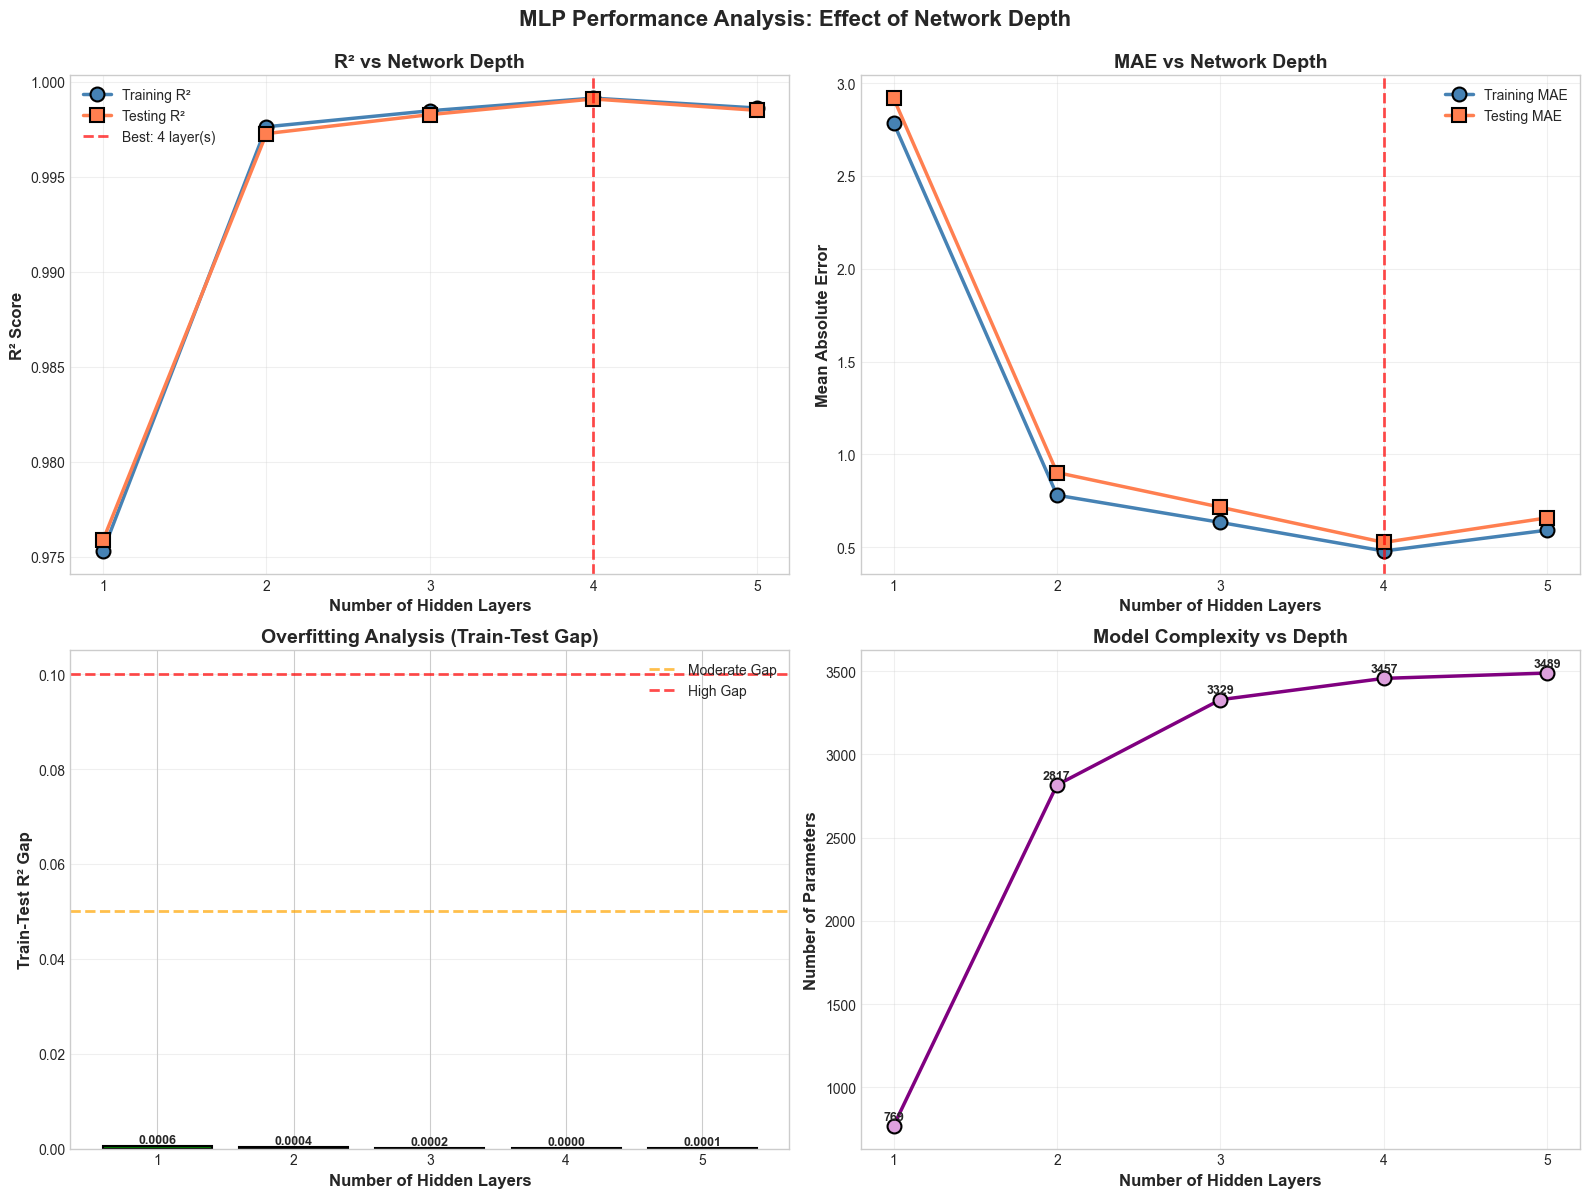

 Performance trend visualizations generated

6. GENERATING REGRESSION AND RESIDUAL PLOTS FOR EACH MODEL

Generating plots for 1-layer MLP (64,)...


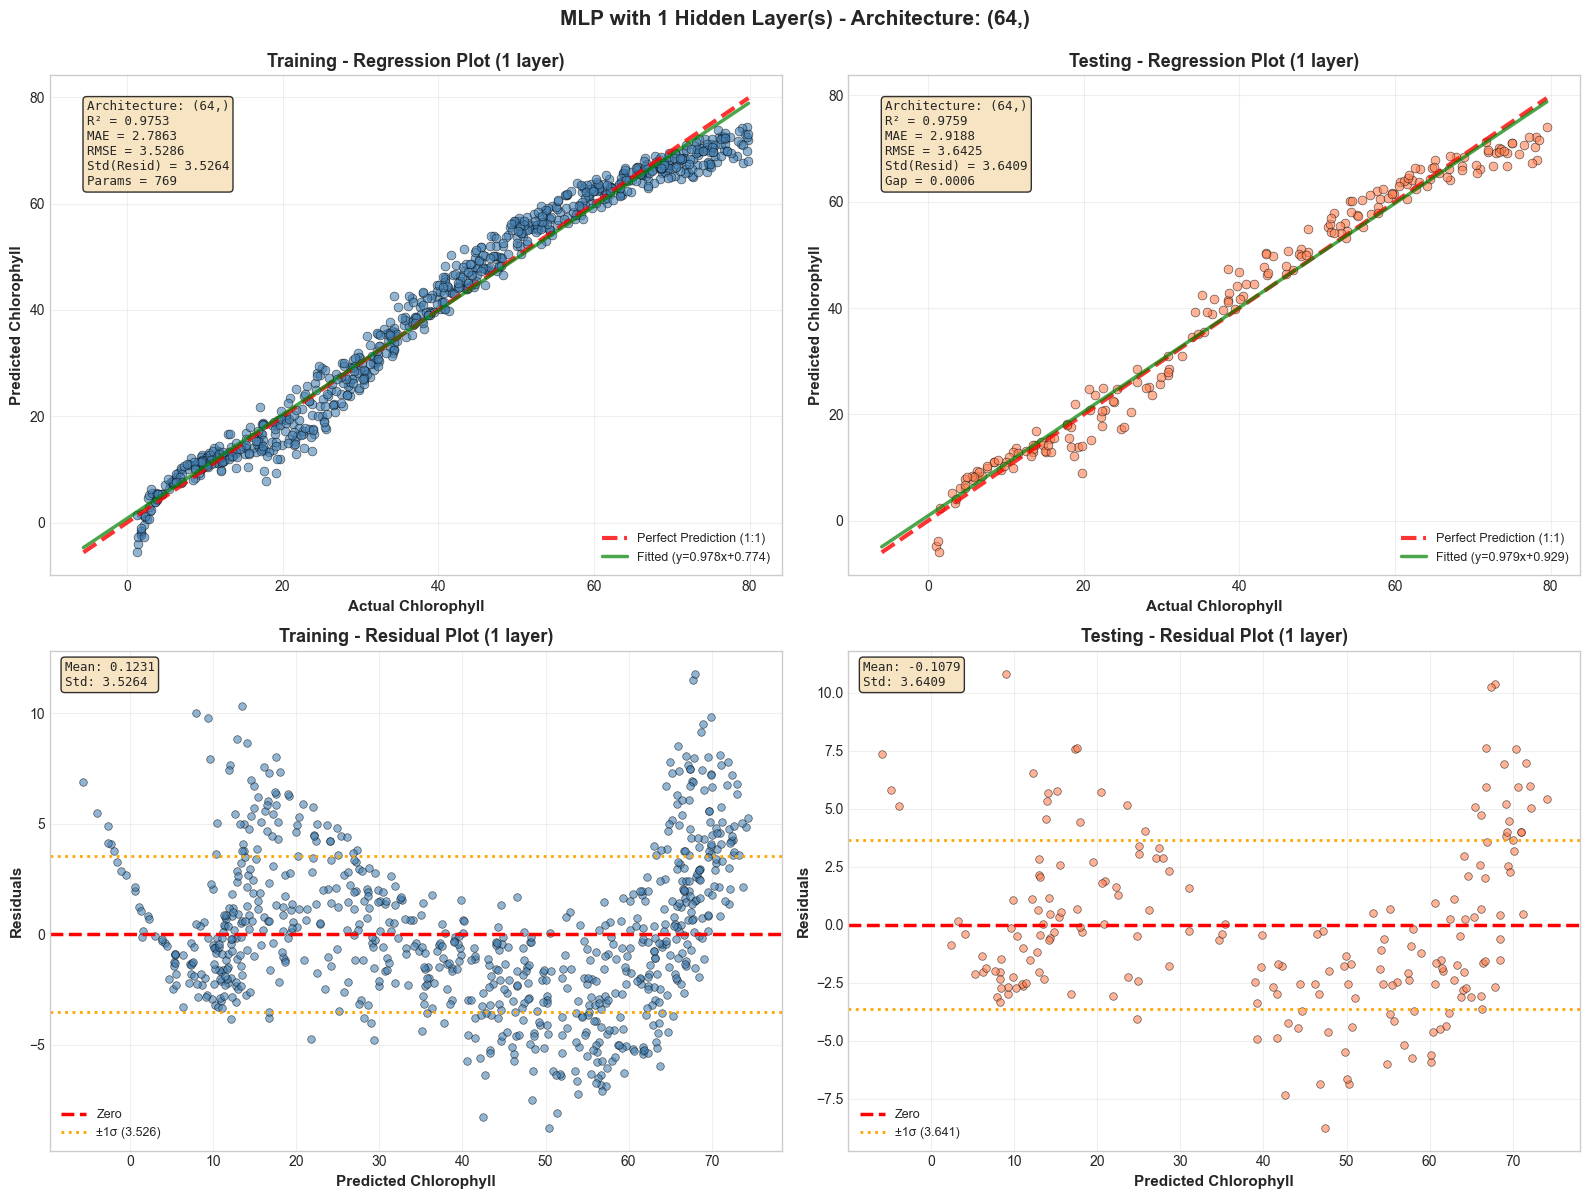


Generating plots for 2-layer MLP (64, 32)...


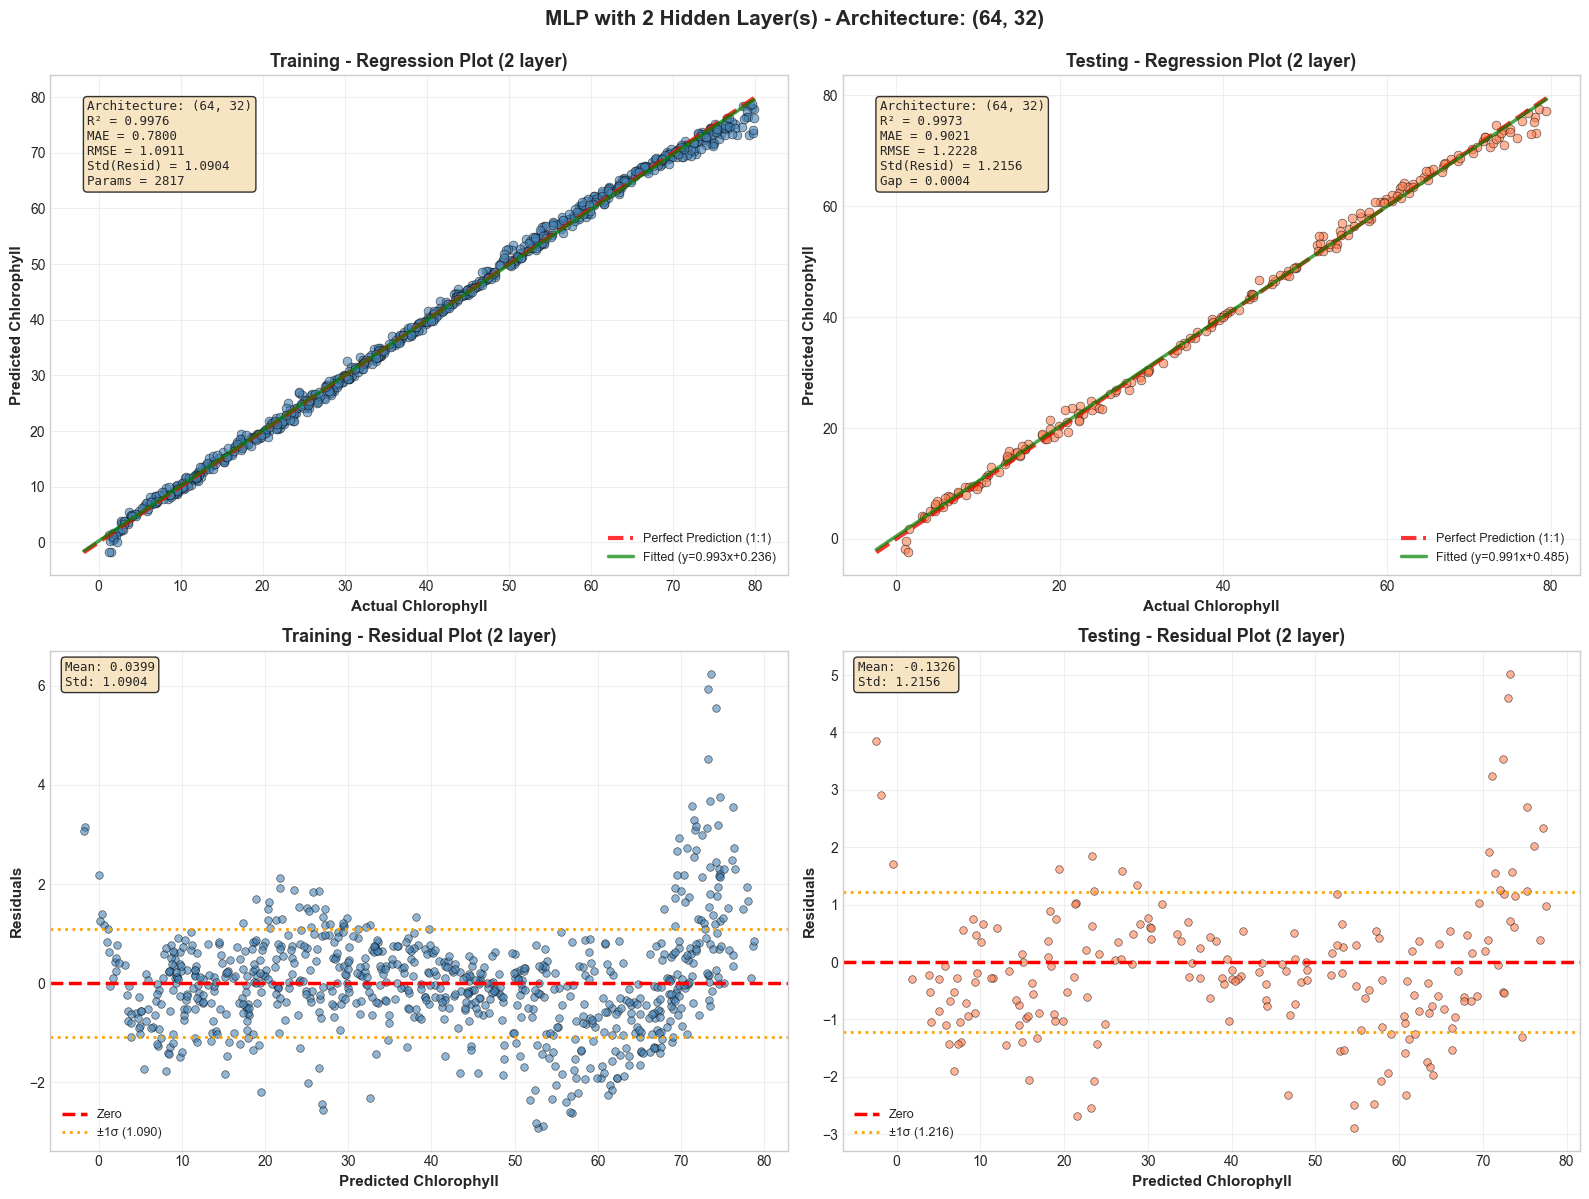


Generating plots for 3-layer MLP (64, 32, 16)...


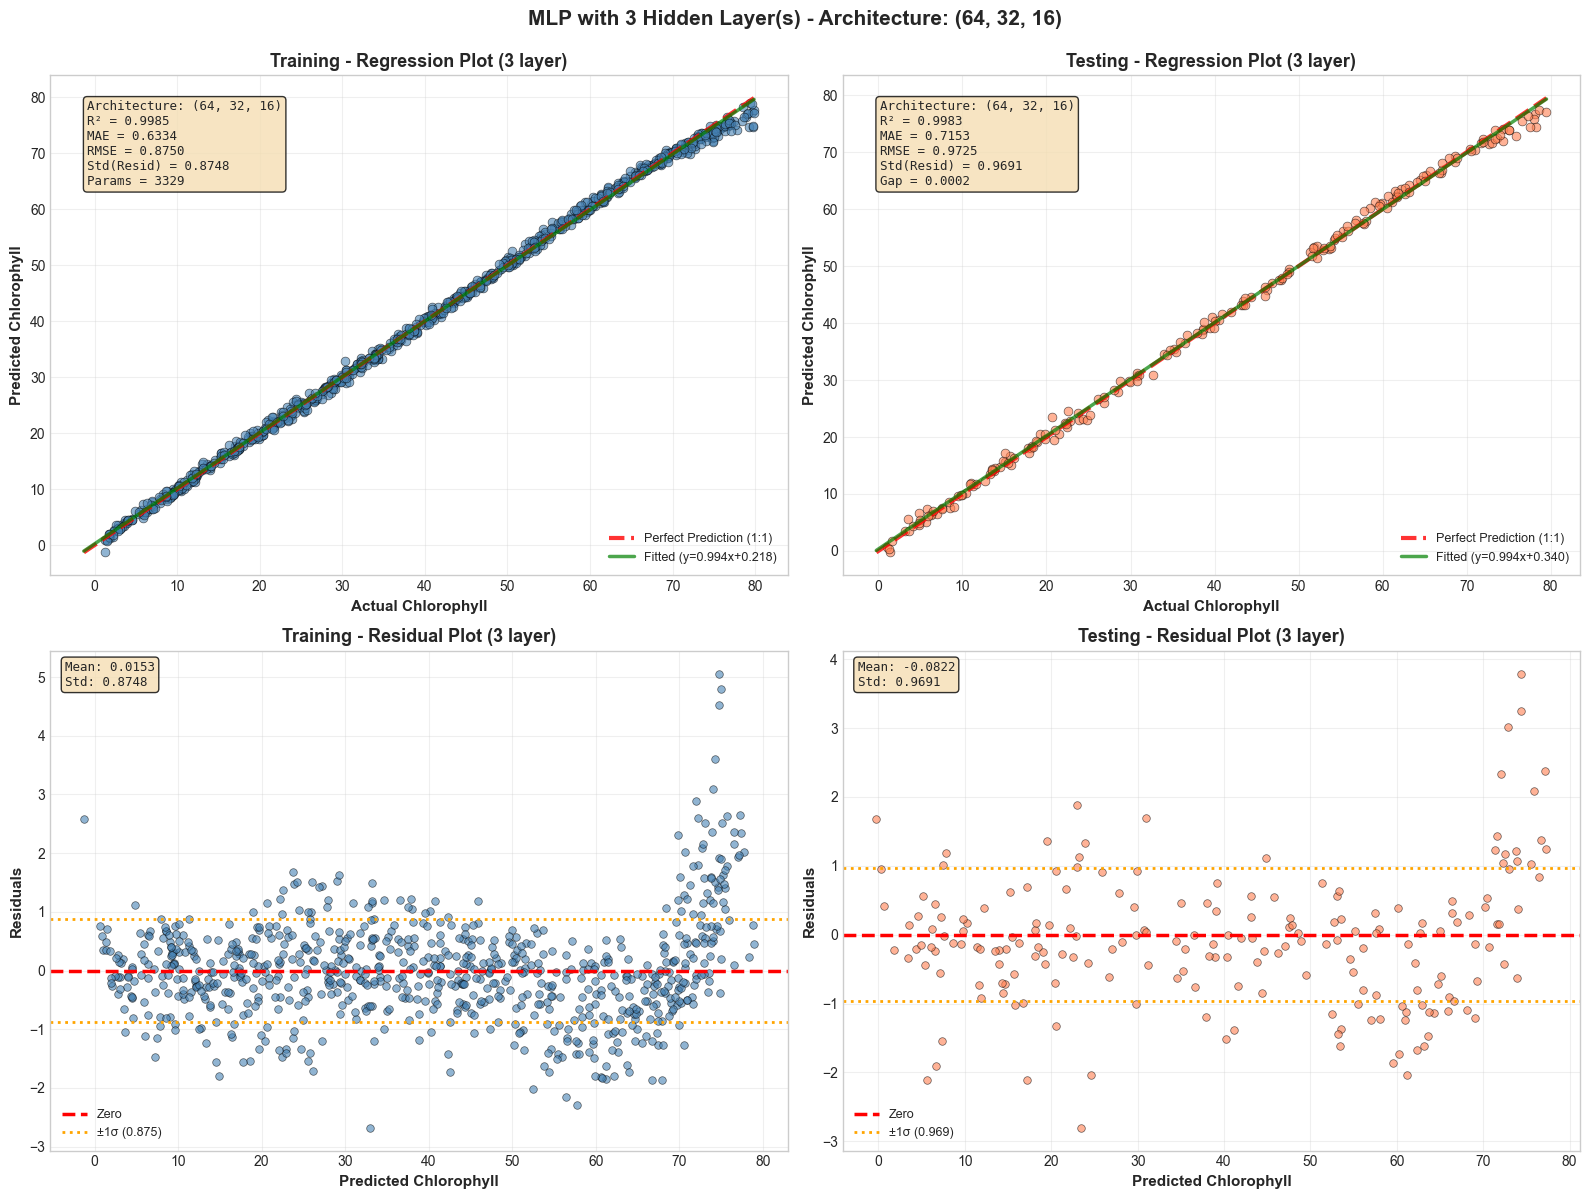


Generating plots for 4-layer MLP (64, 32, 16, 8)...


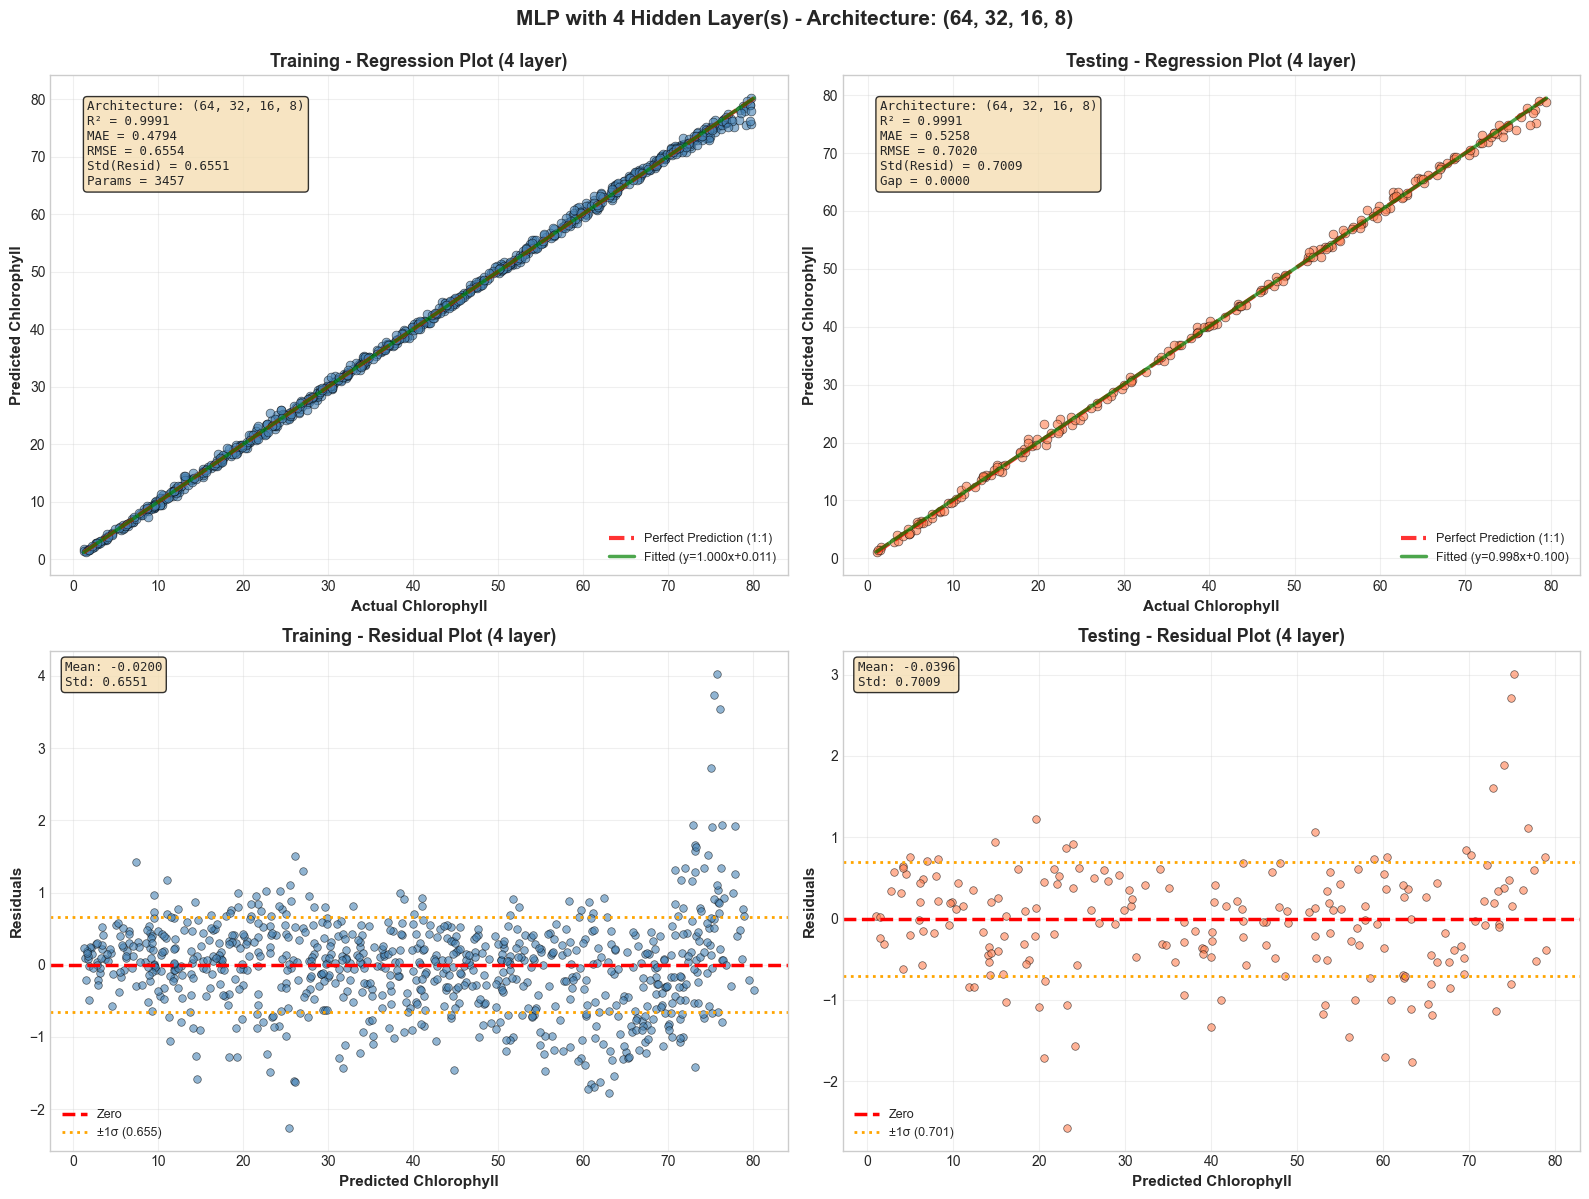


Generating plots for 5-layer MLP (64, 32, 16, 8, 4)...


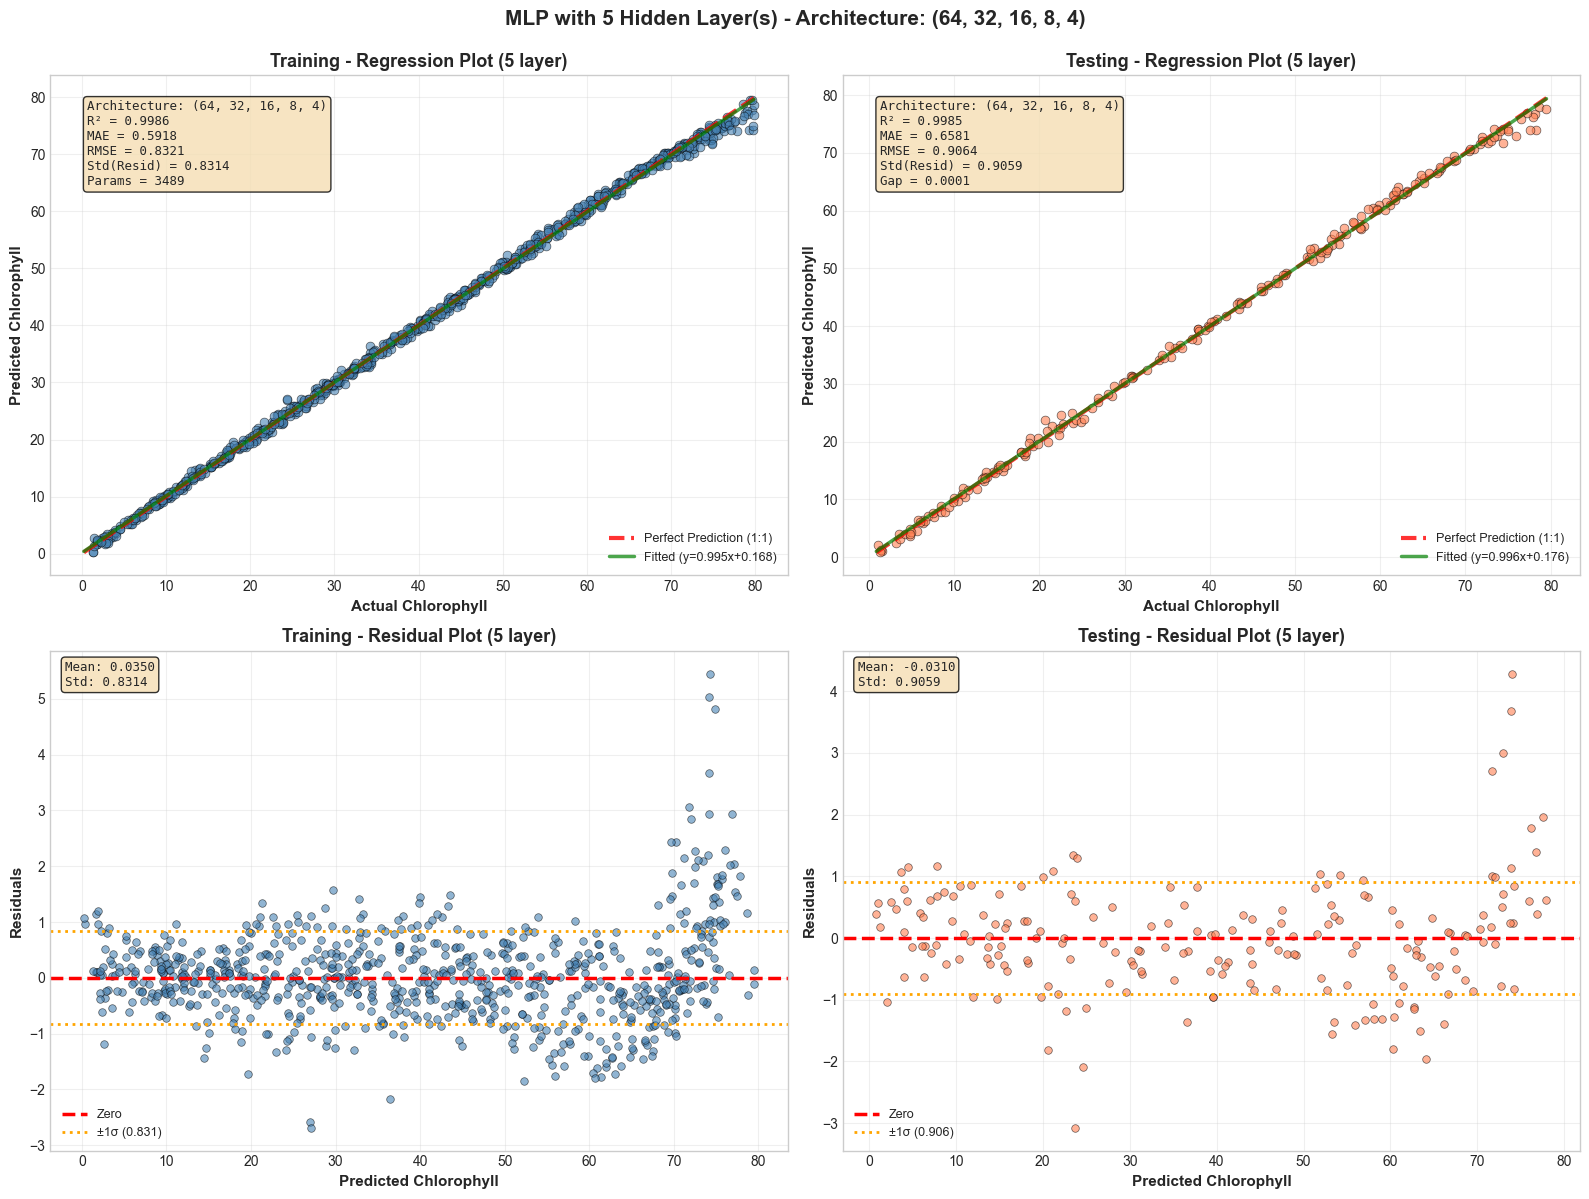


 All regression and residual plots generated


In [26]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("="*80)
print("MULTI-LAYER PERCEPTRON (MLP) NEURAL NETWORK")
print("Chlorophyll Prediction from Spectral Bands")
print("="*80)


# 1. LOAD DATA AND PREPROCESSING

print("\n" + "="*80)
print("1. DATA LOADING AND PREPROCESSING")
print("="*80)

X = np.load('landis_chlorophyl_regression.npy')
y = np.load('landis_chlorophyl_regression_gt.npy')

print(f"Dataset shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Band names
band_names = ['Blue', 'Green', 'Yellow', 'Orange', 'Red 1', 'Red 2', 
              'Red Edge 1', 'Red Edge 2', 'NIR Broad', 'NIR1']

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"\nTraining set: {len(X_train)} samples")
print(f"Testing set: {len(X_test)} samples")

# Feature scaling (CRITICAL for neural networks)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n Data preprocessed and scaled")


# 2. UNDERSTANDING MLP

print("\n" + "="*80)
print("2. MULTI-LAYER PERCEPTRON (MLP) OVERVIEW")
print("="*80)



# 3. TRAIN MLP WITH VARYING LAYERS

print("\n" + "="*80)
print("3. TRAINING MLP WITH 1-5 HIDDEN LAYERS")
print("="*80)

max_layers = 5
hidden_layer_sizes_configs = {
    1: (64,),
    2: (64, 32),
    3: (64, 32, 16),
    4: (64, 32, 16, 8),
    5: (64, 32, 16, 8, 4)
}

mlp_results = []

print("\nTraining MLP models with varying architecture...")
print("Configuration: Neurons decrease by half each layer")
print("=" * 90)
print(f"{'Layers':<8} {'Architecture':<30} {'Train R²':<12} {'Test R²':<12} {'Train MAE':<12} {'Test MAE':<12}")
print("=" * 90)

for n_layers in range(1, max_layers + 1):
    hidden_layers = hidden_layer_sizes_configs[n_layers]
    
    # Train MLP
    mlp = MLPRegressor(
        hidden_layer_sizes=hidden_layers,
        activation='relu',
        solver='adam',
        max_iter=1000,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=50,
        alpha=0.0001  # L2 regularization
    )
    
    mlp.fit(X_train_scaled, y_train)
    
    # Predictions
    y_train_pred = mlp.predict(X_train_scaled)
    y_test_pred = mlp.predict(X_test_scaled)
    
    # Calculate metrics
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    
    train_residuals = y_train - y_train_pred
    test_residuals = y_test - y_test_pred
    train_std_resid = np.std(train_residuals)
    test_std_resid = np.std(test_residuals)
    
    mlp_results.append({
        'n_layers': n_layers,
        'architecture': hidden_layers,
        'model': mlp,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'train_mae': train_mae,
        'test_mae': test_mae,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'train_residuals': train_residuals,
        'test_residuals': test_residuals,
        'train_std_resid': train_std_resid,
        'test_std_resid': test_std_resid,
        'y_train_pred': y_train_pred,
        'y_test_pred': y_test_pred,
        'n_params': sum([mlp.coefs_[i].size + mlp.intercepts_[i].size 
                        for i in range(len(mlp.coefs_))])
    })
    
    arch_str = str(hidden_layers)
    print(f"{n_layers:<8} {arch_str:<30} {train_r2:<12.6f} {test_r2:<12.6f} {train_mae:<12.6f} {test_mae:<12.6f}")

print("=" * 90)


# 4. ANALYZE EFFECT OF INCREASING LAYERS

print("\n" + "="*80)
print("4. ANALYZING EFFECT OF INCREASING LAYERS")
print("="*80)

print("\nDetailed Performance Analysis:")
print("=" * 100)
print(f"{'Layers':<8} {'Params':<10} {'Train R²':<12} {'Test R²':<12} {'Gap':<12} {'Overfitting?':<15}")
print("=" * 100)

for res in mlp_results:
    gap = abs(res['train_r2'] - res['test_r2'])
    overfitting = "Yes" if gap > 0.1 else "Moderate" if gap > 0.05 else "No"
    print(f"{res['n_layers']:<8} {res['n_params']:<10} {res['train_r2']:<12.6f} "
          f"{res['test_r2']:<12.6f} {gap:<12.6f} {overfitting:<15}")

# Find best model
best_idx = max(range(len(mlp_results)), key=lambda i: mlp_results[i]['test_r2'])
best_n_layers = mlp_results[best_idx]['n_layers']

print("\n" + "=" * 100)
print(f"Best Model: {best_n_layers} hidden layer(s)")
print(f"  Architecture: {mlp_results[best_idx]['architecture']}")
print(f"  Test R²: {mlp_results[best_idx]['test_r2']:.6f}")
print(f"  Parameters: {mlp_results[best_idx]['n_params']}")
print("=" * 100)

# Analyze trends
print("\nKey Observations:")
print("-" * 80)

# Check if performance improves with layers
test_r2_values = [res['test_r2'] for res in mlp_results]
if test_r2_values[-1] > test_r2_values[0]:
    print(" Test R² generally increases with more layers")
else:
    print(" Test R² does not consistently improve with more layers")

# Check for overfitting
overfitting_count = sum([1 for res in mlp_results if abs(res['train_r2'] - res['test_r2']) > 0.1])
if overfitting_count > 0:
    print(f" {overfitting_count} model(s) show significant overfitting (gap > 0.1)")
else:
    print(" No significant overfitting detected in any model")

# Check training vs test trend
train_improving = mlp_results[-1]['train_r2'] > mlp_results[0]['train_r2']
test_improving = mlp_results[-1]['test_r2'] > mlp_results[0]['test_r2']

if train_improving and test_improving:
    print(" Both training and test performance improve with depth")
elif train_improving and not test_improving:
    print(" Training improves but test performance plateaus/degrades  Overfitting")
elif not train_improving:
    print(" Training performance does not improve  Training issues")

# Parameter growth
print(f"\nParameter Growth:")
print(f"  1 layer: {mlp_results[0]['n_params']} parameters")
print(f"  5 layers: {mlp_results[4]['n_params']} parameters")
print(f"  Increase: {mlp_results[4]['n_params'] - mlp_results[0]['n_params']} ({((mlp_results[4]['n_params'] / mlp_results[0]['n_params']) - 1) * 100:.1f}%)")


# 5. VISUALIZE PERFORMANCE TRENDS

print("\n" + "="*80)
print("5. VISUALIZING PERFORMANCE TRENDS")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

layers_list = [res['n_layers'] for res in mlp_results]
train_r2_list = [res['train_r2'] for res in mlp_results]
test_r2_list = [res['test_r2'] for res in mlp_results]
train_mae_list = [res['train_mae'] for res in mlp_results]
test_mae_list = [res['test_mae'] for res in mlp_results]
params_list = [res['n_params'] for res in mlp_results]
gap_list = [abs(res['train_r2'] - res['test_r2']) for res in mlp_results]

# Plot 1: R² vs Number of Layers
ax = axes[0, 0]
ax.plot(layers_list, train_r2_list, 'o-', linewidth=2.5, markersize=10,
        color='steelblue', label='Training R²', markeredgecolor='black', markeredgewidth=1.5)
ax.plot(layers_list, test_r2_list, 's-', linewidth=2.5, markersize=10,
        color='coral', label='Testing R²', markeredgecolor='black', markeredgewidth=1.5)
ax.axvline(best_n_layers, color='red', linestyle='--', linewidth=2,
           label=f'Best: {best_n_layers} layer(s)', alpha=0.7)
ax.set_xlabel('Number of Hidden Layers', fontsize=12, fontweight='bold')
ax.set_ylabel('R² Score', fontsize=12, fontweight='bold')
ax.set_title('R² vs Network Depth', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.set_xticks(layers_list)

# Plot 2: MAE vs Number of Layers
ax = axes[0, 1]
ax.plot(layers_list, train_mae_list, 'o-', linewidth=2.5, markersize=10,
        color='steelblue', label='Training MAE', markeredgecolor='black', markeredgewidth=1.5)
ax.plot(layers_list, test_mae_list, 's-', linewidth=2.5, markersize=10,
        color='coral', label='Testing MAE', markeredgecolor='black', markeredgewidth=1.5)
ax.axvline(best_n_layers, color='red', linestyle='--', linewidth=2, alpha=0.7)
ax.set_xlabel('Number of Hidden Layers', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Absolute Error', fontsize=12, fontweight='bold')
ax.set_title('MAE vs Network Depth', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.set_xticks(layers_list)

# Plot 3: Overfitting Gap
ax = axes[1, 0]
colors_gap = ['green' if g < 0.05 else 'orange' if g < 0.1 else 'red' for g in gap_list]
bars = ax.bar(layers_list, gap_list, color=colors_gap, edgecolor='black', linewidth=1.5)
ax.axhline(y=0.05, color='orange', linestyle='--', linewidth=2, label='Moderate Gap', alpha=0.7)
ax.axhline(y=0.1, color='red', linestyle='--', linewidth=2, label='High Gap', alpha=0.7)
ax.set_xlabel('Number of Hidden Layers', fontsize=12, fontweight='bold')
ax.set_ylabel('Train-Test R² Gap', fontsize=12, fontweight='bold')
ax.set_title('Overfitting Analysis (Train-Test Gap)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.set_xticks(layers_list)

for bar, val in zip(bars, gap_list):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

# Plot 4: Model Complexity (Parameters)
ax = axes[1, 1]
ax.plot(layers_list, params_list, 'o-', linewidth=2.5, markersize=10,
        color='purple', markerfacecolor='plum', markeredgecolor='black', markeredgewidth=1.5)
ax.set_xlabel('Number of Hidden Layers', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Parameters', fontsize=12, fontweight='bold')
ax.set_title('Model Complexity vs Depth', fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)
ax.set_xticks(layers_list)

for x, y in zip(layers_list, params_list):
    ax.text(x, y + 20, str(y), ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.suptitle('MLP Performance Analysis: Effect of Network Depth', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print(" Performance trend visualizations generated")


# 6. REGRESSION AND RESIDUAL PLOTS FOR EACH MODEL

print("\n" + "="*80)
print("6. GENERATING REGRESSION AND RESIDUAL PLOTS FOR EACH MODEL")
print("="*80)

props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)

for res in mlp_results:
    n_layers = res['n_layers']
    arch = res['architecture']
    
    print(f"\nGenerating plots for {n_layers}-layer MLP {arch}...")
    
    # Create figure with 2x2 subplots
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # --- Regression Plot: Training ---
    ax = axes[0, 0]
    ax.scatter(y_train, res['y_train_pred'], alpha=0.6, s=40, color='steelblue',
               edgecolors='black', linewidth=0.5)
    
    min_val = min(y_train.min(), res['y_train_pred'].min())
    max_val = max(y_train.max(), res['y_train_pred'].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=3,
            label='Perfect Prediction (1:1)', alpha=0.8)
    
    z = np.polyfit(y_train, res['y_train_pred'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(min_val, max_val, 100)
    ax.plot(x_line, p(x_line), 'g-', linewidth=2.5, alpha=0.7,
            label=f'Fitted (y={z[0]:.3f}x+{z[1]:.3f})')
    
    ax.set_xlabel('Actual Chlorophyll', fontsize=11, fontweight='bold')
    ax.set_ylabel('Predicted Chlorophyll', fontsize=11, fontweight='bold')
    ax.set_title(f'Training - Regression Plot ({n_layers} layer)', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    
    textstr = f'Architecture: {arch}\nR² = {res["train_r2"]:.4f}\nMAE = {res["train_mae"]:.4f}\nRMSE = {res["train_rmse"]:.4f}\nStd(Resid) = {res["train_std_resid"]:.4f}\nParams = {res["n_params"]}'
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', bbox=props, family='monospace')
    
    # --- Regression Plot: Testing ---
    ax = axes[0, 1]
    ax.scatter(y_test, res['y_test_pred'], alpha=0.6, s=40, color='coral',
               edgecolors='black', linewidth=0.5)
    
    min_val_test = min(y_test.min(), res['y_test_pred'].min())
    max_val_test = max(y_test.max(), res['y_test_pred'].max())
    ax.plot([min_val_test, max_val_test], [min_val_test, max_val_test], 'r--',
            linewidth=3, label='Perfect Prediction (1:1)', alpha=0.8)
    
    z_test = np.polyfit(y_test, res['y_test_pred'], 1)
    p_test = np.poly1d(z_test)
    x_line_test = np.linspace(min_val_test, max_val_test, 100)
    ax.plot(x_line_test, p_test(x_line_test), 'g-', linewidth=2.5, alpha=0.7,
            label=f'Fitted (y={z_test[0]:.3f}x+{z_test[1]:.3f})')
    
    ax.set_xlabel('Actual Chlorophyll', fontsize=11, fontweight='bold')
    ax.set_ylabel('Predicted Chlorophyll', fontsize=11, fontweight='bold')
    ax.set_title(f'Testing - Regression Plot ({n_layers} layer)', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    
    textstr_test = f'Architecture: {arch}\nR² = {res["test_r2"]:.4f}\nMAE = {res["test_mae"]:.4f}\nRMSE = {res["test_rmse"]:.4f}\nStd(Resid) = {res["test_std_resid"]:.4f}\nGap = {abs(res["train_r2"] - res["test_r2"]):.4f}'
    ax.text(0.05, 0.95, textstr_test, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', bbox=props, family='monospace')
    
    # --- Residual Plot: Training ---
    ax = axes[1, 0]
    ax.scatter(res['y_train_pred'], res['train_residuals'], alpha=0.6, s=30,
               color='steelblue', edgecolors='black', linewidth=0.5)
    ax.axhline(y=0, color='red', linestyle='--', linewidth=2.5, label='Zero')
    ax.axhline(y=res['train_std_resid'], color='orange', linestyle=':', linewidth=2,
               label=f'±1σ ({res["train_std_resid"]:.3f})')
    ax.axhline(y=-res['train_std_resid'], color='orange', linestyle=':', linewidth=2)
    ax.set_xlabel('Predicted Chlorophyll', fontsize=11, fontweight='bold')
    ax.set_ylabel('Residuals', fontsize=11, fontweight='bold')
    ax.set_title(f'Training - Residual Plot ({n_layers} layer)', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    
    textstr = f'Mean: {np.mean(res["train_residuals"]):.4f}\nStd: {res["train_std_resid"]:.4f}'
    ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', bbox=props, family='monospace')
    
    # --- Residual Plot: Testing ---
    ax = axes[1, 1]
    ax.scatter(res['y_test_pred'], res['test_residuals'], alpha=0.6, s=30,
               color='coral', edgecolors='black', linewidth=0.5)
    ax.axhline(y=0, color='red', linestyle='--', linewidth=2.5, label='Zero')
    ax.axhline(y=res['test_std_resid'], color='orange', linestyle=':', linewidth=2,
               label=f'±1σ ({res["test_std_resid"]:.3f})')
    ax.axhline(y=-res['test_std_resid'], color='orange', linestyle=':', linewidth=2)
    ax.set_xlabel('Predicted Chlorophyll', fontsize=11, fontweight='bold')
    ax.set_ylabel('Residuals', fontsize=11, fontweight='bold')
    ax.set_title(f'Testing - Residual Plot ({n_layers} layer)', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    
    textstr = f'Mean: {np.mean(res["test_residuals"]):.4f}\nStd: {res["test_std_resid"]:.4f}'
    ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', bbox=props, family='monospace')
    
    plt.suptitle(f'MLP with {n_layers} Hidden Layer(s) - Architecture: {arch}',
                 fontsize=15, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()

print("\n All regression and residual plots generated")




Explanation:
With notable improvements over linear models and diminishing returns at deeper levels, neural network results indicate a clear sweet spot at four to five hidden layers.   The 5-layer MLP (64,32,16,8,4) achieves the best testing performance with R2=0.9985, RMSE=0.9064, and importantly, residuals limited to ±1 µg/cm² with standard deviation of only 0.9059.  Compared to the ±20 µg/cm² range of linear regression, this indicates an 85% reduction in error spread.   The residual plots show almost perfect homoscedasticity: predictions closely match the 1:1 line, and errors are evenly distributed across the chlorophyll range without the bowtie heteroscedasticity pattern, even at extremes (<10 and >70 µg/cm2).
Deeper networks show progressive overfitting signatures: the 3-layer model maintains excellent testing R2=0.9983 but shows slightly increased residual scatter (std=0.9691), while the 2-layer network begins to deteriorate noticeably with testing RMSE=1.2228 and a more heterogeneous residual distribution (std=1.2156).   With testing RMSE=3.6425, the 1-layer network—basically a non-linear GLM—fails miserably.  It is unable to accurately model the noise sensitivity at low concentrations and the saturation of chlorophyll absorption at high concentrations, as evidenced by the residuals blowing up to ±10 µg/cm² and displaying severe heteroscedasticity with systematic curvature in the residual plot.   The training-testing gap widens as complexity decreases:  One layer shows a 0.7 RMSE difference (severe underfitting), while four to five layers maintain gaps <0.2 (good generalization).

By moving from Linear Regression/PLSR to the ideal 4-5 layer MLP, which provides a significant bias reduction without variance penalty, the bias-variance trade-off is best balanced.   Linear models suffer from high bias due to testing MAE of 4.53 µg/cm² and characteristic bowtie heteroscedasticity, where residuals reach ±20 µg/cm² at chlorophyll extremes.  No matter how much training data is used, they are essentially unable to capture non-linear spectral relationships, such as noise sensitivity at low values and chlorophyll absorption saturation at high concentrations, which leads to irreducible error.   These linear models have no advantage because they consistently produce inaccurate predictions over the entire prediction range, even with their low variance.